# SETTINGS


In [2]:
import sys
from pathlib import Path



%load_ext autoreload
%autoreload 2

PROJECT_PATH = Path.cwd().parents[1]
assert PROJECT_PATH.stem == 'ImRegODE'
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, str(PROJECT_PATH.resolve()))   
 # USEFUL TO AVOID EVERY  TIME import Main_Folder.Modules. ... 
modules_path = PROJECT_PATH / "Main_Folder" / "Modules"
if modules_path not in sys.path:
    sys.path.insert(0, str(modules_path.resolve()))   


#### Logger setting

In [3]:

import Main_Folder.Modules.configuration_setting.logger_configuration as logger_configuration
import importlib


importlib.reload(logger_configuration)
# NOTE EXECUTE THIS CELL JUST ONCE
logger_configuration.set_logger(level='debug')
logs = logger_configuration.get_logger(__name__)
logs.info('some')

[INFO] __main__ - some


In [4]:
import sys
sys.path

['C:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE\\Main_Folder\\Modules',
 'C:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\python312.zip',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\DLLs',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg',
 '',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages',
 'c:\\users\\gioco\\desktop\\unibork\\tesi_magistrale\\repositories\\airlab\\airlab',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\win32',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\Pythonwin']

In [7]:
import sys
from Main_Folder.Modules import *
PROJECT_PATH = utils.get_root_path()

PROJECT_PATH


[DEBUG] Main_Folder.Modules.utils - the root path is : C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE


WindowsPath('C:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE')

In [8]:
import utils
import importlib

importlib.reload(utils)
print(utils.__file__)
print(dir(utils))


C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules\utils.py
['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'block_time', 'concatenate_paths', 'contextmanager', 'datetime', 'deep_update', 'get_data_time', 'get_dirs_of', 'get_logger', 'get_root_path', 'os', 'standard_log', 'sys', 'time', 'timeit', 'timer', 'walk_through_dir', 'wraps']


In [14]:
# Config_file for constant
from pathlib import Path
import numpy as np
import yaml
from typing import Tuple, Literal
import logging

from Main_Folder.Modules.configuration_setting import yaml_configuration as yaml_configuration

PROJECT_PATH = utils.get_root_path()
config_dict = yaml_configuration.yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') 

def default_notebook_config_dict() -> dict:
    '''
    a function to get the default configuration dictionary for the notebook, it is used to set the default values for the registration parameters
    Returns:
        dict: the default configuration dictionary for the notebook
    '''
    #NOTE gestire path, float ?
    
    return yaml_configuration.yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal')
config_dict = default_notebook_config_dict()

config_dict['registrations']['simpleITK_original']['NCC_centred']['min_step']

[DEBUG] Main_Folder.Modules.utils - the root path is : C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE
[DEBUG] utils - the root path is : C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE
[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict


[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  
[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


'1e-4'

In [15]:
new_obj_dict = yaml_configuration.FrameworkConfig()
new_obj_dict.registrations['simpleITK_original']['NCC_centred']['min_step']

[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict


[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


'1e-4'

In [16]:
this_file_path = PROJECT_PATH / 'Main_Folder' / 'Main_Code' / 'notebook.ipynb'
assert this_file_path.parent == Path.cwd(), f'Path.cwd() is {Path.cwd()} but it should be {this_file_path}'


## INSTALLATION AND OTHER DATASET FEATURES

#### MAIN INSTALLATION using different version for gpu and cpu

In [7]:
#  ================KERNEL IDENTIFICATION AND SETUP============
import sys
from pathlib import Path
import torch
import shutil
TEST_FOR = {'airlab' : False, 'SITK' : True, 'elastix' : False, 'DRMINE': False }
answer = ''.join(k for k,v in TEST_FOR.items() if v)
logs.info(f'the notebook will be run for {answer}')
IN_COLAB = 'google.colab' in sys.modules
errors_to_packages = {}
print("Kernel:", "Google Colab" if IN_COLAB else "Local / Jupyter / VS Code")

# ========== COPY AND INSTALLATION AIRLAB=============
if IN_COLAB:
    from google.colab import drive
    %cd '/content'
    drive.flush_and_unmount()
    drive.mount('/content/drive', force_remount=True)  # force_remount=True solo se serve forzare

    #Path from drive and local vm for airlab
    DRIVE_AIRLAB = Path('/content/drive/MyDrive/REPOSITORIES/Airlab/airlab') # path of drive airlab
    LOCAL_AIRLAB = Path('/content/my_airlab') # path for local airlab in colab VM

    if LOCAL_AIRLAB.exists():
        shutil.rmtree(LOCAL_AIRLAB)

    if not DRIVE_AIRLAB.exists():
        raise RuntimeError(f"Repo AirLab not found: {DRIVE_AIRLAB}")


    # Copy from drive to local VM if exists and not already copied
    
    print("Access airlab from drive and make a copy in local VM")
    if not Path(DRIVE_AIRLAB / 'setup.py').is_file():
        raise RuntimeError(f'setup.py not found in {DRIVE_AIRLAB}')
    else:
        print('got the right path, continue for the copy of the content')
        shutil.copytree(DRIVE_AIRLAB, LOCAL_AIRLAB)

    if not Path(LOCAL_AIRLAB / 'setup.py').is_file():
        raise RuntimeError('an error occured during the copy')
    
    if not (LOCAL_AIRLAB / 'airlab' / '__init__.py').is_file():
        raise RuntimeError("Package airlab non valido: missed /airlab/__init__.py in the VM copy")
    
    #==============TIDY UP THE PIP CACHE===========
    %pip cache purge
        
    #========INSTALLATION OF UV AND ALL DEPS===========
    %pip install -q uv
    constrained_file = Path('/content/drive/MyDrive/Reqs/costrained_reqs.txt')
    if not constrained_file.exists():
        !uv pip compile /content/drive/MyDrive/Reqs/requirements.txt --constraints /content/drive/MyDrive/Reqs/costraints.txt --output-file /content/drive/MyDrive/Reqs/requv1.txt
    #!uv pip install -r /content/drive/MyDrive/Reqs/pyproject.toml --extra gpu
    !uv pip install -r /content/drive/MyDrive/Reqs/costrained_reqs.txt
    #%pip install pycairo==1.27.0 --force-reinstall -q
    !apt update -qq && apt install -y tree


    # Uninstall airlab if present to avoid conflict with editable install
    %pip uninstall -y airlab > /dev/null 2>&1 || true
    

    #======= AIRLAB INSTALLATION============
    print("INSTALLATION Airlab in editable mode from local VM")
    %cd {LOCAL_AIRLAB}
    %pip install -e . --no-deps -q
    %cd '/content'  
    #======== FORCE THE /content/airlab in sys.path======
    if str(LOCAL_AIRLAB) not in sys.path:
        sys.path.insert(0, str(LOCAL_AIRLAB))

else:
    # In locale assumiamo già fatto pip install -e /path/to/Airlab/airlab
    print("Local airlab already installed ")




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    

if IN_COLAB:
    from IPython.display import display, Javascript
# for not disconnect the kernel of colab after 90sec
    display(Javascript('''
        function fakeUserActivity() {
            console.log("Attività simulata per Colab - " + new Date().toLocaleTimeString());
            // Piccolo scroll per "muovere" la pagina
            window.scrollBy(0, 2);
            window.scrollBy(0, -2);
        }
        setInterval(fakeUserActivity, 40000);  // ogni 40 secondi
        fakeUserActivity();                    // parte subito
    '''))
    print('the function to avoid automatic disconnection is online')

# ===== INSTALLATION FROM REQUIREMENTS.TXT=====
req_path = Path('/content/drive/MyDrive/requirements.txt')
req_path_uv =  Path('/content/drive/MyDrive/req_uv.txt')

try:
    import airlab as al
    print("airlab correctly imported")
    print("  Path:", al.__file__)
except ImportError:
    print("ERROR: airlab not found → check installation and paths")
!pip check 

[INFO] Main_Folder.Modules.configuration_setting.logger_configuration - the notebook will be run for SITK


Kernel: Local / Jupyter / VS Code
Local airlab already installed 
Selected device: cpu
airlab correctly imported
  Path: c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab\airlab\__init__.py
No broken requirements found.


In [8]:
for paths in sys.path:
    print(paths)

C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Modules
C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE
c:\Users\gioco\anaconda3\envs\ImgReg\python312.zip
c:\Users\gioco\anaconda3\envs\ImgReg\DLLs
c:\Users\gioco\anaconda3\envs\ImgReg\Lib
c:\Users\gioco\anaconda3\envs\ImgReg

c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages
c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\win32
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\win32\lib
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\Pythonwin


In [9]:
raise RuntimeError('To Be Removed section: not to be run')

RuntimeError: To Be Removed section: not to be run

#### create the toml -> create the uv.lock fro the toml to upload in repo and leave it as it would be

In [ ]:
from pathlib import Path
local_req = PROJECT_PATH/ 'local-requirement.txt'
colab_req = PROJECT_PATH/ 'colab-requirements.txt'
tomlforuv= PROJECT_PATH/ 'tomlforuv.toml'
not_toml = False
'''
build_pyproject_from_requirements(local_req=local_req,
                                colab_req=colab_req,
                                output_pyproject= tomlforuv,
                                project_name="image-registration-project",
                                version="0.1.0",
                                requires_python=">=3.12",
                                dev_packages=None,
                                exclude_packages=None,
                                direct_packages=None,
                                run_uv_lock=False,
                              )'''

#### Main import for the project

In [32]:

# ────────────────────────────────────────
# 4. General Imports on notebook
# ────────────────────────────────────────

print("Importing packages for environment...")
import torch
import numpy as np
from pathlib import Path
import sys
import os
import time
from datetime import datetime
from tqdm import tqdm
import requests 
#import py7zip
import zipfile
import shutil
#import torchvision
from PIL import Image as PImage
import random
import pandas as pd
import skimage
import cv2
import torchinfo
import SimpleITK as sitk
import itk
import pickle
import matplotlib.pyplot as plt
import importlib
# ────────────────────────────────────────
# 5. Import airlab (post-installation)
# ────────────────────────────────────────
try:
    import airlab as al
    logs.info("airlab correctly imported")
    logs.info(f"  Path: {al.__file__}")
except ImportError:
    logs.error("ERROR: airlab not found → check installation and paths")

# ────────────────────────────────────────
# 6. Import other specific packages with post-check
# ────────────────────────────────────────
missing_packages = []
expected_packages = ['torch', 'matplotlib', 'sys', 'os', 'pathlib', 
                     'numpy', 'time', 'tqdm', 'datetime', 'requests', 'py7zr', 
                     'zipfile', 'shutil', 'torchvision', 'PIL', 'random', 
                     'pandas', 'skimage', 'cv2', 'sklearn', 'torchinfo', 'SimpleITK', 'itk', 'pickle']
for pack in expected_packages:
    try:
        importlib.import_module(pack)
        logs.info(f'{pack} correctly imported')
    except ImportError:
        missing_packages.append(pack)
if not missing_packages:
    logs.info("All expected packages imported successfully")
else:
    for missed_pkg in missing_packages:
        print(f'{missed_pkg} it\'s not correctly imported')

    


# ────────────────────────────────────────
# 7. Altri import opzionali
# ────────────────────────────────────────
# from google.colab import files   # solo se serve upload/download manuale
# import nibabel as nib
# import SimpleITK as sitk
# import torchio as tio

# ────────────────────────────────────────
# Fine setup – device e verifica finale
# ────────────────────────────────────────


Importing packages for environment...


[DEBUG] matplotlib - matplotlib data path: c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\matplotlib\mpl-data
[DEBUG] matplotlib - CONFIGDIR=C:\Users\gioco\.matplotlib
[DEBUG] matplotlib - interactive is False
[DEBUG] matplotlib - platform is win32
[DEBUG] matplotlib - CACHEDIR=C:\Users\gioco\.matplotlib
[DEBUG] matplotlib.font_manager - Using fontManager instance from C:\Users\gioco\.matplotlib\fontlist-v390.json
[INFO] __main__ - airlab correctly imported
[INFO] __main__ -   Path: c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab\airlab\__init__.py
[INFO] __main__ - torch correctly imported
[INFO] __main__ - matplotlib correctly imported
[INFO] __main__ - sys correctly imported
[INFO] __main__ - os correctly imported
[INFO] __main__ - pathlib correctly imported
[INFO] __main__ - numpy correctly imported
[INFO] __main__ - time correctly imported
[INFO] __main__ - tqdm correctly imported
[INFO] __main__ - datetime correctly imported
[INFO] __main__ - req

In [16]:
config_dict['constant']['text-like']


{'TEST_FOLDER': 'Test',
 'REFERENCE_FOLDER': 'Reference',
 'FIXED': '_1',
 'MOVING': '_2',
 'SAVING_FORMAT': 'csv',
 'img_normalization': 'same'}

In [33]:
# Verify if the colab kernel is mounted:

import os
import sys
from pathlib import Path
import torch

IN_COLAB = 'google.colab' in sys.modules
CPU_WORKERS = 0 if IN_COLAB else os.cpu_count() //2
# mount and then update the paths for costant values
try:

    FIRE_DATASET_PATH = Path('/content/drive/MyDrive/FIRE')
    assert FIRE_DATASET_PATH.exists(), "the path not exists"
    assert FIRE_DATASET_PATH.is_dir(), "the path is not a directory"
    #FIXME update the constant PATHs for this type of kernel
    IN_COLAB=True
except :
    logs.info('the kernel is not in colab')
    IN_COLAB = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logs.info(f'Using device: {device}'); logs.info(f'with CPU_WORKERS: {CPU_WORKERS}')

[INFO] __main__ - the kernel is not in colab
[INFO] __main__ - Using device: cpu
[INFO] __main__ - with CPU_WORKERS: 8


### Constant Introduction

In [17]:
# LE VARIABILI GLOBALI CHE DEVONO ESSERE USATE:
# NOME DELLE CARTELLE DA USARE NELL'ORGANIZZAZIONE DEL DATASET:
import os

config_dict = default_notebook_config_dict()
A_FOLDER= config_dict['constant']['text-like']['A_FOLDER']
S_FOLDER= config_dict['constant']['text-like']['S_FOLDER']
P_FOLDER = config_dict['constant']['text-like']['P_FOLDER']

TEST_FOLDER= config_dict['constant']['text-like']['TEST_FOLDER']
REFERENCE_FOLDER= config_dict['constant']['text-like']['REFERENCE_FOLDER']
IMAGE_FOLDER = 'ImgRes'
NUM_WORKERS =  0 # os.cpu_count() # to define the num of subprocesses to use for dataloader
FIXED = config_dict['constant']['text-like']['FIXED']
MOVING = config_dict['constant']['text-like']['MOVING']
LOWEDGE_BOX = config_dict['constant']['num-like']['LOWEDGE_BOX']
HIGHEDGE_BOX = config_dict['constant']['num-like']['HIGHEDGE_BOX']
BATCH_SIZE = config_dict['constant']['num-like']['batch_size']
N_NEURONS = 100
ORIGINAL_SHAPE = (2912, 2912)
TEST_FOR = {'airlab' : False, 'SITK' : False, 'elastix' : False, 'DRMINE': False }




[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


In [20]:
#NOTE other cuseful constants
from pathlib import Path
from tqdm.auto import tqdm
from Modules.framework.data_classes import FrameworkConfig
import os
from datetime import datetime

this_file_path = Path.cwd()
IN_COLAB = False



if IN_COLAB:
    FIRE_DATASET_PATH = Path('/content/drive/MyDrive/FIRE')
    RESULT_PATH = Path('/content/drive/MyDrive/Results')
else:
    FIRE_DATASET_PATH = config_dict['constant']['path-like']['FIRE_DATASET']
    RESULT_PATH = config_dict['constant']['path-like']['RESULTS']
    
elastix_saving_folder = config_dict['constant']['path-like']['ELASTIX_IMAGE_FOLDER']
result_image_folder = config_dict['constant']['path-like']['IMG_RESULTS']
CONTROL_POINTS_FOLDER= config_dict['constant']['path-like']['CONTROL_POINTS_FOLDER']

logs.info(f'the path is: {CONTROL_POINTS_FOLDER}\nthe path exist: {os.path.exists(CONTROL_POINTS_FOLDER)}')
logs.info(f'the FIRE_DATASET_PATH: {FIRE_DATASET_PATH},\nWhile the RESULT_PATH: {RESULT_PATH}')
fire_dataset_path = FIRE_DATASET_PATH

# useful for date/time infos: 
now = datetime.now()
current_time = now.strftime("%Y%m%d-%H%M%S"); print(f"Current Time = {current_time}")
print(elastix_saving_folder)


[INFO] __main__ - the path is: C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Modules\dataset\FIRE\Ground Truth
the path exist: True
[INFO] __main__ - the FIRE_DATASET_PATH: C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Modules\dataset\FIRE,
While the RESULT_PATH: C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results


Current Time = 20260724-173334
C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Results\ITK-Elastix


### Time module functions

In [14]:
# NOTE use them by utils module as utils.block_time() or utils.timeit()
utils.get_root_path()

[DEBUG] Main_Folder.Modules.configuration_setting.logger_configuration - the root path is : C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE


WindowsPath('C:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE')

## Download the data
url = https://projects.ics.forth.gr/cvrl/fire/FIRE.7z
path_to_zip_file = ''

In [11]:
raise RuntimeError('stop to not download')

RuntimeError: stop to not download

In [ ]:
import os
from pathlib import Path

import requests
from rich.console import Console
from typing import Iterator
from contextlib import contextmanager

url_fire_dataset = 'https://projects.ics.forth.gr/cvrl/fire/FIRE.7z'

#zip_request = requests.get(url_fire_dataset)

@contextmanager
def loading(
    message: str,
) -> Iterator[None]:
    """
    Implement loading animation.

    Parameters
    ----------
    message : str
        The text to print during the animation.

    Returns
    -------
    None

    """
    console = Console()
    try:
        with console.status(f"[bold green]{message}..."):
            yield
    finally:
        console.log(f"[bold green]{message}... Done")


In [18]:

utils.walk_through_dir(Path.cwd())

[INFO] utils - There are 1 directories and 6 files in 'c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Main_Code'.
[INFO] utils - There are 0 directories and 2 files in 'c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Main_Code\__pycache__'.


In [ ]:
if not IN_COLAB:
    try:
        from helper_functions import plot_loss_curves
    except RuntimeError:
        logs.info("[INFO] Couldn't find helper_functions.py, downloading...")
        help_function_path = Path.cwd().parent /'Modules' / "helper_functions.py"
        with open("helper_functions.py", "wb") as f:
            import requests
            request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
            f.write(request.content)
        from helper_functions import plot_loss_curves


In [ ]:

if not IN_COLAB:

    import py7zip
    import py7zip.py7zip
    fire_path = Path.cwd().parent / 'Modules' / 'dataset'
    zip_path = fire_path / 'FIRE.7z'
    zip_manager = py7zip.py7zip.Py7zip()
    if not  zip_path.exists() and not IN_COLAB:
        os.makedirs(fire_path, exist_ok=True)
        with loading('Downloading FIRE dataset'):
            with open(zip_path, 'wb') as f:
                zip_request = requests.get(url_fire_dataset)
                f.write(zip_request.content)  
            if not any(Path(FIRE_DATASET_PATH).iterdir()): # if there are no dir in ?Path.cwd().parent / 'Dataset' /' FIRE'? dir it will be extracted
                destination = fire_path # FIXME to be changed to Path.cwd().parent / 'Dataset' /' FIRE'
                source = zip_path
                with loading('Decompressing FIRE dataset'):
                    zip_manager.decompress(src = zip_path, dest = fire_path)
    else:
        logs.info('the dataset folder already exists')



In [ ]:

if not IN_COLAB:
    from Main_Folder.Modules.framework import io
    
    #io.get_dataset(dataset_url = url_fire_dataset, destination_path = fire_path, dataset_zip = 'FIRE.7z', remove_zip = True) # FIXME destination_path to be changed to FIRE_DATASET_PATH / 'Images'
    fire_zip = fire_path / 'FIRE.7z'

    #io.get_dataset(dataset_url='https://projects.ics.forth.gr/cvrl/fire/FIRE.7z',destination_path=fire_path,remove_zip=False)

## Categorization Test images - Reference images

In [19]:

import os
import shutil

def organize_folder(parent_folder : Path, # the path folder to organize
                    categories : list[str], # name of the folders
                    folder_names: list[str] = []): # the categories of daughter folders
    # aggiungi un file.suffix per il tipo di file da organizzare e spostare nella cartella
    '''given a certain parent dir it reorganize the files respecting the categories:

    assure to give the respective order between the folder name and the categories if given
    EXAMPLE: 
        folder_names = ['truth', 'fake']
        categories ['_1', '_2']
        if _1 corresponds to truth folder
    '''
    if not len(categories):
        print('[ERROR] the categories must be given')
        return 
    
    
    # get the list of files in parent folder
    files = [f for f in parent_folder.glob('*') if f.is_file()]
    if not len(files):
        print(f'[ERROR] there are no files in {parent_folder}')
    # control if categories are indentifiable
    absent_cat =[]
    for cat in categories:
        cat_not_in = False
        for file in files:
            if cat in file.name:
                cat_not_in = True
                break
        if not cat_not_in :
            absent_cat.append(cat)
    for cat in set(absent_cat):
        print(f'[ERROR] the category {cat} is not identifiable in the files')
            
        
    # control if folder names is given:
    if not len(folder_names):
        folder_names = categories
    
    for daughter_folder in folder_names:
        # create the folder if it does not exist
        daughter_folder_path = parent_folder / daughter_folder
        
        if not daughter_folder_path.is_dir():
            os.makedirs(daughter_folder_path, exist_ok=True)
        
        #then move the file if the type of category is in
    path_cat_dict = {k.upper():v for k , v in zip(categories, folder_names)}

    for file in files:
        for cat in categories:
            if file.name.__contains__(cat.upper()):
                new_folder = parent_folder / path_cat_dict[cat.upper()] / file.name #parent_folder / path_cat_dict[cat]
                shutil.move(src=str(file), dst=str(new_folder))
                break


                


In [ ]:
if not IN_COLAB:
    image_type = ['Reference','Test']
    categories = ['_1', '_2']
    fire_images_path = FIRE_DATASET_PATH/ 'Images' 
    if not Path(fire_images_path/ 'Reference' ).exists():
        organize_folder(parent_folder=fire_images_path, categories=categories, folder_names=image_type)
    else:
        print(f'the folder {fire_images_path} already organized')

    image_type = ['Longitudinal_Studies', 'Mosaicing', 'Super_Resolution']
    categories = ['A', 'P', 'S']
    reference_images_path =  FIRE_DATASET_PATH / 'Images' / 'Reference' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' /' Reference'
    if not Path(fire_images_path / 'Mosaicing').exists():
        organize_folder(parent_folder=reference_images_path, categories=categories, folder_names=image_type)
    else: 
        print(f'the folder {reference_images_path} already organized')
    test_images_path = FIRE_DATASET_PATH / 'Images' / 'Test' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' / 'Test'
    if not Path(fire_images_path / 'Mosaicing').exists():
        organize_folder(parent_folder=test_images_path, categories=categories, folder_names=image_type)
    else: 
        print(f'the folder {test_images_path} already organized')


In [ ]:
for n,i in enumerate(Path.cwd().parents):
    print(f'Path.cwd().parents[{n}] stands for {i} ')
print(f'{Path.cwd()}')

In [ ]:
if not IN_COLAB:
    reference_files = list(reference_images_path.rglob('**/*.jpg'))
    test_files = list(test_images_path.rglob('**/*.jpg'))
    assert len(reference_files)== len(test_files)
    reference_files[1], test_files[1]

## Creation of the DATASET and DATALOADER

In [36]:
if not IN_COLAB:
    # generate a file path as sample to test all the sequent code:
    example_path = FIRE_DATASET_PATH / 'Images' 
    list_images = list(example_path.glob('*/*/*.jpg'))
    example_image_path = list_images[0]
example_image_path

WindowsPath('C:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg')

In [37]:

if IN_COLAB:
    %cd '/content'
    utils.get_dirs_of(Path.cwd())


frame_dict = yaml_configuration.FrameworkConfig()

[INFO] configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


### SIMPLE DATALOADER

In [22]:
from Main_Folder.Modules.framework import data_classes
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
framework_params = data_classes.FrameworkConfig()

transform_tensor = transforms.Compose([transforms.ToTensor()])
dataset = data_classes.SimpleImRegDataSet(dataset_folder_path=framework_params.path_dict['FIRE_DATASET'], reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
sample = next(iter(dataloader))

sample_test_image, sample_reference_image, sample_test_image_path, sample_reference_image_path = dataset.__getitem__(0)
str(dataset.test_images[0])



[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict


[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


'C:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE\\Main_folder\\Modules\\dataset\\FIRE\\Images\\Test\\Longitudinal_Studies\\A01_2.jpg'

In [ ]:
from PIL import Image as PImage

J_path = FIRE_DATASET_PATH / 'Images' / 'Test' / 'Longitudinal_Studies' / 'A01_2.jpg' # FIXME changes using config_dict
test_image_pil = PImage.open(J_path)
logs.debug(test_image_pil.mode) 

[DEBUG] __main__ - RGB


In [22]:
from itertools import islice

dataloader_es1 = DataLoader(dataset, batch_size=1, shuffle=False)
dataset_iterator = iter(dataloader_es1)
max_sample_es = 3

for sample_es in islice(dataset_iterator, max_sample_es):
    test_image, reference_image, test_image_path, reference_image_path = sample_es   
    image_name_couple = Path(test_image_path[0]).stem.split('_')[0]
    logs.debug(f'couple name : {image_name_couple}, test image name: {Path(test_image_path[0]).stem}, reference image name: {Path(reference_image_path[0]).stem}')

logs.info(f'in the dataset the images have {dataset.get_nChannel()} color channels') 


[DEBUG] __main__ - couple name : A01, test image name: A01_2, reference image name: A01_1
[DEBUG] __main__ - couple name : A02, test image name: A02_2, reference image name: A02_1
[DEBUG] __main__ - couple name : A03, test image name: A03_2, reference image name: A03_1
[INFO] __main__ - in the dataset the images have 3 color channels


[DEBUG] __main__ - test image name: A01_2, reference image name: A01_1
[INFO] __main__ - the test image shape is: torch.Size([3, 2912, 2912]), the reference image shape is: torch.Size([3, 2912, 2912])


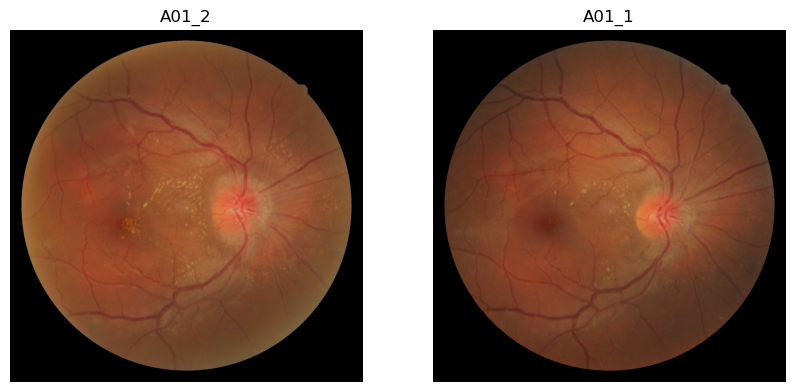

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
iter_dataloader = iter(dataloader)
first_batch = dataset.__getitem__(0)

img_ref, img_test, test_image_path, reference_image_path = first_batch
logs.debug(f'test image name: {Path(test_image_path).stem}, reference image name: {Path(reference_image_path).stem}')
logs.info(f'the test image shape is: {img_test.shape}, the reference image shape is: {img_ref.shape}')




def show_image(test_image : torch.Tensor,
               reference_image: torch.Tensor,
               test_image_name: str = '',
               reference_image_name: str = ''
               )->None:
    #reference_image, test_image, test_image_name, reference_image_name = batch in case to use the dataloader itself
    reference_image_name, test_image_name = str(reference_image_name), str(test_image_name)
    converted_image= []
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    for image in (test_image, reference_image):
        image = image.squeeze()
        channel_axis = torch.argmin(torch.tensor(image.shape)).item()  # Find the channel axis
        if channel_axis==0:
            image = image.permute(1, 2, 0)  # Move channel to last dimension
        image= image.numpy() 
        converted_image.append(image)
    test_image, reference_image = converted_image
    ax[0].imshow(test_image)
    ax[0].set_title(f'{test_image_name}')
    ax[0].axis('off')
    ax[1].imshow(reference_image)
    ax[1].set_title(f'{reference_image_name}')
    ax[1].axis('off')
    plt.show()

show_image(test_image=img_test, reference_image=img_ref, test_image_name=Path(test_image_path).stem, reference_image_name=Path(reference_image_path).stem)



In [52]:
sys.path

['C:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE\\Main_Folder\\Modules',
 'C:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\python312.zip',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\DLLs',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg',
 '',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages',
 'c:\\users\\gioco\\desktop\\unibork\\tesi_magistrale\\repositories\\airlab\\airlab',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\win32',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\gioco\\anaconda3\\envs\\ImgReg\\Lib\\site-packages\\Pythonwin']

#### Sample Dict Object

In [31]:

from typing import Callable, TypedDict, Optional, Tuple, Sequence, Required, NotRequired, Union
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import itk
from Main_Folder.Modules.framework import preprocessing
from itertools import islice
from airlab.utils.image import Image as AirlabImage
from Main_Folder.Modules.framework.data_classes import SampleDict
import logging
import torch
import SimpleITK as sitk

image_type = Union[torch.Tensor, itk.Image, sitk.Image, AirlabImage]
#---------------------
#REGISTRATION PIPELINE
#---------------------
# ALREADY DEFINED: 
# DATASET ---> DataLoader to be inserted in the pipeline


sample_dictA01 = preprocessing.general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)


[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  
[INFO] Main_Folder.Modules.framework.preprocessing - preprocessing sample shape: torch.Size([3, 2912, 2912]), torch.Size([3, 2912, 2912])
[INFO] Main_Folder.Modules.framework.preprocessing - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements
[INFO] Main_Folder.Modules.framework.preprocessing - reference/test image sample shape: torch.Size([3, 2912, 2912])


In [27]:
sample_dictA01['reference_sample'].shape

torch.Size([3, 2912, 2912])

### CUSTOM DATALOADER

In [ ]:
from Main_Folder.Modules.framework.data_classes import ImageRegistrationCustom


imreg_dataset = ImageRegistrationCustom(dataset_folder_path=fire_dataset_path)

img= imreg_dataset.load_image(deformation='', index='random')

timg, rimg, deformation = imreg_dataset.get_coupled_imgs()

logs.info(f'the shape of the image *test_img* open with Image.open(Path): {np.asarray(PImage.open(timg)).shape}, type {type(PImage.open(timg))}\n just befor numpy conversion')
logs.info(f'the shape of the image *test_img* open with Image.open(Path) and then converted to numpy array: {np.asarray(PImage.open(timg)).shape}, type {type(np.asarray(PImage.open(timg)))}\n just befor tensor conversion')

[WARNING] __main__ - Not a valid choice of deformation, the entire dataset is used as a batch
[INFO] __main__ - the selected/chosen image is S05_2.jpg, from Super_Resolution folder of Test
[INFO] __main__ - the shape of the image *test_img* open with Image.open(Path): (2912, 2912, 3), type <class 'PIL.JpegImagePlugin.JpegImageFile'>
 just befor numpy conversion
[INFO] __main__ - the shape of the image *test_img* open with Image.open(Path) and then converted to numpy array: (2912, 2912, 3), type <class 'numpy.ndarray'>
 just befor tensor conversion


In [29]:
if IN_COLAB:
    %cd '/content'

In [ ]:
import Main_Folder.Modules.framework.preprocessing
first_sample= dataset.__getitem__(0)
sample_temp = preprocessing.general_preprocessing(sample_dict=first_sample, config_dict= config_dict)
sample_temp['reference_sample'].shape, sample_temp['test_sample'].shape

[INFO] __main__ - preprocessing sample shape: torch.Size([3, 2912, 2912]), torch.Size([3, 2912, 2912])
[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements
[INFO] __main__ - reference/test image sample shape: torch.Size([3, 2912, 2912])


(torch.Size([3, 2912, 2912]), torch.Size([3, 2912, 2912]))

'c:\\Users\\gioco\\Desktop\\GITHUB_MAIN_FOLDER\\ImRegODE\\Main_folder\\Modules\\dataset\\FIRE\\Images\\Test\\Longitudinal_Studies\\A01_2.jpg'

In [ ]:
data_load_temp=DataLoader(dataset, shuffle=False, batch_size=1)
iterator_dataloader = iter(data_load_temp)
dataloader_first_sample = next(iterator_dataloader)
sample_dataloaded = preprocessing.general_preprocessing(sample_dict=dataloader_first_sample, config_dict=config_dict)
sample_dataloaded['reference_sample'].shape, sample_dataloaded['test_sample'].shape

[INFO] __main__ - preprocessing sample shape: torch.Size([1, 3, 2912, 2912]), torch.Size([1, 3, 2912, 2912])
[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements
[INFO] __main__ - reference/test image sample shape: torch.Size([1, 3, 2912, 2912])


(torch.Size([1, 3, 2912, 2912]), torch.Size([1, 3, 2912, 2912]))

### DATALOADER + PYRAMID 
get the dataloader from simply dataloader and add pyramid transformation after transforms...

In [76]:
tot_img = 2
img_x_row = 3
n_cols= min(tot_img, img_x_row)
n_row = tot_img//img_x_row + int(bool(tot_img/img_x_row - tot_img//img_x_row))

n_chat = (tot_img +n_cols -1)//n_cols
n_row, n_chat


(1, 1)

In [91]:
int(1.5*2912/9)

485

# PREPROCESS:  the images from the dataloader for the nn

[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  
[INFO] Main_Folder.Modules.utils - the image shape torch.Size([3, 2912, 2912]) will be transposed in the format **C
[INFO] Main_Folder.Modules.utils - the image shape torch.Size([3, 2912, 2912]) will be transposed in the format **C
[DEBUG] Main_Folder.Modules.framework.preprocessing - the shape of the original moving image is: (2912, 2912, 3), the shape of the cropped moving image is: torch.Size([1941, 1941, 3])
[DEBUG] Main_Folder.Modules.framework.preprocessing - the shape of the original fixed image is: (2912, 2912, 3),

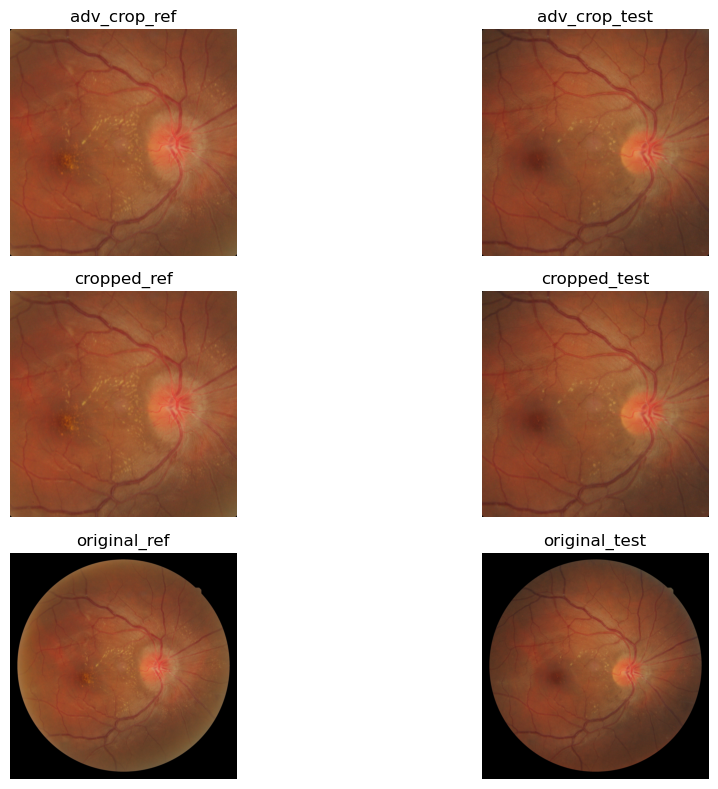

In [130]:
from Main_Folder.Modules.framework import preprocessing
from Main_Folder.Modules.configuration_setting import yaml_configuration
from Main_Folder.Modules.framework import visualization

config_dict = yaml_configuration.FrameworkConfig()

cropped_moved_image, cropped_fixed_image = preprocessing.crop_images(moving_image=sample_dictA01['test_sample'], 
                                                    fixed_image=sample_dictA01['reference_sample'],
                                                    config_dict =config_dict )
crop_dict={'final_height' : 1941,
           'final_width' : 1941}
_, advance_crop_reference = preprocessing.crop_image_advance(original_image =sample_dictA01['reference_sample'].unsqueeze(0), 
                                                             config_dict=crop_dict,
                                                             new_O_O = [485,485],
                                                             crop_style='shrink_to_fit')
_, advance_crop_test = preprocessing.crop_image_advance(original_image =sample_dictA01['test_sample'].unsqueeze(0), 
                                                             config_dict=crop_dict,
                                                             new_O_O = [485,485],
                                                             crop_style='shrink_to_fit')

image_list = [advance_crop_reference, advance_crop_test, cropped_fixed_image, cropped_moved_image, sample_dictA01['reference_sample'], sample_dictA01['test_sample_path']]
title_list = ['adv_crop_ref', 'adv_crop_test', 'cropped_ref', 'cropped_test',  'original_ref', 'original_test']
visualization.show_images(image_list= image_list,
                          image_title_list= title_list,
                          images_for_row=2)


In [131]:
torch.equal(cropped_moved_image , utils.permute_channel_layout((advance_crop_test.squeeze()), target_format='**C'))

[INFO] utils - the image shape torch.Size([3, 1941, 1941]) will be transposed in the format **C


False

torch.Size([1941, 1941, 3])

In [77]:
from fractions import Fraction
crop_dict = config_dict['constant']['num-like']['crop_dict']
float(Fraction(crop_dict['area_ratio'])), crop_dict['final_height']

(0.5, 0)

In [81]:
from Main_Folder.Modules.configuration_setting import yaml_configuration
num_dict = yaml_configuration.FrameworkConfig().num_dict
num_dict 

[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  


{'LOWEDGE_BOX': 0.16666666666666666,
 'HIGHEDGE_BOX': 0.8333333333333334,
 'n_iterations': 500,
 'max_sample': 2,
 'batch_size': 1,
 'crop_dict': {'area_ratio': 0.5, 'final_height': 0, 'final_width': 100}}

In [140]:
from PIL import Image as PImage
from torchvision import transforms
from Main_Folder.Modules.framework import preprocessing
import cv2
config_dict = yaml_configuration.FrameworkConfig().config_dict
crop_dict = config_dict['constant']['num-like']['crop_dict']

H, W = 200, 100
y, x = torch.meshgrid(
    torch.arange(H),
    torch.arange(W),
    indexing='ij'
)
img = ((y *x)).int()

print(img.shape)
img_cv2 = torch.tensor(cv2.normalize(img.numpy().astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F))
img_norm= preprocessing.normalize_img(img)

print(img)
img=img.unsqueeze(0).repeat(3,1,1)
img=img.unsqueeze(0)

print(img.shape)

crop_dict_results, cropped_img = preprocessing.crop_image_advance(original_image=img,
                                                            crop_mode = 'area_ratio',
                                                            config_dict=crop_dict,)
print(f'''the original image shape: {img.shape}, the desired final dimension of cropped image: [{crop_dict['final_height']}, {crop_dict['final_width']}]''')
for k,v in crop_dict_results.items():
    print(f'{k} :  {v}')

[INFO] Main_Folder.Modules.configuration_setting.yaml_configuration -  opening the file config_file to downloading the dict
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - prior conversion of path-like: the RESULTS term is ['Main_Folder', 'Results']
[DEBUG] Main_Folder.Modules.configuration_setting.yaml_configuration - after conversion of paths-like, the RESULTS term began:C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results  
[DEBUG] Main_Folder.Modules.framework.preprocessing - the measure chosen for the crop
final_height: 0; final_width: 100
[DEBUG] Main_Folder.Modules.framework.preprocessing - 
original_center: [100, 50]
[DEBUG] Main_Folder.Modules.framework.preprocessing - 
after asdjusting the measure
final_height: 0; final_width: 100
[DEBUG] Main_Folder.Modules.framework.preprocessing - 
after adjusting the measure considering the AREA_RATIO 
final_height: 100.0; final_width: 100
[DEBUG] Main_Folder.Modules.framework.preprocessing - 
afte

torch.Size([200, 100])
tensor([[    0,     0,     0,  ...,     0,     0,     0],
        [    0,     1,     2,  ...,    97,    98,    99],
        [    0,     2,     4,  ...,   194,   196,   198],
        ...,
        [    0,   197,   394,  ..., 19109, 19306, 19503],
        [    0,   198,   396,  ..., 19206, 19404, 19602],
        [    0,   199,   398,  ..., 19303, 19502, 19701]], dtype=torch.int32)
torch.Size([1, 3, 200, 100])
the original image shape: torch.Size([1, 3, 200, 100]), the desired final dimension of cropped image: [0, 100]
h_f :  100
w_f :  100
image_center :  [100, 50]
corner_coords :  [50, 0]


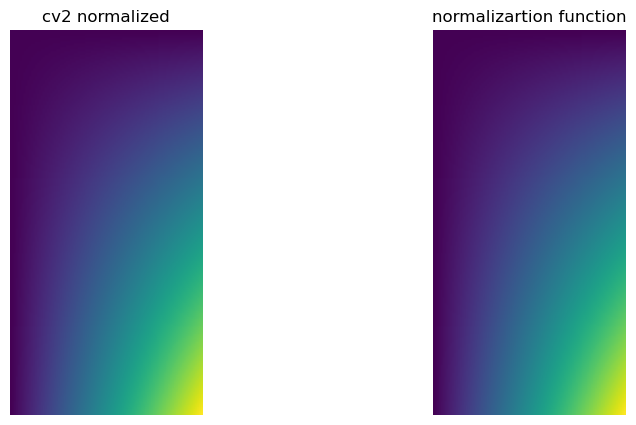

In [130]:
show_image(test_image=img_cv2, reference_image=img_norm, test_image_name='cv2 normalized', reference_image_name = 'normalizartion function')



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..14751].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..19701].


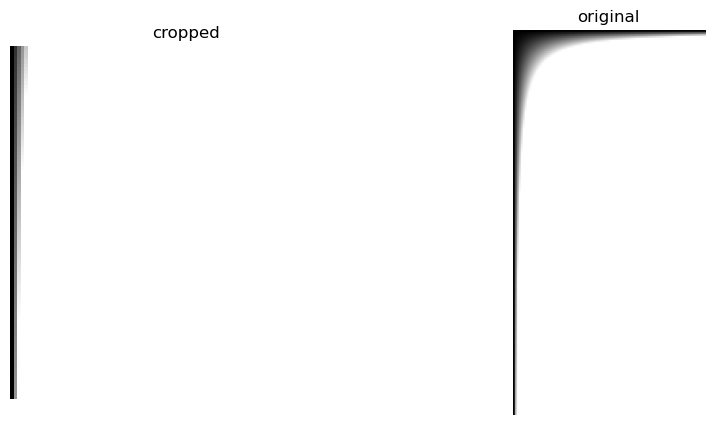

In [131]:
show_image(test_image=cropped_img, reference_image=img, test_image_name='cropped', reference_image_name = 'original')

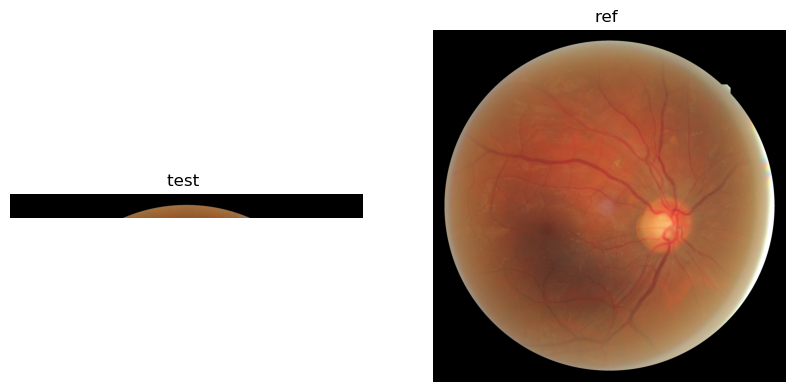

In [132]:
show_image(test_image=test_image[:,:,:200,:], reference_image=reference_image, test_image_name='test ', reference_image_name='ref ')

In [35]:
# given the two tensor with shape of [1, 3, 1941, 1941]
# get the pyramid of images from skimage.transform.pyramid_gaussian
from skimage.transform import pyramid_gaussian
from skimage.filters import gaussian

config_dict = default_notebook_config_dict()


def coupled_gaussian_pyramid(sample_dict: SampleDict,
                             config_dict : dict,
                             )-> SampleDict:
    '''
    it takes two images to performa gaussian filter in 6 progressive steps
    Parameter
    ---------
    sample_dict (SampleDict): the dict with sample's  data 
    config_dict (dict): the dict with configuration parameters

    Returns
    -------
    SampleDict: updated sample dcit with the pyramids of images for both test and reference images

    '''   
    logs= logging.getLogger(__name__)
    fixed_image = sample_dict['reference_sample']
    moving_image = sample_dict['test_sample']
    drmine_pyramid_dict = config_dict['registrations']['DRMINE_original']['pyramid']
    downscale = drmine_pyramid_dict['gaussian_downscale']
    gaussian_sigma = drmine_pyramid_dict['gaussian_sigma']
    if np.ndim(fixed_image) != np.ndim(moving_image) or type(fixed_image) != type(moving_image):
      raise ValueError("the two images must have the same type and dimension")
    else:

        if isinstance(fixed_image, torch.Tensor):
            
            fixed_image = fixed_image.squeeze().permute(1,2,0)
            moving_image = moving_image.squeeze().permute(1,2,0)
        if np.ndim(fixed_image) == 3:
            logs.debug(f'the shape of the fixed image is: {fixed_image.shape}, the shape of the moving image is: {moving_image.shape}')
            
            channel_axis = torch.argmin(torch.tensor(fixed_image.shape)).item()
            nChannel = fixed_image.shape[channel_axis]
            logs.info(f'the number of channels in the images is: {nChannel}')
            pyramid_fixed = tuple(torch.from_numpy(pyr) for pyr in pyramid_gaussian(gaussian(fixed_image, sigma=gaussian_sigma, channel_axis=channel_axis), downscale=downscale, channel_axis=channel_axis)) # NOTE multichannel = True?
            pyramid_moving = tuple(torch.from_numpy(pyr) for pyr in pyramid_gaussian(gaussian(moving_image, sigma=gaussian_sigma, channel_axis=channel_axis), downscale=downscale, channel_axis=channel_axis)) # NOTE multichannel = True?
        elif np.ndim(fixed_image) == 2:
            nChannel=1
            pyramid_fixed = tuple(torch.from_numpy(pyr) for pyr in pyramid_gaussian(gaussian(fixed_image, sigma=gaussian_sigma, channel_axis=None), downscale=downscale)) # NOTE multichannel = False?
            pyramid_moving = tuple(torch.from_numpy(pyr) for pyr in pyramid_gaussian(gaussian(moving_image, sigma=gaussian_sigma, channel_axis=None), downscale=downscale)) # NOTE multichannel = False?
        else:
            logs.warning(f"Unknown rank for an image: {np.ndim(fixed_image)}")

    sample_dict['reference_pyramid'] = pyramid_fixed
    sample_dict['test_pyramid'] = pyramid_moving
    sample_dict['nChannel'] = nChannel
    return sample_dict

sample_dictA01 = coupled_gaussian_pyramid(sample_dict=sample_dictA01, config_dict=config_dict)
pyramid_ref, pyramid_mov, nChannel = sample_dictA01['reference_pyramid'], sample_dictA01['test_pyramid'], sample_dictA01['nChannel']


[DEBUG] __main__ - the shape of the fixed image is: torch.Size([2912, 2912, 3]), the shape of the moving image is: torch.Size([2912, 2912, 3])
[INFO] __main__ - the number of channels in the images is: 3


In [ ]:
from typing import Literal
import torch
# NOTE in utils script.py

def permute_channel_layout(
    image: torch.Tensor,
    target_format: Literal["**C", "C**"],
    n_channel: int | None = None,
) -> torch.Tensor:
    """
    Convert image layout between channel-last (**C) and channel-first (C**).

    "**C" means (H, W, C)
    "C**" means (C, H, W)
    Parameters
    ----------
    image: (torch.Tensor) the image to permute dimensions
    target_format (Literal['**c', 'c**']): define the final format of image, to adjust the permutation considering this
    n_channel (Optional[int]): for different type of images where nChannels is not standard as the minimum of args of [C, H, W]

    If the image is grayscale after squeeze, i.e. ndim <= 2,
    it is returned unchanged.
    """
    logs=logging.getLogger(__name__)

    image = image.squeeze()

    if image.ndim <= 2:
        logs.info('the image is a grayscale, no need to permute it')
        return image

    if image.ndim != 3:
        raise ValueError(
            f"Expected a 2D or 3D image after squeeze, got shape {image.shape}"
        )

    d1, _, d3 = image.shape

    if n_channel is not None:
        if d1 == n_channel:
            current_format = "C**"

        elif d3 == n_channel:
            current_format = "**C"
        else:
            raise ValueError(
                f"Cannot find channel dimension with n_channel={n_channel} "
                f"in image shape {image.shape}"
            )
    else:
        # fallback euristico: il canale è la dimensione più piccola
        channel_axis = torch.argmin(torch.tensor(image.shape)).item()

        if channel_axis == 0:
            current_format = "C**"
        elif channel_axis == 2:
            current_format = "**C"
        else:
            raise ValueError(
                f"Channel axis appears to be in the middle for shape {image.shape}. "
                "Expected channel-first or channel-last."
            )

    if current_format == target_format:
        logs.info(f'the image shape {image.shape} is already in the format {target_format}')
        return image

    if current_format == "**C" and target_format == "C**":
        logs.info(f'the image shape {image.shape} will be transposed in the format {target_format}')
        return image.permute(2, 0, 1)

    if current_format == "C**" and target_format == "**C":
        logs.info(f'the image shape {image.shape} will be transposed in the format {target_format}')
        return image.permute(1, 2, 0)

    raise ValueError(f"Unsupported target_format: {target_format}")

In [ ]:


pyr_2 = pyramid_ref[1]
logs.info(f'pyr_2 has shape {pyr_2.shape}')
permuted_img = permute_channel_layout(image=pyr_2, target_format='C**')
permuted_img.shape


[INFO] __main__ - pyr_2 has shape torch.Size([1456, 1456, 3])
[INFO] __main__ - the image shape torch.Size([1456, 1456, 3]) will be transposed in the format C**


torch.Size([3, 1456, 1456])

In [40]:
import numpy as np
import torch
# FIXME set torch as  default instead of numpy
def normalize(tens_image : torch.Tensor | np.ndarray
              )-> torch.Tensor:
    '''
    get a tensor to normalize it throught the scaler
    it does the same as cv2.normalize(IMAGE:np.ndarray, alpha=0, beta=1, norm_type= cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    Parameters
    ----------
    tens_image : torch.Tensor | np.ndarray
        the image to normalize, it can be a tensor or a numpy array

    Returns
    -------
    torch.Tensor
        the normalized image in the range [0, 1]
    '''
    if isinstance(tens_image, np.ndarray):
        tens_image= torch.from_numpy(tens_image).float()
    maxim = torch.max(tens_image)
    minim = torch.min(tens_image)
    
    if maxim == minim:
        return torch.zeros_like(tens_image)

    return (tens_image -minim)/ (maxim - minim)
    

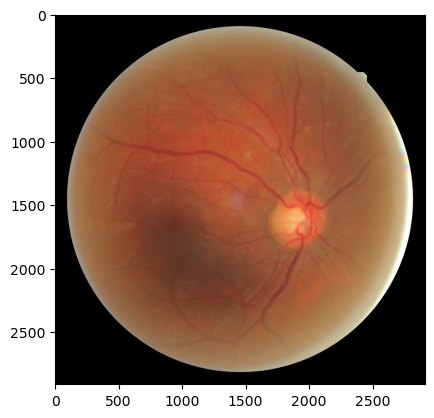

In [41]:
norm_f_image = normalize(reference_image)
plt.imshow(norm_f_image.squeeze().permute(1,2,0).numpy())

## INSPECTING DRMINE'S NN 
da supervisionare e rimuovere parti no nencessarie


In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from typing import Optional, Literal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logs.info(device)

[INFO] __main__ - cpu


In [141]:
# NOTE For get the image use the dataset /dataloader already coded
!tree /F "C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE" /A

Elenco del percorso delle cartelle per il volume Windows
Numero di serie del volume: 00000203-1E78:146C
C:\USERS\GIOCO\DESKTOP\GITHUB_MAIN_FOLDER\IMREGODE
|   .gitignore
|   .gitmodules
|   colab-requirements.txt
|   colab-tree.txt
|   config.txt
|   config_file.yaml
|   LICENSE
|   local-requirement.txt
|   local-tree.txt
|   pyproject.toml
|   README.md
|   tomlforuv.toml
|   
+---.mypy_cache
|   |   .gitignore
|   |   CACHEDIR.TAG
|   |   
|   \---3.12
|       |   @plugins_snapshot.json
|       |   abc.data.json
|       |   abc.meta.json
|       |   builtins.data.json
|       |   builtins.meta.json
|       |   codecs.data.json
|       |   codecs.meta.json
|       |   configparser.data.json
|       |   configparser.meta.json
|       |   contextlib.data.json
|       |   contextlib.meta.json
|       |   dataclasses.data.json
|       |   dataclasses.meta.json
|       |   enum.data.json
|       |   enum.meta.json
|       |   genericpath.data.json
|       |   genericpath.meta.json
|      

In [173]:
from typing import Any
from torch import nn

class HomographyNet(nn.Module):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    def __init__(self, device=device):
        '''
        imposing the parameters for the matrix of affine trasformation as some of a nn, 
        whose layer depends on the matrix expo respecting the resolution level
        
        PARAMETERS:
        -----------

        device : torch.device
            the device to use for the model, default is cuda if available, otherwise cpu
        B : torch.Tensor
            the basis of generator of the affine transformation, it is a tensor of shape (6, 3, 3) 
            where each slice B[i] is a base generator
        v1 : torch.nn.Parameter
            the parameters for the affine transformation at the highest resolution level, it is a tensor of shape
            (6, 1, 1) and it is initialized as zeros, it is a learnable parameter that will be updated during training
        vL : torch.nn.Parameter
            the parameters for the affine transformation at the lower resolution levels, it is a tensor of shape
            (6, 1, 1) and it is initialized as zeros, it is a learnable parameter that will be updated during training

        FORWARD INPUT: 
        --------------

        s : int
            the resolution level, it is an integer that can take values from 0 to 6, 
            where 0 is the highest resolution level and 6 is the lowest resolution level, it is used to decide which parameters to use for the affine transformation


        RETURNS:
        --------

        H : torch.Tensor
            the homography matrix, it is a tensor of shape (3, 3)
            obtained by matrix exponentiation of C

        '''
        super(HomographyNet, self).__init__()
        # affine transform basis matrices
        self.logs = logging.getLogger(f'{__name__}.{type(self).__name__}')

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri - base for initialize the affine matrix transformation as ones for affine
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def get_param_groups(self,
                         lr : float | dict[str, float],
                         )->list[dict[str, Any]]:
        '''
        Get the list of dicts to extract parameter and their lr

        Args:
            lr (float | dict[str, float]): the lr for model.parameters if it's a float, or for specific parameters otherwise

        Returns:
            list[dict[str, Any]]: _description_
        '''
        
        if isinstance(lr, (float, int)):
            self.logs.info(f'using the list of parameters: {list(dict(self.named_parameters()).keys())} with lr: {lr}')
            return [{'params' : self.parameters(), 'lr': float(lr)}]
        else:
            params_dict =  dict(self.named_parameters())
            param_groups = []
            for name, lr_val in lr.items():

                if not name in params_dict:
                    self.logs.error(f"Attribute {name} not found in {type(self).__name__}")
                    continue

                param_groups.append({'params': [params_dict[name]], 'lr': lr_val})
                
            if not param_groups:
                self.logs.warning(f'No valid parameters found in the provided lr dictionary: {lr}')
        return param_groups

    def forward(self, s): # depending the resolution the matrix expo define the approximation for the homography matrix
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel più alto livello di risoluzione vine eaggiunto un parametro correttivo v1
            C += torch.sum(self.B*self.v1,0) 
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10): # prova torch.matrixexp(C)
            A = torch.mm(A/i,C) 
            H = H + A
        return H
Homography_net = HomographyNet()

In [ ]:
homo_net= HomographyNet()

homo_net.get_param_groups(lr=2.4), homo_net

from Main_Folder.Modules.download import import_trial

import_trial()
permute_channel_layout


[INFO] __main__.HomographyNet - using the list of parameters: ['v1', 'vL'] with lr: 2.4


successful


In [168]:
import sys
from pathlib import Path
import importlib

project_path = Path(PROJECT_PATH).resolve()
project_path_str = str(project_path)

# Elimina TUTTE le occorrenze del progetto, sia Path che stringhe
sys.path = [
    p for p in sys.path
    if str(p) != project_path_str
]

# Inserisce SOLO la stringa
sys.path.insert(0, project_path_str)

importlib.invalidate_caches()

print(type(sys.path[0]))
print(sys.path[0])

<class 'str'>
C:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE


In [ ]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        
        '''
        Creation of MINE net for calculating Mutual Information lower bound: Ml_lb
        - fc1 1st layer for blended rappresentation of reference and test
            (it gets the doubled inputs of reference and test image color channel)
        -fc2 2nd layer increases non linearity of the nn: elaboration single hidden layer
        -fc3 3rd layer elaborate a rapresentative number for each coupled (x,y): it performa calculation for mutual information


        Args:
            nChannel (int): number of color channels
        '''
        super(MINE, self).__init__()
        self.logs = logging.getLogger(f'{__name__}.{type(self).__name__}')
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 #NOTE  number of permutation for assesting MI_lb, (may be sufficient)
    
    def get_param_groups(self,
                         lr : float | dict[str, float],
                         )->list[dict[str, Any]]:
        '''
        Get the list of dicts to extract parameter and their lr

        Args:
            lr (float | dict[str, float]): the lr for model.parameters if it's a float, or for specific parameters otherwise

        Returns:
            list[dict[str, Any]]: _description_
        '''
        
        if isinstance(lr, (float, int)):
            self.logs.info(f'using the list of parameters: {list(dict(self.named_parameters()).keys())} with lr: {lr}')
            return [{'params' : self.parameters(), 'lr': float(lr)}]
        else:
            params_dict =  dict(self.named_parameters())
            param_groups = []
            for name, lr_val in lr.items():

                if not name in params_dict:
                    self.logs.error(f"Attribute {name} not found in {type(self).__name__}")
                    continue

                param_groups.append({'params': [params_dict[name]], 'lr': lr_val})
                
            if not param_groups:
                self.logs.warning(f'No valid parameters found in the provided lr dictionary: {lr}')
        return param_groups


    def forward(self, x, ind):
        '''
        Calculate a T_score(x, y) for each bsize(permutation)
        z1: representing the matching couple scored: T(x_i, y_i) expecting to be high
        z2: representing the unmatching couple scored: T(x_i, y_j) expecting to be low when i!=j indeeed (log(exp(t)) t->0 --> 1 )


        Args:
            x (torch.Tensor): the input tensor of shape (H, W, 2*nChannels) where nChannel is the number of color channels, H and W are the height and width of the images
            ind (torch.Tensor): the indices available for the coupled images: (HxWxS) where S is the sampling ratio (0:1)
                                if u want to modify the batch of samples u have to modify this tensor: **they are the batch of point used for metric calculation**

        Returns:
            Ml_lb:  Mutual information lower bound
            z1, z2:  for visualization purpose
        '''
        x = x.view(x.size()[0]*x.size()[1],x.size()[2]) # FIXME change in x = x.reshape(-1, 2*self.nChannel) or equivalently with x=x.contiguous().view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind), device= ind.device)]
            while torch.equal(ind_perm, ind): #NOTE loop while aggiunto, prova ablation study con questo loop
                perm = ind[torch.randperm(len(ind), device=ind.device)]
                ind_perm = ind[perm]

            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [47]:
mi_net = MINE(nChannel = 3)
for k, v in dict(mi_net.named_parameters()).items():
    print(k)

fc1.weight
fc1.bias
fc2.weight
fc2.bias
fc3.weight
fc3.bias


In [48]:
config_dict_es = {'HomographyNet': 'all is good', 
                  'MINE': 'this works too'}
dict_es = {'trasformation': HomographyNet,
           'metric' : MINE }

kwargs_net= {'registrations':
             {'MINE': {
              'nChannel':3,
              },
              'HomographyNet':{},
              },
              'constant': {'a': 3}
}
res_dict= {}
net_suc_init= {}
for pourpose, net in dict_es.items():
    res = config_dict_es.get(net.__name__, 'not good' )
    kwarg_net = kwargs_net['registrations'].get(net.__name__, {})
    net_suc_init[pourpose] = net(**kwarg_net)
    res_dict[pourpose]= res
net_suc_init['metric']

MINE(
  (fc1): Linear(in_features=6, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (fc3): Linear(in_features=100, out_features=1, bias=True)
)

In [ ]:
import cv2
from typing import Sequence, Any

def extract_registration_params(sample_dict : SampleDict,
                        config_dict: dict,
                        
                        device : torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                        ) -> dict[str, Any]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  sample_dict (SampleDict): the dict containing all information about the sample useful for registration loop
  config_dict (dict): the dict representing the yaml configuration file
  device (torch.device): to put the tensor on the correct device during execution and calcula

  Returns
  -------
  dict: {'I_lst': I_lst,  list[torch.Tensor] the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  'J_lst': J_lst,  list[torch.Tensor] the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  'x_': x_, list[torch.Tensor] the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  'y_': y_, list[torch.Tensor] the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  'xy_': xy_lst,  list[torch.Tensor] the coordinates for the homography mapping
  'ind_': ind_lst,  list[torch.Tensor] the list of indeces from whose loss is calculated
  'h_': h_lst, list[int] the heights of images in pyramid, necessary due downsampling
  'w_': w_lstlist[int] the widths of images in pyramid, necessary due downsampling
  }

  '''
  
  logs=logging.getLogger(__name__)
  # ======== GET VALS from CONFIG_DICT=============
  parameter_dict_configuration = config_dict['registrations']['DRMINE_original']
  sampling= parameter_dict_configuration['sampling_ratio']
  L = parameter_dict_configuration['pyramid']['gaussian_levels']
  reference_pyramid= sample_dict['reference_pyramid']
  test_pyramid = sample_dict['test_pyramid']
  nChannel = sample_dict['nChannel']
  
  if not (0.0 < sampling <= 1.0) :
    logs.error(f' the sampling ratio must be equal up to 1.0, so {sampling} will be set to 0.1 as default')
    sampling = 0.1

  reference_lst, test_lst, heights_lst, widths_lst, xy_lst, ind_lst=[],[],[],[],[],[] #one feature for each level of the pyramid


  for s in range(L): # for each level of resolution pyramids
    ref_ = torch.tensor(cv2.normalize(reference_pyramid[s].numpy(), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    tst_ = torch.tensor(cv2.normalize(test_pyramid[s].numpy(), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        reference_lst.append(permute_channel_layout(image=ref_, target_format = 'C**')) # permute (H,W, C) -> (C, H, W)
        test_lst.append(permute_channel_layout(image=tst_, target_format = 'C**')) # permute (H,W, C) -> (C, H, W)
        height_, width_ = reference_lst[s].shape[1], reference_lst[s].shape[2]
        ind_ = torch.randperm(int(height_*width_*sampling), device=device) # FIXME usa sempre lo stesso bacino di pixel ( il primo 10%), se volessi renderlo davvero randomico dovrei usare ind_ = torch.randperm(int(h_*w_))[:int(h_*w_*sampling)] 
        ind_lst.append(ind_)
    else:
        reference_lst.append(ref_)
        test_lst.append(tst_)
        height_, width_ = reference_lst[s].shape[0], reference_lst[s].shape[1]
        ind_ = torch.randperm(int(height_*width_*sampling), device=device)# FIXME usa sempre lo stesso bacino di pixel ( il primo 10%), se volessi renderlo davvero randomico dovrei usare ind_ = torch.randperm(int(h_*w_))[:int(h_*w_*sampling)] 
        ind_lst.append(ind_)
    heights_lst.append(height_)
    widths_lst.append(width_)

    y_, x_ = torch.meshgrid([torch.arange(0,height_).float().to(device), torch.arange(0,width_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(height_-1) - 1.0, 2.0*x_/(width_-1) - 1.0 # normalization [0, 0] -> [-1, -1], [h,w] -> [1, 1]
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return {'reference_lst' : reference_lst,
          'test_lst': test_lst,
          'x_' : x_,
          'y_': y_,
          'xy_lst': xy_lst,
          'ind_lst': ind_lst,
          'heights_lst': heights_lst,
          'width_lst': widths_lst
          }
  
config_dict = default_notebook_config_dict()
registration_params_dict = extract_registration_params(sample_dict=sample_dictA01,config_dict= config_dict)


[INFO] __main__ - the image shape torch.Size([2912, 2912, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([2912, 2912, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([1456, 1456, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([1456, 1456, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([728, 728, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([728, 728, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([364, 364, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([364, 364, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([182, 182, 3]) will be transposed in the format C**
[INFO] __main__ - the image shape torch.Size([182, 182, 3]) will be transposed in the format C**
[INFO] __main__ - the 

In [190]:
sample_dictA01.keys(), registration_params_dict.keys(), registration_params_dict['xy_lst'][5][:,:,1].size()

(dict_keys(['reference_sample', 'test_sample', 'reference_sample_path', 'test_sample_path', 'sample_name']),
 dict_keys(['reference_lst', 'test_lst', 'x_', 'y_', 'xy_lst', 'ind_lst', 'heights_lst', 'width_lst']),
 torch.Size([91, 91]))

[INFO] __main__ - the image shape torch.Size([3, 91, 91]) will be transposed in the format **C


(np.float64(-0.5), np.float64(90.5), np.float64(90.5), np.float64(-0.5))

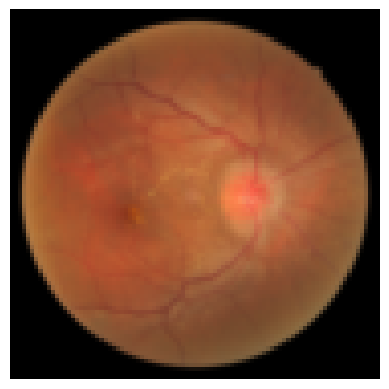

In [50]:
plt.imshow(permute_channel_layout(image=registration_params_dict['reference_lst'][-1], target_format='**C'))
plt.axis('off')

In [176]:
res = 2
temp_I = registration_params_dict['reference_lst'][res].unsqueeze(0)
H = HomographyNet()
xv= registration_params_dict['xy_lst'][res][:,:,0]
yv = registration_params_dict['xy_lst'][res][:,:,1]
warped_image = AffineTransform(I=temp_I, H = H(res), xv = xv, yv=yv)
warped_image.shape

torch.Size([3, 728, 728])

In [206]:
def AffineTransform(I: torch.Tensor,
                    H: HomographyNet,
                    xv: torch.Tensor, 
                    yv: torch.Tensor
                    ) -> torch.Tensor:
    '''
    Apply a homography transformation to an image.

    Args:
        I (torch.Tensor): The input image, as the image to be warped, since grid_sample has to be used I.shape should follow: (N, C, H, W)
        H (torch.Tensor): The homography matrix, to apply.
        xv (torch.Tensor): The x coordinates of the points to transform, as x vector
        yv (torch.Tensor): The y coordinates of the points to transform, as y vector

    Returns:
        torch.Tensor: The transformed image.
    '''
    convert_on_same_device = False
    
    for tensor in [I, H, xv, yv]:
        if tensor.device == 'cuda':
            convert_on_same_device=True
            
    if convert_on_same_device:
        for tensor in [I, H, xv, yv]:
            tensor.to('cuda')

    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze() #NOTE the grid params in grid_sample it has to be of sahpe (N, H, W, 2)
    # NOTE use mode = 'nearest' & padding_mode='border'
    return J



def multi_resolution_loss(I_lst : list[torch.Tensor],
                          J_lst : list[torch.Tensor],
                          xy_lst : list[torch.Tensor],
                          ind_lst : list[torch.Tensor],
                          homography_net : HomographyNet,
                          mine_net : MINE,
                          
                          
                          nChannel : int = 3,
                          
                          )-> Tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]:
    '''
    the loss calculated along the multiresolution pyramid: loss = Sum[L]: mi/L()

    Args:
        I_lst (list[torch.Tensor]): the Multiresolution Pyramid of the REFERENCE image
        J_lst (list[torch.Tensor]): the Multiresolution Pyramid of the TEST image
        xy_lst (list[torch.Tensor]): the list of x,y coordinates on which the homography/affinity is applied (H)
        ind_lst (list[torch.Tensor]): the list of indices from which calculate the loss
        homography_net (HomographyNet): the homography matrix specified for multiresolution loss ( depending on the level s it change the compostision of exp(C))
            It has to be declared as hommography_net = HomographyNet() before the training loop and then passed as an argument to the loss function
        mine_net (MINE): nn to calculate the MI using the Donsker Varadam lower bound
        nChannel (int, optional): number of color channels. Defaults to 3.

    Returns:
        Tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]: it returns:
        loss (torch.Tensor) : the resulting summed mi calculation for all the pyramid levels ( to be backwarded in the nn training)
        z1 (list[torch.Tensor]) : the list of scores associated to the matching couple (x_i, y_i) for each pyramid level, to be used for visualization purpose
        z2 (list[torch.Tensor]) : the list of scores associated to the unmatching couple (x_i, y_j) for each pyramid level, to be used for visualization purpose
    '''
    assert I_lst[0].device == J_lst[0].device, "the two image pyramids must be on the same device"
    assert xy_lst[0].device == ind_lst[0].device, "the coordinates and the indices must be on the same device of the image pyramids"
    loss=I_lst[0].new_tensor(0.0) 
    z1, z2 = [], [] # NOTE use z1 z2 to track the loss doing on MINE net
    L = len(I_lst)
    for s in np.arange(L-1,-1,-1): #FIXME usa for s in range(L-1, -1, -1):...
      if nChannel>1: # for RGB images
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.cat([I_lst[s],Jw_],0).permute(1,2,0),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
      else: # for bn images
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0).unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.stack([I_lst[s],Jw_],2),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
    
    return loss, z1, z2

def pyramid_loss(sample_dict: SampleDict,
                 trasformation_network:nn.Module,
                 metric_network: nn.Module,
                 xy_lst: list[torch.Tensor],
                 ind_lst: list[torch.Tensor],
                 **kwargs
                 )-> tuple[torch.Tensor, dict]:
    '''

    Args:
        sample_dict (SampleDict): the dict containing most informations of sample 
        trasformation_network ([nn.Module]): network responsible of transformation (warping), NOT the type-data but the instantiated object
        metric_network ([nn.Module]): network responsible of metric calculation, NOT the type-data but the instantiated object
        xy_lst list[torch.Tensor]: list referring to each resolution-level of coordinates of each pixel in image. Defaults to None.
        ind_lst list[torch.Tensor]: list referring to each resolution-level of coordinates of pixel for loss_fn in images. Defaults to None.

    Returns:
        torch.Tensor: loss calcula
    '''
    total_loss = torch.tensor(0.0)
    levels = len(sample_dict['test_pyramid'])
    test_pyramid_lst = sample_dict['test_pyramid']
    reference_pyramid_lst = sample_dict['reference_pyramid']

 
    
    for level in np.arange(levels-1, -1, -1):
        if sample_dict['nChannel']>1:
            warped_image = AffineTransform(test_pyramid_lst[level].unsqueeze(0), trasformation_network(level), xy_lst[level][:,:,0], xy_lst[level][:,:,1]).squeeze()
            level_metric_loss, zii, zij = metric_network(torch.cat([reference_pyramid_lst[level],warped_image],0).permute(1,2,0),ind_lst[level]) # FIXME substitute with metric_network(permute_channel_layout(torch.cat([reference_pyramid_lst[level],warped_image],0), target_format = "**C"),ind_lst[level])
            total_loss = total_loss - (level_metric_loss/levels)
        else:
            warped_image = AffineTransform(test_pyramid_lst[level].unsqueeze(0).unsqueeze(0), trasformation_network(level), xy_lst[level][:,:,0], xy_lst[level][:,:,1]).squeeze()
            level_metric_loss, zii, zij = metric_network(torch.stack([reference_pyramid_lst[level], warped_image], 2), ind_lst[s])
            total_loss = total_loss - (level_metric_loss/levels)

    return total_loss, {'zii': zii, 
                        'zij': zij}

# mattes mutual information ( MMI)
def histogram_mutual_information(image1, image2):
    hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

def metric_outputs_update(start_dict : dict,
                          new_data: Optional[dict] = None,
                          )->dict:
    '''
    update input dict for a general type of metric to store output results

    Args:
        start_dict (dict): the starting point
        new_data ( Optional[dict], default to None): the new data

    Returns:
        dict: the update data list
    '''
    # ======== TRASFORM DATA TYPE ==========
    for k, v in start_dict.items():
        if isinstance(v, torch.Tensor):
            v=v.detach().cpu()
        if not isinstance(v, list):
            start_dict[k] = [v]

    if new_data is None:
        return start_dict
    
    for k, v in new_data.items():
        if isinstance(v, torch.Tensor):
            v= v.detach().cpu()

        if k not in start_dict:
            start_dict[k]=[v]
        else:
            start_dict[k].append(v)
    
    return start_dict


In [232]:
drmine_registration_lr = config_dict['registrations']['DRMINE_original']['lr']

flatten_dict

[INFO] __main__ - {'MINE': 0.01, 'HomographyNet': {'vL': 0.001, 'v1': 1e-05}}
[INFO] __main__ - k is MINE,  the final_key is 
[INFO] __main__ - the final_key after joining k is MINE
[INFO] __main__ - the final_key after joining . is .
[INFO] __main__ - k is HomographyNet,  the final_key is .
[INFO] __main__ - the final_key after joining k is H.o.m.o.g.r.a.p.h.y.N.e.t
[INFO] __main__ - the final_key after joining . is .


{'.': 0.01,
 'H.o.m.o.g.r.a.p.h.y.N.e.t': 0.001,
 'HH.o.m.o.g.r.a.p.h.y.N.e.toH.o.m.o.g.r.a.p.h.y.N.e.tmH.o.m.o.g.r.a.p.h.y.N.e.toH.o.m.o.g.r.a.p.h.y.N.e.tgH.o.m.o.g.r.a.p.h.y.N.e.trH.o.m.o.g.r.a.p.h.y.N.e.taH.o.m.o.g.r.a.p.h.y.N.e.tpH.o.m.o.g.r.a.p.h.y.N.e.thH.o.m.o.g.r.a.p.h.y.N.e.tyH.o.m.o.g.r.a.p.h.y.N.e.tNH.o.m.o.g.r.a.p.h.y.N.e.teH.o.m.o.g.r.a.p.h.y.N.e.tt': 1e-05}

In [205]:
# funzione per controllare che tutti gli elementi selezionati siano sullo stesso device, eventualmente spostarli su quello preferenziale
from collections.abc import Mapping, Sequence
from torch import nn
import torch


def check_same_device(*objects, 
                      expected_device: torch.device | str | None = None
                      ) -> torch.device:
    """
    Check that all tensors and nn.Module parameters inside the given objects
    are on the same device.

    Parameters
    ----------
    *objects
        Any objects containing torch.Tensor, nn.Module, dict, list, tuple, etc.
    expected_device : torch.device | str | None
        If given, all tensors must be on this device.
        If None, the first tensor/device found is used as reference.

    Returns
    -------
    torch.device
        The reference device.

    Raises
    ------
    RuntimeError
        If a device mismatch is found.
    """
    ref_device = torch.device(expected_device) if expected_device is not None else None
    problems: list[str] = []

    def visit(obj, path: str) -> None:
        nonlocal ref_device

        if obj is None:
            return

        if isinstance(obj, torch.Tensor):
            if ref_device is None:
                ref_device = obj.device
            elif obj.device != ref_device:
                problems.append(f"{path}: {obj.device} != {ref_device}")
            return

        if isinstance(obj, nn.Module):
            for name, param in obj.named_parameters(recurse=True):
                visit(param, f"{path}.{name}")
            for name, buffer in obj.named_buffers(recurse=True):
                visit(buffer, f"{path}.{name}")
            return

        if isinstance(obj, Mapping):
            for key, value in obj.items():
                visit(value, f"{path}[{repr(key)}]")
            return

        if isinstance(obj, (list, tuple)):
            for i, value in enumerate(obj):
                visit(value, f"{path}[{i}]")
            return

        # Ignora altri tipi: int, float, str, np.ndarray, ecc.

    for i, obj in enumerate(objects):
        visit(obj, f"arg{i}")

    if ref_device is None:
        raise RuntimeError("No torch.Tensor or nn.Module parameters found to check.")

    if problems:
        raise RuntimeError(
            "Device mismatch detected:\n"
            + "\n".join(f"  - {p}" for p in problems)
        )

    return ref_device

# WRAPPER DELLE REGISTRAZIONI DI DRMINE: INIZIALIZZAZIONE NETWORK OPTIMIZER REGISTRATION LOOP
copia e incolla la funzione e in un altra sezione inizia a individuare il modo per definire il drmine_registration_loop 

In [ ]:
from typing import Union, Callable, Sequence, Optional, Dict
from tqdm.auto import tqdm
from torch import nn

def drmine_registration_loop(
        homography_net : nn.Module,
        mi_net : nn.Module,
        pyramid_ref : Sequence[np.ndarray] | Sequence[torch.Tensor],
        pyramid_test : Sequence[np.ndarray] | Sequence[torch.Tensor],
        pyramid_loss_function : Callable = multi_resolution_loss,
        params_registration_function : Callable = extract_registration_params,
        sampling :float = 0.1 ,
        nChannel : int = 3,
        progression_bar : bool = True,
        iterations : int=500,
        lr : Union[float, dict] = 1.e-2,
        optimizer : Optional[torch.optim.Optimizer] = None,
        early_stopping :bool = False,
        patience : int = 0,
        min_delta : float = 1e-4,
        device : torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)-> Dict:
    '''
    the train loop to get the matrix of homography, execution time, iterations and loss_history. The function start from the pyramid list,
    then it set the hyperparameters for the registration
    
    Args:
        homography (HomographyNet): the homography used to structure the homography matrix
        mi_net (MINE): the net used to perform the calculus on mutual information
        pyramid_ref (Sequence[np.ndarray] | Sequence[torch.Tensor]): the pyramid of the reference image, it can be a sequence of numpy arrays or torch tensors
        pyramid_test (Sequence[np.ndarray] | Sequence[torch.Tensor]): the pyramid of the test image, it can be a sequence of numpy arrays or torch tensors
        pyramid_loss_function (Callable, optional): the function used to calculate the loss, it has to be a function that take into account the pyramid structures,
            as for the xy_lst, ind_lst. Defaults to multi_resolution_loss.
        params_registration_function (Callable, optional): the function used to extract the parameters for the registration, it has to be a function that take into account the pyramid structures,
        sampling (float): the sampling percentage of index list to get into consideration for loss calculation
        nChannels (int, optional): the number of color channels of the images. Defaults to 3, RGB
        progression_bar (bool): to visualize the progression of registration
        iterations (int, optional): numbers of iteration for the training loop. Defaults to 500.
        lr (Union[float, dict], optional): learning rate of params for the optimizer it has to have the format for specified params as {'param_name':lr_param,...}.
            Consider that the 3 main params are vL, v1, mine_net.params. Defaults to 1.e-2.
        
        optimizer (Optional[torch.optim.Optimizer], optional): optimizer for training. Defaults to None.
        early_stopping (bool, optional): whether to use early stopping. Defaults to False.
        patience (int, optional): number of iterations to wait before stopping. Defaults to 10.
        min_delta (float, optional): minimum change in loss to qualify as improvement. Defaults to 1e-4.
        device (torch.device, optional): device to use for training. Defaults to torch.device('cuda' if torch.cuda.is_available() else 'cpu').

    Returns:
       dict: Returning direct result of registration: The homography_net, the execution time of the training loop, the loss history during the training loop in adict form
    '''
    logs=logging.getLogger(__name__)
    # ========== ORGANIZE THE STRUCTURE BEFORE============
    homography_net.to(device)
    mi_net.to(device)
    homography_net.train()
    mi_net.train()
    loss_history = []
    patience = round(iterations/10) if patience == 0 else patience
    registration_dict = {}
    sampling = sampling if 0 < sampling <=1.0 else 0.1
    counter_patience = 0
    best_loss= -float(np.inf)
    if progression_bar:
        pbar= tqdm(range(iterations), desc='DRMINE registration')
    else:
        pbar = range(iterations)


    #=========== GET THE USEFUL PARAMS FOR THE TRAINING LOOP==================
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = params_registration_function(pyramid_ref=pyramid_ref, pyramid_test=pyramid_test, sampling=sampling, nChannel=nChannel, device=device)
    
    if isinstance(lr, dict):
        v1_lr = lr.get('v1', 1.e-5) #NOTE use a Parameter to impose these values
        vL_lr = lr.get('vL', 1.e-3)
        mine_lr = lr.get('mi', 1.e-2)
    else:
        v1_lr = vL_lr = mine_lr = lr

    # ========== JUST BEFORE REGISTRATION LOOP ASSERT ALL TENSOR.DEVICE to be the SAME============
        
        
    optimizer = optimizer if optimizer else optim.Adam([ # NOTE aggiunte le [] per homography_net.v1 e homography_net.vL
        {'params': [homography_net.v1], 'lr': v1_lr},
        {'params': [homography_net.vL], 'lr': vL_lr},
        {'params': mi_net.parameters(), 'lr': mine_lr}
    ], amsgrad=True)
    
    with block_time() as timer:
        for i in pbar:
            optimizer.zero_grad()
            loss, _, _ = pyramid_loss_function(I_lst, J_lst, xy_lst, ind_lst, homography_net, mi_net, nChannel=nChannel) # questa parte molto artificiosa può sostituirsi con un dict pyr_data ad esempio
            loss_history.append(-loss.item())
            loss.backward()
            optimizer.step()
            
            #============ EARLY STOPPING CHECK===========
            if early_stopping:
                
                best_loss = max(loss_history)
                if loss_history[-1] > best_loss + min_delta:
                    best_loss = loss_history[-1]
                    counter_patience = 0
                else:
                    counter_patience += 1
                if counter_patience >= patience:
                    logs.info(f'Early stopping at iteration {i} with best loss {best_loss}')
                    break
    execution_time = timer[0]
    homography_net.eval()
    mi_net.eval()

    registration_dict['affine_matrix']= homography_net
    registration_dict ['execution_time'] = execution_time
    registration_dict['loss_history'] = loss_history # NOTE define also ITERATION_NUMS
    registration_dict['v1_lr'] = v1_lr
    registration_dict['vL_lr']= vL_lr
    registration_dict['mine_lr'] =mine_lr
    registration_dict['index_sampling'] = sampling
    if early_stopping:
        registration_dict['patience'] = patience
        registration_dict['best_loss']= best_loss
        registration_dict['min_delta']= min_delta
    
    return registration_dict

In [236]:
from typing import Literal, Any
def get_flatten_dict(complex_dict : dict,
                 separator: str =  '.',
                 final_key : Optional[str] = None
                 )->dict[str, Any]:
    '''
    A function to flatten complex dict: 
    Eg. complex_dict = {'first_layer': {'second_layer' : {'a': 1, 'b': 0}}}
    

    Args:
        complex_dict (dict): the starting dict where some vals are dict themselves
        separator (str. Default '.'): separator to use for define the final_key

    Returns:
        dict[str, Any]: flatetn dict. no nidificated dict:
        Eg. flatten_dict = {'first_layer.second_layer.a' : 1, 'first_layer.second_layer.b': 0}
    '''
    
    flatten_dict : dict[str, Any] = {}
    
    for k, v in complex_dict.items():
        if final_key is None:
            current_key = str(k)
        else:
            current_key = str(final_key) + separator + str(k)
        
        if  not isinstance(v, dict):
            flatten_dict[current_key] = v
        
        else:
            flatten_dict.update(get_flatten_dict(complex_dict=v, separator=separator, final_key = current_key))
            
    return flatten_dict

In [241]:
flatten_lr = get_flatten_dict(complex_dict = drmine_registration_lr, separator='.', final_key = 'registration'); flatten_lr

{'registration.MINE': 0.01,
 'registration.HomographyNet.vL': 0.001,
 'registration.HomographyNet.v1': 1e-05}

In [73]:
from typing import Union, Callable, Sequence, Optional, Dict, Any
from tqdm.auto import tqdm
import logging
from torch import nn
def initialize_networks(network_classes: Optional[dict[str, type[nn.Module]]]= None,
                        network_kwargs_dict:Optional[dict]= None,
                        device : torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
                        )-> dict[str, nn.Module]:
    '''
    The actual wrapper to initialize networks used for trasformation and mi calculation

    Args:
        config_dict (dict): the dict containing the hyperparameters for the networks
        network_classes : dict[str, nn.Module] the dict containing as key the pourpose of the net, as value the net type
            as e.g. network_classes = {'trasformation' : HomographyNet, 'metric': MINE, ...}

    Returns:
        tuple[nn.Module, nn.Module]: the couple of network responsible for the trasformation and the mutual information calculation
    '''
    # Initialize the transformation network
    model = {}
    if network_classes  is None:
        network_classes= {'trasformation': HomographyNet,
                          'metric': MINE}
    if network_kwargs_dict is None:
        network_kwargs_dict= {'HomographyNet': {}, 'MINE': {'nChannel': 3}}
        
    for pourpose, net_type in network_classes.items():
        net_kwargs = network_kwargs_dict.get(net_type.__name__, {})
        model[pourpose] = net_type(**net_kwargs).to(device)

    return model



def get_model_param_groups(model: nn.Module,
                          lr: Union[float, dict[str, float]]
                          ) -> list[dict[str, Any]]:
    """
    Get the parameter groups for a model based on the provided learning rates.

    Args:
        model (nn.Module): The model for which to get parameter groups.
        lr (Union[float, dict[str, float]]): Learning rates for the model's parameters. 
            Can be a single float for all parameters or a dictionary specifying learning rates for specific parameters.

    Returns:
        list[dict[str, Any]]: A list of parameter groups suitable for use with an optimizer.
    """

    logs=logging.getLogger(__name__)
    if hasattr(model, 'get_param_groups'):
        param_groups = model.get_param_groups(lr)
        return param_groups
    else:
        if isinstance(lr, (float, int)):
            return[{'params' :model.parameters(), 'lr' : float(lr)}]
        else:
            params_dict = dict(model.named_parameters())
            param_groups = []
            for name, lr_val in lr.items():
                if name not in params_dict:
                    logs.error(f"Attribute {name} not found in {type(model).__name__}")
                    continue
                param_groups.append({'params': [params_dict[name]], 'lr': lr_val})
            if not param_groups:
                logs.error(f'No valid parameters found in the provided lr dictionary: {list(lr.keys())}')
            return param_groups



def initialize_optimizer(
        trasformation_model : nn.Module,
        metric_model : nn.Module,
        trasformation_lr : Union[float, dict[str, float]],
        metric_lr : Union[float, dict[str, float]],
        optimizer_cls : type[torch.optim.Optimizer] = torch.optim.Adam,
        optimizer_kwargs: Optional[dict] = None,
        scheduler_cls : Optional[type[torch.optim.lr_scheduler.LRScheduler]] = None,
        scheduler_kwargs: Optional[dict] = None,
        )-> dict[str, Any]:
    '''
    wrapper to initialize optimizer and optionally also its scheduler

    Args:
        trasformation_model (nn.Module): the model for the trasformation
        metric_model (nn.Module): the model for the calculation of the metric (e.g., mutual information)
        trasformation_lr (Union[float, dict[str, float]]): learning rates of parameters for the trasformation model, can be a float or a dict specifying learning rates for specific parameters
        metric_lr (Union[float, dict[str, float]]): learning rates of parameters for the metric model, can be a float or a dict specifying learning rates for specific parameters
        optimizer_cls (type[torch.optim.Optimizer], optional): the optimizer class to use. Defaults to torch.optim.Adam.
        optimier_kwrags (Optional[dict], optional): additional keyword arguments for the optimizer. Defaults to None.
        scheduler_cls (Optional[type[torch.optim.lr_scheduler.LRScheduler]], optional): the learning rate scheduler class to use. Defaults to None.
        scheduler_kwargs (Optional[dict], optional): additional keyword arguments for the scheduler. Defaults to None.

    Returns:
        dict[str, Any]: the dict containing information on the scheduler and the optimizer
    '''
    optimizer_kwargs = optimizer_kwargs or {}
    scheduler_kwargs = scheduler_kwargs or {}

    params_groups = (
        get_model_param_groups(trasformation_model, 
                              trasformation_lr)
    +
        get_model_param_groups(metric_model, 
                                metric_lr)
    )


    optimizer = optimizer_cls(params_groups, **optimizer_kwargs)

    scheduler = scheduler_cls(optimizer, **scheduler_kwargs) if scheduler_cls else None

    return {'optimizer': optimizer,
            'scheduler': scheduler}
# NOTE DEFINSCI IL DICT PER LE RETI QUI POI PASSALO COME ARGOMENTO ALLA FUNZIONE SOTTO
network_classes = {'trasformation': HomographyNet, 'metric': MINE}


In [79]:
net_lst_es = initialize_networks(network_kwargs_dict={'MINE': {'nChannel':3}})
net_lst_es

{'trasformation': HomographyNet(),
 'metric': MINE(
   (fc1): Linear(in_features=6, out_features=100, bias=True)
   (fc2): Linear(in_features=100, out_features=100, bias=True)
   (fc3): Linear(in_features=100, out_features=1, bias=True)
 )}

In [75]:
config_dict = default_notebook_config_dict()
net_lst_es = initialize_networks()
#net_lst_es = {'trasformation_fn':HomographyNet,              'metric': MINE}
lr_dict_lst = config_dict['registrations']['DRMINE_original']['lr']
net_lr_lst = {}
for k,v in net_lst_es.items():
    net_lr_lst[k]= lr_dict_lst.get(type(v).__name__, {})
    logs.info(f'the type(v).__name__: {type(v).__name__}')
print('net_lr_lst: ', net_lr_lst)
print('lr_dict_lst: ', lr_dict_lst)

[INFO] __main__ - the type(v).__name__: HomographyNet
[INFO] __main__ - the type(v).__name__: MINE


net_lr_lst:  {'trasformation': {'vL': 0.001, 'v1': 1e-05}, 'metric': 0.01}
lr_dict_lst:  {'MINE': 0.01, 'HomographyNet': {'vL': 0.001, 'v1': 1e-05}}


In [86]:
lr_dict = config_dict['registrations']['DRMINE_original']['lr']
logs.info(f'lr_dict: {lr_dict}')
homo_net = HomographyNet()
mi_net = MINE(nChannel = sample_dictA01['nChannel'])
optim_dict = initialize_optimizer(trasformation_model=homo_net,
                                  metric_model = mi_net,
                                  trasformation_lr=lr_dict[type(homo_net).__name__],
                                  metric_lr=lr_dict[type(mi_net).__name__],
                                  optimizer_kwargs={'amsgrad': True})
#logs.info(f'optimizer = {optim_dict['optimizer']}')
optim_dict['optimizer']

[INFO] __main__ - lr_dict: {'MINE': 0.01, 'HomographyNet': {'vL': 0.001, 'v1': 1e-05}}
[INFO] __main__.MINE - using the list of parameters: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias'] with lr: 0.01


Adam (
Parameter Group 0
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 2
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

In [ ]:
from typing import Sequence

def wrapper_drmine_registration_loop(
        
        parameter_for_registration:dict,
        sample_dict: SampleDict,
        config_dict: dict,
        model_nets : Optional[dict]= None,
        drmine_registration_fn : Callable = drmine_registration_loop,
        loss_fn : Callable[..., Union[float, Sequence[float]]]=multi_resolution_loss,
        network_classes : Optional[dict[str, type[nn.Module]]] = {},
        network_initialization_params : dict = {},
        early_stopping: bool = False,
        progression_bar : bool = True,      
        device : torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)-> dict:
    '''
    wrapper to organize results after setting the type of registration loop, optimizer, network used, in a dict to be used as a base for the data collector structure

    Args:
        registration_name: Optional[str] the name of the dictionary in the config_dict
        network_initializer (Callable[..., dict[str, nn.Module]]): initializer of the networks useful for the registration loop
        optimizer_initializer (Callable[]): optimizer initialization, with models and parameter of interest
        parameter_for_registration (dict): parameter useful for registration 
        sample_dict (SampleDict): input point of data, complete and ordered in a typedDict datatype
        config_dict (dict): dictcionary of configuration, from yaml file
        drmine_registration_fn (Callable, optional): registration loop fn. Defaults to drmine_registration_loop.
        progression_bar (bool, optional): option to visualize the progression bar. Defaults to True.
        device (torch.device, optional): _description_. Defaults to torch.device('cuda' if torch.cuda.is_available() else 'cpu').

    Returns:
        dict: dict of results from registration and some other measurments
    '''

    logs=logging.getLogger(__name__)
    
    drmine_registration_dict = config_dict['registrations']['DRMINE_original']
    lr_dict = drmine_registration_dict['lr']
    iterations= drmine_registration_dict['n_iterations']
    sampling= drmine_registration_dict['sampling_ratio']
    patience= drmine_registration_dict['patience']
    min_delta = drmine_registration_dict['min_delta']

    network_initialization_params['MINE']['nChannel'] = sample_dict['nChannel']
        
    # ========== ORGANIZE THE STRUCTURE============
    if network_classes:
        net_lst = initialize_networks(network_classes = network_classes,
                                      network_kwargs_dict=network_initialization_params)
    else:
        net_lst = initialize_networks(network_kwargs_dict=network_initialization_params)


    loss_history = []
    patience = round(iterations/10) if patience == 0 else patience
    registration_dict = {}
    sampling = sampling if 0 < sampling <=1.0 else 0.1
    counter_patience = 0
    best_loss= -float(np.inf)
    if progression_bar:
        pbar= tqdm(range(iterations), desc='DRMINE registration')
    else:
        pbar = range(iterations)


    #=========== GET THE USEFUL PARAMS FOR THE TRAINING LOOP================== NOTE add information to parameter for registration to use it as registration dict
    # FIXME adjust fns to not use of the assigning vals to variables
    I_lst = parameter_for_registration['reference_lst']
    J_lst = parameter_for_registration['test_lst']
    xy_lst = parameter_for_registration['xy_lst']
    ind_lst = parameter_for_registration['ind_lst']

    parameter_for_registration['trasformation_network'] = net_lst['trasformation']
    parameter_for_registration['metric_network']= net_lst['metric']
    
    # NOTE in case of other type of loss_fn add here in parameter_for_registration


    optim_init = initialize_optimizer(trasformation_model=net_lst['trasformation'],
                                      metric_model = net_lst['metric'],
                                      trasformation_kwargs=lr_dict[type(net_lst['trasformation']).__name__], # NOTE net_lst contain objects already instantiated, so type(..) is compulosry
                                      metric_lr=lr_dict[type(net_lst['metric']).__name__],
                                      optimizer_kwargs= {'amsgrad': True}) # NOTE this work
    
    optimizer = optim_init['optimizer']
    metric_history = {}
    with block_time() as timer:
        for i in pbar:
            optimizer.zero_grad()
            
            loss, metric_output = loss_fn(sample_dict = sample_dict, **parameter_for_registration, ) # FIXME adjust to not overlap keys in sample and registration dict
            metric_history = metric_outputs_update(start_dict= metric_history, new_data = metric_output)
            loss_history.append(-loss.item())
            loss.backward()
            optimizer.step()
            
            #============ EARLY STOPPING CHECK===========
            if early_stopping:
                
                best_loss = max(loss_history)
                if loss_history[-1] > best_loss + min_delta:
                    best_loss = loss_history[-1]
                    counter_patience = 0
                else:
                    counter_patience += 1
                if counter_patience >= patience:
                    logs.info(f'Early stopping at iteration {i} with best loss {best_loss}')
                    break
    execution_time = timer[0]
    net_lst['trasformation'].eval()
    mi_net.eval()

    registration_dict['affine_matrix']= net_lst['trasformation']
    registration_dict ['execution_time'] = execution_time
    registration_dict['loss_history'] = loss_history # NOTE define also ITERATION_NUMS
    registration_dict['v1_lr'] = v1_lr
    registration_dict['vL_lr']= vL_lr
    registration_dict['mine_lr'] =mine_lr
    registration_dict['index_sampling'] = sampling
    if early_stopping:
        registration_dict['patience'] = patience
        registration_dict['best_loss']= best_loss
        registration_dict['min_delta']= min_delta
    
    return registration_dict

In [ ]:
from typing import Sequence
import numpy as np
def unnormalize_matrix(H: torch.Tensor,
                        image_shape: list[int, int],
                        transformation_map : list = []) -> torch.Tensor:
    '''
    since the homography is calculated on normalized coordinates this function unnormalize the homography matrix to be applied on the original image
    '''
    normalized_affine_matrix = H.cpu().detach().numpy()
    h, w = image_shape
    if transformation_map == []:
        transformation_map = [[2/(w-1), 0, -1], [0, 2/(h-1), -1], [0, 0, 1]] #NOTE definiscila a partire da alpha e beta così come norm...
    unnormalized_affine_matrix = np.linalg.inv(np.matmul(np.matmul(np.linalg.inv(transformation_map), normalized_affine_matrix), transformation_map))
    return torch.tensor(unnormalized_affine_matrix).to(H.device)

def decrop_matrix(H: torch.Tensor,
                    offset_x0 : int,
                    offset_y0 : int) -> torch.Tensor:
    '''
    Since the homography is calculated on cropped images,
    this function decrop the unnormalized homography matrix to be applied on the original image

    Parameters:
    H (torch.Tensor): The unnormalized homography matrix.
    offset_x0 (int): The x offset of the cropping. It is the number of pixel corresponding to the high left corner of the image, coord x.
    offset_y0 (int): The y offset of the cropping. It is the number of pixel corresponding to the high left corner of the image, coord y.

    '''
    tx= -offset_x0
    ty= -offset_y0
    transformation_map_crop_to_full = [[1, 0, tx], [0, 1, ty], [0, 0, 1]]
    
    decropped_affine_matrix = np.matmul(np.matmul(np.linalg.inv(transformation_map_crop_to_full), H), transformation_map_crop_to_full)
    return torch.tensor(decropped_affine_matrix).to(H.device)

#### reproduce the net work for a single image resolution

In [ ]:
import cv2
I5_normcv2 = cv2.normalize(I_lst[5].permute(1,2,0).cpu().numpy(), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)


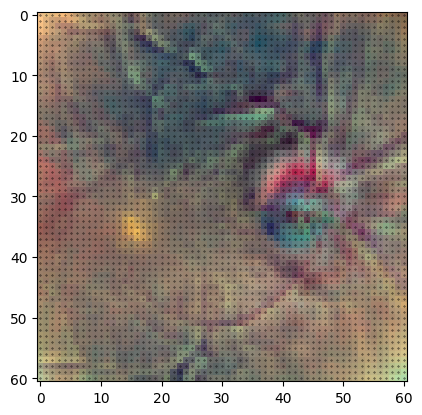

In [ ]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5]
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [ ]:
xy5[:10,:10,:].numel() #NOTE get the number of elements in the tensor

200

In [ ]:
logs=logging.getLogger(__name__)
n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module): # unravel the functioning of the net
    
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind), device=device)] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            logs.info(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [ ]:

if TEST_FOR['DRMINE']:  
      
    homography_net = HomographyNet()

    Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
    x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
    ind =ind5
    mine_net = MINE_INSIDE(nChannel=3).to(device)
    mi = mine_net(x, ind)
    x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
    x_new.shape

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
import torchinfo
if  TEST_FOR['DRMINE']:
    minet = MINE(nChannel=3).to(device)
    s=3
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = extract_registration_params(pyramid_ref=pyramid_ref, pyramid_test=pyramid_mov, nChannel=nChannel)
    Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
    x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
    ind =ind_lst[s]
    S_summary = torchinfo.summary(minet, input_data=(x, ind))
    print(S_summary)


Layer (type:depth-idx)                   Output Shape              Param #
MINE                                     --                        --
├─Linear: 1-1                            [5904, 100]               700
├─Linear: 1-2                            [5904, 100]               10,100
├─Linear: 1-3                            [5904, 1]                 101
├─Linear: 1-4                            [5904, 100]               (recursive)
├─Linear: 1-5                            [5904, 100]               (recursive)
├─Linear: 1-6                            [5904, 1]                 (recursive)
Total params: 10,901
Trainable params: 10,901
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 128.72
Input size (MB): 1.46
Forward/backward pass size (MB): 18.99
Params size (MB): 0.04
Estimated Total Size (MB): 20.50


tensor([  0.,   0.,   0.,  ..., 485., 485., 485.])

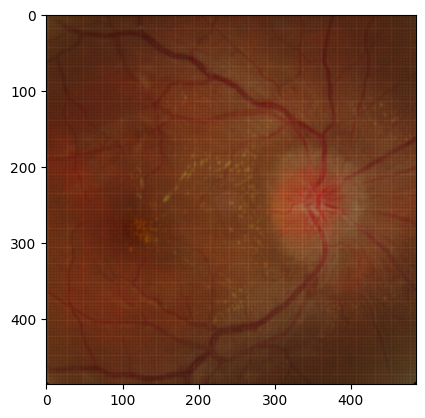

In [ ]:

# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].detach().cpu().numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


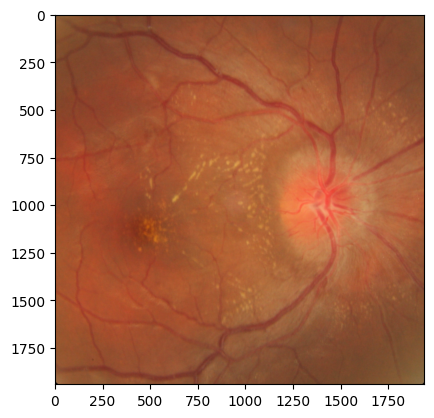

In [ ]:
plt.imshow(I_lst[0].permute(1,2,0).detach().cpu().numpy())

### Apply transformation to original uncropped image

In [ ]:
original_I.shape

(2912, 2912, 3)

In [ ]:
from skimage import io
I_path = FIRE_DATASET_PATH / 'Images' / 'Test' / 'Longitudinal_Studies' / 'A01_2.jpg'
J_path = FIRE_DATASET_PATH / 'Images' / 'Reference' / 'Longitudinal_Studies' / 'A01_1.jpg'

original_I = io.imread(I_path).astype(np.float32) # ref image
original_J = io.imread(J_path).astype(np.float32) # test image
height, width, nchannel = original_I.shape
I = original_I[int(1.5*height/9):int(7.5*height/9),int(1.5*width/9):int(7.5*width/9)]
J = original_J[int(1.5*height/9):int(7.5*height/9),int(1.5*width/9):int(7.5*width/9)]
I_t = torch.tensor(I).to(device) # without Gaussian
J_t = torch.tensor(J).to(device) # without Gaussian
H = homography_net(0)
if nChannel>1:
    J_w = AffineTransform(J_t.permute(2,0,1).unsqueeze(0), H, xy_lst[0][:,:,0], xy_lst[0][:,:,1]).squeeze().permute(1,2,0)
else:
    J_w = AffineTransform(J_t.unsqueeze(0).unsqueeze(0), H , xy_lst[0][:,:,0], xy_lst[0][:,:,1]).squeeze()

Text(0.5, 1.0, 'Difference image after registration')

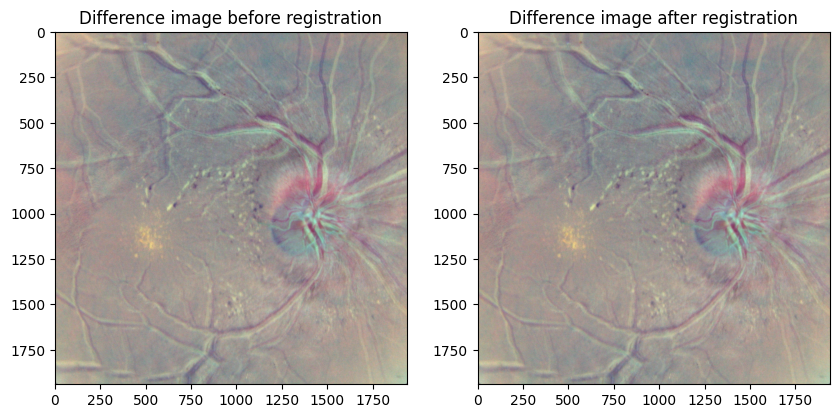

In [ ]:
D = J_t - I_t
D_w = J_w - I_t
D = (D - torch.min(D))/(torch.max(D) - torch.min(D))
D_w = (D_w - torch.min(D_w))/(torch.max(D_w) - torch.min(D_w))
%matplotlib inline
fig=plt.figure(figsize=(10,10))
fig.add_subplot(1,2,1)
plt.imshow(D.cpu().data)
plt.title("Difference image before registration")
fig.add_subplot(1,2,2)
plt.imshow(D_w.cpu().data)         
plt.title("Difference image after registration")

In [ ]:
normalized_affine_matrix = H.detach().cpu().numpy()

h = I.shape[0]
w = J.shape[1]

test_transform = [[2/w, 0, -1],[0, 2/h, -1], [0,0,1]] # a trasformation map to pass from normalized coordinates to pixel coordinates ([-1,1] to [w, h], since we used a 3x3 it will be [w, h ,1])
unnormalized_affine_matrix = np.linalg.inv(np.matmul(np.matmul(np.linalg.inv(test_transform), normalized_affine_matrix), 
                                                     test_transform)) # to adapt the H matrix to pixel coords unnormalized

tx = -int(1.5*original_I.shape[0]/9)
ty = -int(1.5*original_I.shape[0]/9)
move_origin = np.array([[1,0,tx],[0,1,ty],[0,0,1]])

matrix_for_full_image = np.matmul(np.matmul(np.linalg.inv(move_origin), unnormalized_affine_matrix), move_origin)

In [ ]:
rows,cols,ch = original_J.shape
dst = cv2.warpAffine(original_J, matrix_for_full_image[:2], (cols,rows))

Text(0.5, 1.0, 'Difference image after registration')

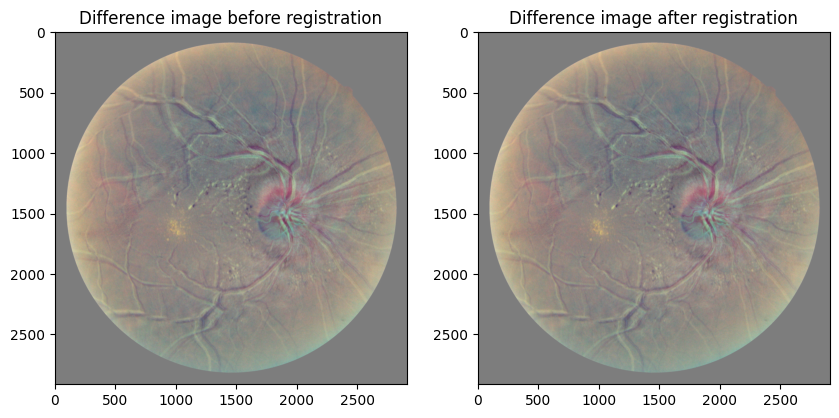

In [ ]:
D = original_J - original_I
D_w = dst - original_I
D = (D - np.min(D))/(np.max(D) - np.min(D))
D_w = (D_w - np.min(D_w))/(np.max(D_w) - np.min(D_w))
%matplotlib inline
fig=plt.figure(figsize=(10,10))
fig.add_subplot(1,2,1)
plt.imshow(D)
plt.title("Difference image before registration")
fig.add_subplot(1,2,2)
plt.imshow(D_w)         
plt.title("Difference image after registration")

In [ ]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [ ]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    logs.debug(f'the {i}-th element has {len(ind_lst[i])} elements')

the 0-th element has 376748 elements
the 1-th element has 94284 elements
the 2-th element has 23619 elements
the 3-th element has 5904 elements
the 4-th element has 1488 elements
the 5-th element has 372 elements


## Functioning


In [33]:
ground_path = CONTROL_POINTS_FOLDER
control_points = [n for n in list(ground_path.glob('*')) if n.name.__contains__('A01')]
control_points, PROJECT_PATH

([WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Ground Truth/control_points_A01_1_2.txt')],
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE'))

In [173]:
config_dict= default_notebook_config_dict()
for k, v in config_dict.items():
    print(f'key {k} ->  value/-s {v}')
    if k == 'constant':
        print('the dict used is the red by yaml file')
        break




key registrations ->  value/-s {'DRMINE_original': {'n_iterations': 500, 'histo_bins': 64, 'min_delta': inf, 'n_neurons': 100, 'early_stopping_criteria': '', 'crop_style': '', 'pyramid_levels': 6, 'sampling_ratio': 0.1, 'lr': {'mine': 0.01, 'vL': 0.001, 'v1': 1e-05}, 'pyramid': {'gaussian_downscale': 2, 'gaussian_levels': 6, 'gaussian_sigma': 1}}, 'elastix_original': {'n_iterations': 5, 'histo_bins': 64, 'n_resolution': 4, 'sampling_ratio': 0.5}, 'simpleITK_original': {'MMI': {'histo_bins': 100, 'sampling_ratio': 0.5, 'lr': 1e-05, 'n_iterations': 5, 'convergenceMinimumValue': 1e-09, 'convergenceWindowSize': 200}, 'JHMI': {'histo_bins': 100, 'sampling_ratio': 0.5, 'lr': 0.1, 'n_iterations': 5, 'convergenceMinimumValue': 1e-09, 'convergenceWindowSize': 200}, 'MSE': {'sampling_ratio': 0.5, 'lr': 1e-06, 'n_iterations': 5, 'convergenceMinimumValue': 1e-09, 'convergenceWindowSize': 200}, 'NCC': {'sampling_ratio': 0.5, 'lr': 0.1, 'n_iterations': 5, 'convergenceMinimumValue': 1e-09, 'convergen

In [ ]:
# prendere le coordinate dalla lista dei valori di riferimento

def get_coords(image_name : Union[str, SampleDict], #es A01
               ground_truth_path : Path = CONTROL_POINTS_FOLDER, # in this case: control_points_[Image pair name]_1_2.txt
               )-> tuple[list[list[float]], list[list[float]]]:
    '''
    get the coordinates of control points associate to the image in list of coords format
    the format in the ground truth folder:

        [reference_point_1_x] [reference_point_1_y] [test_point_1_x] [test_point_1_y]

        [reference_point_2_x] [reference_point_2_y] [test_point_2_x] [test_point_2_y]

    it will returns the list of coords for both test(_2) and reference(_1) image in the format test(x,y) ; reference(x,y)
    '''
    if isinstance(image_name, SampleDict):
        name = image_name['sample_name']
        image_name = name
    if not ground_truth_path.exists():
        raise FileNotFoundError(f'directory {ground_truth_path} not found')
    txt_file_path = [n for n in list(ground_truth_path.glob('*')) if n.name.__contains__(image_name)]
    reference_points, test_points = [], []
    with open(txt_file_path[0], 'r') as file:
        lines = file.readlines()
        for line in lines:
            ref_x, ref_y, test_x, test_y = line.split()
            reference_points.append([float(ref_x), float(ref_y)])
            test_points.append([float(test_x), float(test_y)])
    return test_points, reference_points


ground_path = CONTROL_POINTS_FOLDER
test_points, reference_points = get_coords(image_name='A01') # dato che la valutazione è sull'ultimo è questa quella che dovrebbe pesare di più sulla scala delle MI

In [36]:
get_coords(image_name='A01')

([[388.0, 822.0],
  [357.0, 1849.0],
  [1153.0, 2487.0],
  [1843.0, 400.0],
  [2358.0, 2000.0],
  [2556.0, 1198.0],
  [1949.0, 1194.0],
  [670.0, 1192.0],
  [1944.0, 1460.0],
  [1328.0, 1784.0]],
 [[332.0, 872.0],
  [370.0, 1897.0],
  [1212.0, 2483.0],
  [1761.0, 348.0],
  [2384.0, 1912.0],
  [2527.0, 1099.0],
  [1922.0, 1131.0],
  [642.0, 1222.0],
  [1930.0, 1408.0],
  [1339.0, 1768.0]])

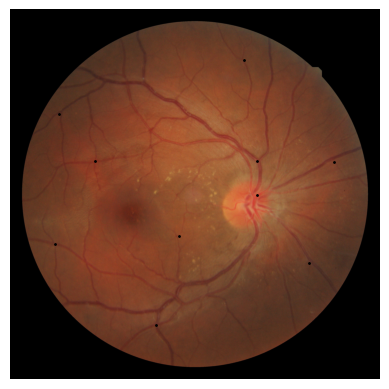

In [37]:
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]
ref_to_open = np.asarray(img_ref.squeeze().permute(1,2,0))
plt.scatter(x_test, y_test, c='black', s=1)
plt.axis('off')
plt.imshow(ref_to_open)

(<matplotlib.image.AxesImage at 0x202038a4830>,
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(100, 100)))

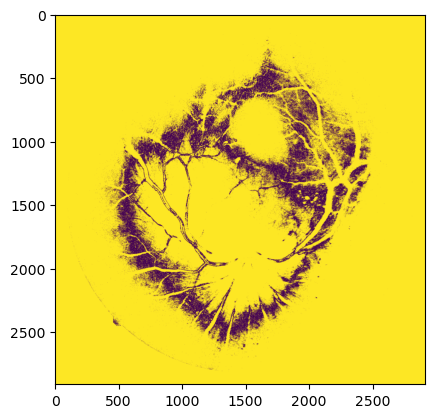

In [122]:
from typing import Any

def get_tensor(input: Any,
               )->torch.Tensor:
    '''
    Generate a Tensor from a general input, if the input type is not handled yet it ha to be write down

    Args:
        input (Any): General input whose tensor is in need

    Returns:
        torch.Tensor: corresponding tensor of input data
    '''
    logs = logging.getLogger(__name__)
    if hasattr(input, 'image'):
        return torch.Tensor(input.image)
    if isinstance(input, np.ndarray):
        return torch.from_numpy(input.astype(np.float32))
    elif isinstance(input, torch.Tensor):
        return input
    else:
        logs.warning(f'the data type {type(input)} is yet to be handled, introduce a new block to us it correctly')
        raise TypeError(f'Unsupported Type{ type(input)}')
    

def get_mask_from_image_intensity(img : Any,
                                low_bound: float=-torch.inf,
                                high_bound:float= torch.inf,
                                inclusive_bound: bool = False,
                                reversed_interval: bool = False,

                                )->torch.Tensor:
    '''
    Generate a Image Mask from image

    Args:
        img (Any): image input data from which get thte mask
        low_bound (float, optional): The lower bound to mark the pixel intensity as True. Defaults to -np.inf.
        high_bound (float, optional): The higher bound to mark the pixel intensity as True. Defaults to np.inf.
        inclusive (bool, optional): Flag to define if the boundary value has to be considered as a part of the bounding. Defaults to False.
        reversed_interval (bool, optional): Flag to define if the masked True values must be the inside of the interval or the outside one
    Returns:
        torch.Tensor: the mask of the corresponding image, using the parameter given
    '''
    logs=logging.getLogger(__name__)
    input_tensor = get_tensor(input=img)
    if inclusive_bound:
        mask = (input_tensor >= low_bound) & (input_tensor <= high_bound)
        if reversed_interval:
            mask = (input_tensor <= low_bound) | (input_tensor >= high_bound)
        
    else:
        mask = (input_tensor > low_bound) & (input_tensor < high_bound)
        if reversed_interval:
            mask = (input_tensor < low_bound) | (input_tensor > high_bound)
        
    if (low_bound == -torch.inf) and ( high_bound==torch.inf):
        logs.info('the image mask correspond to the original image, since all values are included in -np.inf and np.inf')
        return input_tensor
    else:
        return mask
    

_,_, test_image_path, reference_image_path = dataset[0]
test_airlab_image = airlab_read_image(image=Path(test_image_path), config_dict=config_dict)
tensor_from_airlab_image = get_tensor(test_airlab_image)
masked_tensor = get_mask_from_image_intensity(img=tensor_from_airlab_image, low_bound=80, high_bound=90, inclusive_bound=True, reversed_interval=True)
plt.imshow(masked_tensor.squeeze().detach().cpu().numpy()), masked_tensor.squeeze().detach().cpu().numpy()[:100, :100]


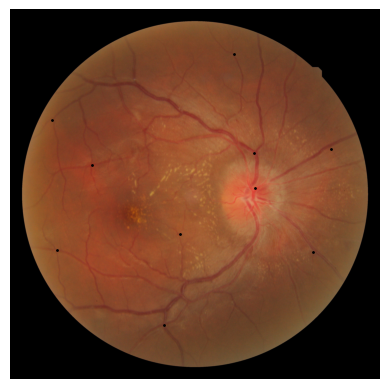

In [123]:
x_ref = [reference_point[0] for reference_point in reference_points]
y_ref = [reference_point[1] for reference_point in reference_points]
test_to_open = np.asarray(img_test.squeeze().permute(1,2,0))
plt.scatter(x_ref, y_ref, c='black', s=1)
plt.axis('off')
plt.imshow(test_to_open)

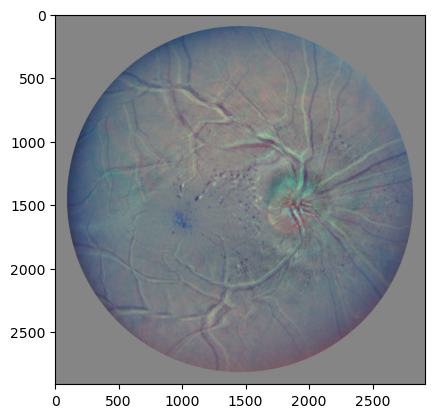

In [124]:
im_ref = normalize(img_ref.squeeze().permute(1,2,0))
im_test = normalize(img_test.squeeze().permute(1,2,0))
im = normalize(im_ref - im_test)
plt.imshow(im)


In [125]:
TEST_FOR['DRMINE']

False

In [126]:
if TEST_FOR['DRMINE']:   
     
    s = 0
    Is = normalize(I_lst[s])
    Js = normalize(J_lst[s])

    ys = y_[s]
    xys = xy_lst[s].detach().cpu().numpy()
    inds = ind_lst[s]
    hs = h_lst[s]
    ws = w_lst[s]
    xs, ys = torch.meshgrid([torch.arange(0,hs).float(), torch.arange(0,ws).float()], indexing='ij')
    xys = torch.stack([xs,ys],2)

    x_coords = xys[..., 0].flatten()
    y_coords = xys[..., 1].flatten()
    x_test = [test_point[0] for test_point in test_points]
    y_test = [test_point[1] for test_point in test_points]

    diffs = (Is - Js)
    diffs_norm = normalize(diffs)
    # creare una funzione per visualizzare i punti di riferimento e le corrispondenze tra i punti di riferimento e le immagini
def show_image_and_reference_points(s: int, 
                                    coordinates: list[list[float]],
                                    image: torch.Tensor,
                                    title : str = get_data_time(),
                                    uniform_color : bool = True,
                                    ):
    """
    TO BE COMPLETED
    ---------------
    
    Args:
        s (int): _description_
        coordinates (list[list[float]]): _description_
        title (str, optional): _description_. Defaults to get_data_time().
        uniform_color (bool, optional): _description_. Defaults to True.
        image (torch.Tensor, optional): _description_. Defaults to Is.
    """
    
    x_test = [test_point[0] for test_point in coordinates]
    y_test = [test_point[1] for test_point in coordinates]
    result_image_folder = RESULT_PATH /'ImgRes'
    plt.imshow(image.permute(1,2,0).detach().cpu().numpy())
    plt.axis('off')
    if not uniform_color:
        colors = plt.cm.jet(np.linspace(0, 1, len(coordinates)))
    else: 
        colors = ['black'] * len(coordinates)
    '''for i, (x, y) in enumerate(coordinates):
        plt.scatter(x, y, c=colors[i], s=1)'''
    plt.scatter(x_test, y_test, c=colors, s=1)
    plt.savefig(result_image_folder / f'{title}.png')
    

if TEST_FOR['DRMINE']:   
    show_image_and_reference_points(s=0, coordinates=test_points), show_image_and_reference_points(s=0, coordinates=test_points, title='Is_and_test_points')


In [127]:
#non tutti i punti sono papabili, pertanto bisogna tolgiere quelli che sono out of the box: (1.5/9. - 7.5/9) * shape image
xshape, yshape = ORIGINAL_SHAPE
test_points, reference_points
def remove_coord_outside_box(coords : list[list[float]],
                            original_shape : tuple[int] = ORIGINAL_SHAPE,
                            upper_edge: float = 7.5/9.,
                            lower_edge: float = 1.5/9.,
                            )-> list[list[float]]:
    '''
    remove the coordinates that are outside the box of the cropped image
    '''
    logs=logging.getLogger(__name__)
    xshape, yshape = original_shape
    print(f'xshape: {xshape}, yshape: {yshape}')
    modified_coords = []
    xlimit, ylimit = int(xshape*upper_edge), int(yshape*upper_edge)
    xbase, ybase = int(xshape*lower_edge), int(yshape*lower_edge)
    
    for coord in coords:
        x_coord , y_coord = coord
        if x_coord not in range(xbase, xlimit +1):
            logs.info(f'since {x_coord} is outside the box, {x_coord, y_coord} will be removed') # logging
            continue
        elif y_coord not in range(ybase, ylimit +1):
            logs.info(f'since {y_coord} is outside the box, {x_coord, y_coord} will be removed') #logging
            continue
        else:
            x_coord -= xbase
            y_coord -= ybase
            logs.info(f'the new coord are {x_coord}, {y_coord}')#logging
            coord = (x_coord, y_coord)
            modified_coords.append(coord)

    return modified_coords


# if just one of the value in the coords is outside the box of the image, it should be removed
# then remove from both x and y coords the min value of  1.5/9.*shape[0] to reassest the coords in the visualization
# remember to pack two tuple of coords in the list to get the evaluation, just after the crop and before it.

In [128]:
cropped_test_points = remove_coord_outside_box(test_points)
cropped_reference_points = remove_coord_outside_box(reference_points)
if TEST_FOR['DRMINE']:
    show_image_and_reference_points(s=0, coordinates=cropped_test_points, image=Js, title='Js_and_cropped_test_points')

[INFO] __main__ - since 388.0 is outside the box, (388.0, 822.0) will be removed
[INFO] __main__ - since 357.0 is outside the box, (357.0, 1849.0) will be removed
[INFO] __main__ - since 2487.0 is outside the box, (1153.0, 2487.0) will be removed
[INFO] __main__ - since 400.0 is outside the box, (1843.0, 400.0) will be removed
[INFO] __main__ - the new coord are 1873.0, 1515.0
[INFO] __main__ - since 2556.0 is outside the box, (2556.0, 1198.0) will be removed
[INFO] __main__ - the new coord are 1464.0, 709.0
[INFO] __main__ - the new coord are 185.0, 707.0
[INFO] __main__ - the new coord are 1459.0, 975.0
[INFO] __main__ - the new coord are 843.0, 1299.0
[INFO] __main__ - since 332.0 is outside the box, (332.0, 872.0) will be removed
[INFO] __main__ - since 370.0 is outside the box, (370.0, 1897.0) will be removed
[INFO] __main__ - since 2483.0 is outside the box, (1212.0, 2483.0) will be removed
[INFO] __main__ - since 348.0 is outside the box, (1761.0, 348.0) will be removed
[INFO] _

xshape: 2912, yshape: 2912
xshape: 2912, yshape: 2912


In [129]:
if TEST_FOR['DRMINE']:
    show_image_and_reference_points(s=0, coordinates=cropped_reference_points, title='Is_and_reference_points') # Is and reference points

In [130]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze()
    return J # it's torch.Tensor type
xv = torch.Tensor([x[0] for x in cropped_test_points])
yv = torch.Tensor([x[1] for x in cropped_test_points])
homography_net = HomographyNet()
homo_matrix = homography_net(0)


NameError: name 'HomographyNet' is not defined

In [131]:
loss_vals = []
for s in np.arange(5, -1, -1):
    Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
    logs.debug(f'Jw_ shape is {Jw_.shape}')
    loss_val = torch.cat([I_lst[s], Jw_], 0)
    loss_vals.append(loss_val)

NameError: name 'J_lst' is not defined

In [132]:
def get_warped_coords(test_coords:torch.Tensor |np.ndarray, 
                      affine_matrix,
                      )->tuple[list[int, int]]:
    
    '''Get the warped coordinates applying the homography matrix to the test coordinates
    Parameters:
    test_coords : torch.Tensor | np.ndarray
        the coordinates to be transformed, shape (N, 2)
    affine_matrix 
        the homography matrix, shape (3, 3)
        
    Returns:
    tuple[list[int, int]]
        the transformed coordinates as list of integer tuples'''
    ones = torch.ones(test_coords.shape[0], 1)
    #print(f'ones is : \n{ones}  of shape {ones.shape}\n\n')
    homogeneous_points = torch.cat([test_coords, ones], dim=1)
    #print(f'homogeneous_points is : \n{homogeneous_points} of shape {homogeneous_points.shape}\n\n')
    # Apply homography
    transformed_points = torch.matmul(homogeneous_points, affine_matrix.T)
    #print(f'affine matrix is : \n{affine_matrix} of shape \t{affine_matrix.shape}\n\n')
    #print(f'transformed_points are : \n{transformed_points} of shape \t{transformed_points.shape}\n\n')
    # Convert back to Cartesian coordinates
    transformed_points = transformed_points[:, :2] / transformed_points[:, 2].unsqueeze(1)
    transformed_points_int_list = [[int(round(x)), int(round(y))] for x, y in transformed_points.tolist()]
    
    return transformed_points_int_list

# Esempio di utilizzo
test_coords =cropped_reference_points
homo_matrix = torch.eye(3)
transformed_points = get_warped_coords(torch.Tensor(test_coords), homo_matrix)
transformed_points,cropped_reference_points # verificato che siano uguali

([[1899, 1427], [1437, 646], [157, 737], [1445, 923], [854, 1283]],
 [(1899.0, 1427.0),
  (1437.0, 646.0),
  (157.0, 737.0),
  (1445.0, 923.0),
  (854.0, 1283.0)])

In [133]:
from typing import Optional
# creare una funzione per la loss e valutarla in merito a tali punti
def loss_reference_points(reference_list : list[[int, int]], # for I image
                          homography_matrix : torch.Tensor,
                          test_list : list[[int, int]], # for J image
                          ) -> float :
    ''' given two list of coordinates, it get the euclidean distance between these two:
    calculated as the difference between the test point and the affine transformation of the coordinate through the homography tensor
    Args:
        reference_list (list[[int, int]]): list of coordinate points of the image of reference
        test_list (list[[int, int]]): list of coordinate points of the image to test the homography on
        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss 
    '''
    if len(reference_list) != len(test_list):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.0
        test_coords = get_warped_coords(torch.Tensor(test_list), homography_matrix)
        for i in range(len(reference_list)):
            x_ref, y_ref = reference_list[i]
            x_test, y_test = test_coords[i]
            loss += np.sqrt((x_ref - x_test)**2 + (y_ref - y_test)**2)
        return loss

# creare una funzione per la loss e valutarla in merito al valore in tali punti
def loss_value_points(reference_points : list[[int, int]],  # for the  I image
                          test_points : list[[int, int]], # for the J image
                          reference_image : torch.Tensor, # for the I image
                          warped_image : torch.Tensor, # for the Jimage
                          homography_matrix : torch.Tensor,
                          ) -> float :
    ''' 
    given two list of coordinates(reference_points), 
    it get the differences in values between the test image and the warped one in these coordinates

    Assume that all the images both the fixed and the warped one are both of same shape and resulted from the dataloader,
    ready to be processed by the net of shape [3, N ,N] or [N ,N]

    Args:
        reference_points (list[[int, int]]): list of coordinate points of the image of reference I

        test_points (list[[int, int]]): list of coordinate points of the image to test the homography on J

        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss H

        reference_image the image of reference I

        warped_image the image to be tested J
    '''
    if len(reference_points) != len(test_points):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.
        test_coords = get_warped_coords(torch.Tensor(test_points), homography_matrix)

        for i in range(len(reference_points)):
            x_ref, y_ref = reference_points[i] 
            x_test, y_test = test_coords[i]
            if np.min(reference_image.shape) == 3: # nChannel==3
                reference_value = torch.sum(reference_image[:, x_ref, y_ref]).item()
                warped_value = torch.sum(warped_image[:, x_test, y_test]).item()

            else:
                reference_value = reference_image[x_ref, y_ref].item()
                warped_value = warped_image[x_test, y_test].item()
            loss += np.abs(reference_value - warped_value)
        return loss

def loss_value_images(I : torch.Tensor,
                      J : torch.Tensor,
                      shape_independece : bool = True,
                      )-> float:
    ''' get the loss value between two images'''
    if I.shape != J.shape:
        raise ValueError("the two images must have the same shape")
    else:
        if np.min(I.shape) == 1:
            I = I.squeeze()
            J = J.squeeze()
        I_norm = normalize(I)
        J_norm = normalize(J)
        if shape_independece:
            shape_normalizator = I.shape[0] * I.shape[1]
            return torch.abs(I_norm - J_norm).sum()/shape_normalizator
        else:
            return torch.abs(I_norm - J_norm).sum()

def mse_loss(img_fixed: np.ndarray | torch.Tensor,
             img_moving: np.ndarray |torch.Tensor,
             )-> float:
    ''' get the mean squared error loss between two images
    
    Parameter:
    img_fixed (np.ndarray | torch.Tensor): the fixed image
    img_moving (np.ndarray | torch.Tensor): the moving image
    
    Returns:
    float: the mean squared error loss between the two images, normalized over their size
    '''

    if img_fixed.shape != img_moving.shape:
        raise ValueError("the two images must have the same shape")
    if type(img_fixed) != type(img_moving):
        raise TypeError("the two images must have the same type")
    elif isinstance(img_fixed, torch.Tensor):
        img_fixed = img_fixed.squeeze().permute(1,2,0).numpy()
        img_moving = img_moving.squeeze().permute(1,2,0).numpy()


    return np.sum((img_fixed - img_moving)**2)/img_fixed.size

def mutual_information_loss(fixed_image: np.ndarray | torch.Tensor,
                            warped_image : np.ndarray | torch.Tensor,
                            index_list: torch.Tensor,
                            mine_net : Optional[MINE] = None,
)-> float :
    '''
    the loss calculate through the mutual information between the two pyramids
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        the fixed image as reference or ground truth
    warped_image : np.ndarray | torch.Tensor
        the warped image as the input
    index_list : list[torch.Tensor]
        the index list to be used to calculate the mutual informationLoss 
    mien_net : MINE 
        the MINE network to be used to calculate the mutual informationLoss
    '''
    mi_loss = 0.0
    if fixed_image.shape != warped_image.shape:
        raise ValueError("the two images must have the same shape")
    if type(fixed_image) != type(warped_image):
        raise TypeError("the two images must have the same type")
    elif isinstance(fixed_image, np.ndarray):
        fixed_image = torch.from_numpy(fixed_image)
        warped_image = torch.from_numpy(warped_image)
    if fixed_image.ndim == 2:
        mi_loss = mine_net(torch.stack([fixed_image, warped_image], 2), index_list)
    else:
        mi_loss = mine_net(torch.cat([fixed_image, warped_image], 0).permute(1,2,0), index_list)
    return mi_loss      

def pyramid_mi_loss(fixed_pyramid : list[torch.Tensor],
                    warped_pyramid : list[torch.Tensor],
                    index_list :list,
                    mine_net : MINE,
                    ) -> float :
    '''
    the function perform the mutual loss calculation over the pyramid of images

    Parameters :
        fixed_pyramid : list of different resolution images for references

        warped_pyramid : list of different resolution images for warped images

        index_list : list of indices for the homography transformation, indicate the coordinates of points in image pairs

        mine_net the network to calculate the mi_loss 

    Returns :
        the mutual information loss between the two pyramids of images
            '''     
    if len(fixed_pyramid) != len(warped_pyramid) != len(index_list):
        raise ValueError("the two pyramids and the index list must have the same length ")   
    mi_loss = 0.0
    L = len(fixed_pyramid)
    for s in np.arange(L-1, -1, -1):
        mi_loss -= mutual_information_loss(fixed_image=fixed_pyramid[s], warped_image=warped_pyramid[s], index_list=index_list[s], mine_net=mine_net)/L

    return mi_loss

NameError: name 'MINE' is not defined

#### Gli altri metodi di valutazione per le singole immagini, da usare in due varianti:
    1. per le immagini B/N
    2. per le immagini colorate



In [134]:
import SimpleITK as sitk
import torch
if not IN_COLAB: 
    # MMI MATTES MUTUAL INFORMATION - usa la PARZEN WINDOW dai metodi di SimpleITK
    def mattes_mutual_information(image1: np.ndarray | torch.Tensor, # consider the images as bn or monochanneled
                                image2: np.ndarray | torch.Tensor,
                                num_bins : int = 100,
                                parzen_kernel : float = 1.0,
    )-> float:
        '''
        la funzione calcola a partire da due immagini in formato numpy o tensore la mutual information nella definizione di Mattes
        ci si serve della finestra di parzen per l'approssimazione a una distribuzione continua, al fine di ottenere un risultato meno influenzato
        dalla distribuzione discreta dei pixels

        PARAMETERS
            - image1 & image2: the reference and warped image
            - num_bins: num of bins to consider to obtain the histogram
            - parzen_kernel: the kernel size to get the continuous approximation of histogram values

        RETURN
            - MMI: a float as mattes' mutual information
        '''
        pass

        # PARZEN windowing - usa la finestra di Parzen per ridurre l'effetto di quantizzazione sull'istogramma, dai metodi di SimpleITK ...
        # convert the image type from numpy to torch.Tensor if necessary
        if isinstance(image1, np.ndarray):
            image1 = torch.from_numpy(image1)
        if isinstance(image2, np.ndarray):
            image2 = torch.from_numpy(image2)
        if image1.shape != image2.shape:
            raise ValueError("The two images must have the same shape")
        
        image1 = image1.view(-1)  # flatten the image
        image2 = image2.view(-1)  # flatten the image
        #normalization
        image1 = (image1 - image1.min()) / (image1.max() - image1.min())
        image2 = (image2 - image2.min()) / (image2.max() - image2.min())

        # create binning centers
        bin_centers = torch.linspace(0, 1, num_bins) #NOTE inseguito se usi device usa device = image1.device
        
        def parzen_windowing(z):
            '''
            define the approssimation using a gaussian kernel
            '''
            return  torch.exp(-0.5 * ((z[:, None] - bin_centers[None, :]) / parzen_kernel)**2)
        
        px=parzen_windowing(image1)
        py=parzen_windowing(image2)

        # calculate margianl and joint probabilities
        pxy = torch.mm(px.T, py)  # joint histogram
        pxy /= pxy.sum()  # normalize to get probabilities

        px_marginal = px.sum(dim=0)/px.shape[0]  # marginal for image1
        py_marginal = py.sum(dim=0)/py.shape[0]  # marginal for image2
        px_py = px_marginal[:, None] * py_marginal[None, :]  # outer product for joint marginal probabilities

        nzs = pxy > 0  # non-zero elements
        # calculate mutual information
        mmi = torch.sum(pxy[nzs] * torch.log(pxy[nzs] / px_py[nzs]))  # mutual information
        return mmi.item()  # return as float




    # Joint hinstogram mutual information, usa un istogramma per appiattire e calcolare le immagini similmente alla NMI, dai metodi di SimpleITK?
    def histogram_mutual_information(image1, image2):
        hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
        pxy = hgram / float(np.sum(hgram))
        px = np.sum(pxy, axis=1)
        py = np.sum(pxy, axis=0)
        px_py = px[:, None] * py[None, :]
        nzs = pxy > 0
        return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    def JHMI_itk(fixed_image: np.ndarray | torch.Tensor,):
        pass


    # Normalized cross correlation, usa la correlazione incrociata normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
    def nccITK(fixed_image: np.ndarray | torch.Tensor,
            warped_image: np.ndarray | torch.Tensor,
            )-> float:
        '''
        Normalized Cross Correlation (NCC) between two images.
        
        Parameters
        ----------
        fixed_image : np.ndarray | torch.Tensor
            The fixed image.
        warped_image : np.ndarray | torch.Tensor
            The warped image.
        
        Returns
        -------
        float
            The normalized cross correlation value.
        '''
        if fixed_image.shape != warped_image.shape:
            raise ValueError("The two images must have the same shape")
        
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.detach().cpu().numpy()
        if isinstance(warped_image, torch.Tensor):
            warped_image = warped_image.detach().cpu().numpy()

        fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
        warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
        
        ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
        ncc_map = ncc_filter.Execute(fixed_sitk, warped_sitk)

        stats = sitk.StatisticsImageFilter()
        stats.Execute(ncc_map)
        return stats.GetMaximum()  # Return the maximum NCC value

    # Mean Squared Error, usa la differenza quadratica media per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
    def mse_sitk(fixed_image: np.ndarray | torch.Tensor,
                        warped_image: np.ndarray | torch.Tensor,
                        )-> float:
        '''
        Mean Squared Error (MSE) between two images.
        
        Parameters
        ----------
        fixed_image : np.ndarray | torch.Tensor
            The fixed image.
        warped_image : np.ndarray | torch.Tensor
            The warped image.
        
        Returns
        -------
        float
            The mean squared error value.
        '''
        if fixed_image.shape != warped_image.shape:
            raise ValueError("The two images must have the same shape")
        
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.detach().cpu().numpy()
        if isinstance(warped_image, torch.Tensor):
            warped_image = warped_image.detach().cpu().numpy()

        fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
        warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
        
        mse_filter = sitk.MeanSquaresImageFilter()
        mse_value = mse_filter.Execute(fixed_sitk, warped_sitk)

        return mse_value  # Return the MSE value

    # Airlab mutual infromation usa la mutual information per calcolare la similarità tra le immagini, dai metodi di AirLab


    #  Normalized Mutual Information, usa la mutual information normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleElastix ...



# Registration Methods
for AIRLAB exclude the previous registration methods to keep it light the RAM of COLAB

In [135]:
test_images_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['FIRE_TEST_FOLDER']))
reference_images_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['FIRE_REFERENCE_FOLDER']))


In [136]:
dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
sample = next(iter(dataloader))
sample_test_image, sample_reference_image, sample_test_image_path, sample_reference_image_path = sample
A01_test = Path(sample_test_image_path[0])
A01_reference = Path(sample_reference_image_path[0])


In [39]:
import SimpleITK as sitk
def tensor_img_to_sitk(img : torch.Tensor | np.ndarray
                       )-> sitk.Image:
    '''
    convert a torch tensor image to a SimpleITK image
    '''
    if isinstance(img, torch.Tensor):
        img = img.squeeze().detach().cpu().numpy()
    if img.ndim == 2: # single channel image
        img = img 
    if img.ndim == 3 and img.shape[0] == 3: # multi-channel image
       img = np.transpose(img, (1, 2, 0)) # change to (H, W, C) format
       rgb_to_gray_sensitivity = [0.2898, 0.5870, 0.1140] # RGB to gray sensitivity
       img = np.dot(img, rgb_to_gray_sensitivity) # convert to grayscale
    return sitk.GetImageFromArray(img.astype(np.float32)) # convert to SimpleITK image

In [41]:
#img_ref_sitk = tensor_img_to_sitk(img_ref)
hasattr(sitk, 'GetArrayFromImage')

True

In [139]:
def tensor_img_rgb2bn(imgrgb: torch.Tensor | np.ndarray,
                      normalization_type: str = 'same' or  'humansensitivity'
                      )->torch.Tensor:
    '''
    convert a RGB torch tensor image to a grayscale torch tensor image
    imgrgb in format (C, H, W) or  (B, C, H, W)
    normalization_type: 'same' to keep the same width for each channel
                        'humansensitivity' to use the human sensitivity ot each color channel: R: 0.2989, G: 0.5870, B: 0.1140
    '''
    if isinstance(imgrgb, np.ndarray):
        imgrgb = torch.from_numpy(imgrgb)
    img_rgb = imgrgb.squeeze().detach().cpu()
    if img_rgb.ndim == 2: # single channel image
        return img_rgb
    elif img_rgb.ndim == 3 and img_rgb.shape[0] == 3: # multi-channel image
        if normalization_type == 'same':
            img_bn = img_rgb.mean(dim=0)
        elif normalization_type == 'humansensitivity':
            rgb_to_gray_sensitivity = torch.tensor([0.2989, 0.5870, 0.1140])
            img_bn = torch.tensordot(img_rgb.permute(1,2,0), rgb_to_gray_sensitivity, dims=1)
        else:
            raise ValueError("normalization_type must be 'same' or 'humansensitivity'")
    else:
        raise ValueError(f'the input shape must be in (C, H, W) or (B, C, H, W), got {imgrgb.shape}')
    return img_bn
    

In [140]:
#raise RuntimeError('stop')

## Metodi SITK per la image registration :


### MAttes mutual information from SITK
TODO to pass the registration function in an object oriented programming

In [141]:
from typing import Any
# MATTEs MUtual INformation: up to date to article parameters
def MMI_SITK(reference_image: sitk.Image,
            test_image: sitk.Image,
            config_dict : Optional[dict] = {},
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    reference_image : np.ndarray | torch.Tensor
        The reference image.
    test_image : np.ndarray | torch.Tensor
        The test image.
    config_dict : dict, optional
        A dictionary containing configuration parameters for the registration process, such as the number of histogram bins,
    
    Returns
    -------
    outTx : sitk.Transform
        The resulting transformation to easly access the trasformation through sitk methods
    registration : sitk.ImageRegistrationMethod
        The registration object containing all the registration parameters and methods
    registration_time_taken : float
        The time taken for the registration process.
    '''
    mmi_sitk_dict = config_dict['registrations']['simpleITK_original']['MMI']
    
    samplingPercentage = float(mmi_sitk_dict['sampling_ratio'])
    histogram_bins = int(mmi_sitk_dict['histo_bins'])
    lr = float(mmi_sitk_dict['lr'])
    n_iterations = float(mmi_sitk_dict['n_iterations'])
    convergence_min_value = float(mmi_sitk_dict['convergenceMinimumValue'])
    convergence_window_size = float(mmi_sitk_dict['convergenceWindowSize'])
    # to get the transformation of the matrix
    with block_time() as mattes_time:
        registration = sitk.ImageRegistrationMethod()
        registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=int(histogram_bins))  
        registration.SetMetricSamplingPercentage(float(samplingPercentage), seed=sitk.sitkWallClock) 
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetOptimizerAsGradientDescent(learningRate=float(lr), numberOfIterations=int(n_iterations), convergenceMinimumValue=float(convergence_min_value), convergenceWindowSize=int(convergence_window_size) )
        registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
        registration.SetInitialTransform(sitk.AffineTransform(reference_image.GetDimension()))  # Initial transform
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

        #registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle

        # to get the transformation of the warped image:
        outTx = registration.Execute(reference_image, test_image)  # Execute the registration
    registration_time_taken = mattes_time[0]
    # get information about the iteration cycle:

    return outTx, registration, registration_time_taken


In [142]:
imagedir_save_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['IMG_RESULTS'])) 

def get_image_confrontation_SITK(image_ref : sitk.Image | torch.Tensor, #FIXME to be adjusted to wrappers, preprocessing, dataset and config_dict
                   image_test : sitk.Image | torch.Tensor,
                   outTx : sitk.Transform,
                   interpolator = sitk.sitkLinear,
                   default_pxv : int = 100,
                   visualize: bool = True,
                   folder_path: Path = imagedir_save_path, 
                   name: str = 'A01_sitk'                  
                   )-> sitk.Image:
    '''
    get the warped image and the fixed image from the SimpleITK images and the transformation matrix
    '''
    if isinstance(image_ref, torch.Tensor):
        image_ref = tensor_img_to_sitk(image_ref)
    if isinstance(image_test, torch.Tensor):
        image_test = tensor_img_to_sitk(image_test)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image_ref)  # Set the reference image
    resampler.SetTransform(outTx)  # Set the transformation
    resampler.SetInterpolator(interpolator)  # Set the interpolator
    resampler.SetDefaultPixelValue(default_pxv)  # Set the default pixel value

    outcome_image = resampler.Execute(image_test)  # Execute the resampling
    sigm1 = sitk.Cast(sitk.RescaleIntensity(outcome_image), sitk.sitkUInt8)
    sigm2 = sitk.Cast(sitk.RescaleIntensity(image_ref), sitk.sitkUInt8)
    image_confrontation = sitk.Compose(sigm1, sigm2, sigm1//2.0 + sigm2//2.0)  # Compose the two images

    if visualize:
        array_image = sitk.GetArrayFromImage(image_confrontation)  # Convert to numpy array for visualization
        if array_image.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
            array_image = np.moveaxis(array_image, 0, -1)
        plt.figure(figsize=(6, 6))
        plt.imshow(array_image)
        plt.axis('off')
        plt.title("Warped and Fixed Image")
        
        if IN_COLAB:
            plt.savefig(folder_path/f'{name}.png', dpi=150, bbox_inches='tight')
            
        else:
            plt.savefig(folder_path / f'{name}.png')
        plt.show()
        plt.close()
    return image_confrontation

In [35]:
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)

if TEST_FOR['SITK']:
    #transformation_mmi_sitk, registration_sitk, mattes_time_taken = MMI_SITK(fixed_image=img_ref, warped_image=img_test)

    
    mmi_sitk_results = sitk_wrapper_for_registration(sample_dict=sample_dictA01,
                                                     config_dict=config_dict,
                                                     sitk_registration_fn=MMI_SITK,)
    
    transformation_mmi_sitk  = mmi_sitk_results['sitk_transformation']
    
    A01_MMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_mmi_sitk,
                                                name='A01_MMI_sitk_drive_trial',
                                                folder_path=imagedir_save_path,
                                                visualize=True)

[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements


Abort ()
AddCommand (*args)
DebugOff ()
DebugOn ()
Execute (fixed, moving)
GetCurrentLevel ()
GetDebug ()
GetFixedInitialTransform ()
GetGlobalDefaultCoordinateTolerance ()
GetGlobalDefaultDebug ()
GetGlobalDefaultDirectionTolerance ()
GetGlobalDefaultNumberOfThreads ()
GetGlobalDefaultThreader ()
GetGlobalWarningDisplay ()
GetInitialTransform ()
GetInitialTransformInPlace ()
GetInterpolator ()
GetMetricNumberOfValidPoints ()
GetMetricSamplingPercentagePerLevel ()
GetMetricValue ()
GetMovingInitialTransform ()
GetName ()
GetNumberOfThreads ()
GetNumberOfWorkUnits ()
GetOptimizerConvergenceValue ()
GetOptimizerIteration ()
GetOptimizerLearningRate ()
GetOptimizerPosition ()
GetOptimizerScales ()
GetOptimizerStopConditionDescription ()
GetOptimizerWeights ()
GetProgress ()
GlobalDefaultDebugOff ()
GlobalDefaultDebugOn ()
GlobalWarningDisplayOff ()
GlobalWarningDisplayOn ()
HasCommand (event)
MetricEvaluate (fixed, moving)
MetricUseFixedImageGradientFilterOff ()
MetricUseFixedImageGradien

In [162]:
obj.GetOptimizerPosition()

()

In [ ]:
from PIL import  Image
if IN_COLAB:
    im_drive = Path(f'{RESULT_PATH}/ImgRes/A01_MMI_sitk_drive_trial.png')
    assert Image.open(im_drive) # NOTE to visualize remove assert


In [119]:
from typing import Union, Protocol, Any, runtime_checkable

@runtime_checkable
class ElastixParameterMap(Protocol):
    def GetParameterMap(self, *args:Any,
                        **kwargs:Any,)->dict:
        ...

def get_affine_matrix_from_sitk_transform(sitk_transform: Union[sitk.AffineTransform,  ElastixParameterMap],
                                          )-> torch.Tensor:
    '''
    get the homogeneous affine matrix from the SimpleITK transform object
    as a torch.Tensor

    H = | M t_eff |
        | c   1   |
        
    where t_eff = t + c - M @ c as effective translation considering the center of rotation
    and M is the rotation matrix, t is the translation vector, c is the center of rotation
    
    Parameters:
    -----------
    
    sitk_transform : sitk.AffineTransform
        the SimpleITK affine transform object from which to extract the homogeneous affine matrix
    
    Returns:
    --------
        H_matrix : torch.Tensor
        the homogeneous affine matrix as a torch.Tensor of shape (dim+1, dim+1
    '''
    if isinstance(sitk_transform, ElastixParameterMap):
        H = np.eye(3)
        a11, a12, a21, a22, tx, ty =  sitk_transform.GetParameterMap(0)['TransformParameters']
        
        H[0, 0] = float(a11)
        H[0, 1] = float(a12)
        H[1, 0] = float(a21)
        H[1, 1] = float(a22)
        H[0, 2] = float(tx)
        H[1, 2] = float(ty)
        return torch.Tensor(H)
    dim = sitk_transform.GetDimension()
    M = np.array(sitk_transform.GetMatrix(), dtype=float).reshape((dim, dim))
    t = np.array(sitk_transform.GetTranslation(), dtype=float)
    c = np.array(sitk_transform.GetCenter(), dtype=float)  

    # compute the effective translation considering the center of rotation
    t_eff = t + c - M @ c
    # construct the homogeneous affine matrix
    H = torch.eye(dim + 1, dtype=torch.float32)
    H[:dim, :dim] = torch.Tensor(M)
    H[:dim, dim] = torch.Tensor(t_eff)


    return H

In [157]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    get_affine_matrix_from_sitk_transform(transformation_mmi_sitk)

In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(img_ref_sitk) # NOTE param
    resampler.SetTransform(transformation_mmi_sitk) # NOTE param
    resampler.SetInterpolator(sitk.sitkLinear)  # Interpolator
    resampler.SetDefaultPixelValue(100)  # Default pixel value for the output image

    out = resampler.Execute(tensor_img_to_sitk(img_test))  #NOTE param
    simg1 = sitk.Cast(sitk.RescaleIntensity(out), sitk.sitkUInt8)  # Rescale the intensity to uint8
    simg2 = sitk.Cast(sitk.RescaleIntensity(img_ref_sitk), sitk.sitkUInt8)  # Rescale the intensity to uint8
    cimg = sitk.Compose(simg1, simg2, simg1//2.0 + simg2//2.0)  # Compose the images
    # if plot_composite_image:
    # plot...
    arr = sitk.GetArrayFromImage(cimg)

    # 2) Riordina i canali in ultima dimensione:
    #    da (bands, H, W) a (H, W, bands)
    if arr.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
        arr = np.moveaxis(arr, 0, -1)

    # 3) Se i tuoi dati non sono già uint8, normalizza/castali:
    # arr = (255.0*(arr - arr.min())/(arr.max()-arr.min())).astype(np.uint8)

    # 4) Mostra con matplotlib
    plt.figure(figsize=(6,6))
    plt.imshow(arr, cmap='gray')
    plt.axis('off')
    plt.title('Composite Image (R,G,B)')
    plt.show()


# return cimg

### NCC from SimpleITK: variation with centered

In [ ]:

#Ncc for sitk:
def centred_NCC_SITK(reference_image: np.ndarray | torch.Tensor | Path,
                     test_image: np.ndarray | torch.Tensor | Path,
                     config_dict:dict,)-> tuple: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    reference_image : np.ndarray | torch.Tensor
        The fixed image.
    test_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    ncc_centred_dict = config_dict['registrations']['simpleITK_original']['NCC_centred']
    
    with block_time() as ncc_time:
        # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()
        registration.SetMetricAsCorrelation()  
        registration.SetOptimizerAsRegularStepGradientDescent(
            learningRate=ncc_centred_dict['lr'],
            minStep=ncc_centred_dict['min_step'],
            numberOfIterations=ncc_centred_dict['n_iterations'],
            gradientMagnitudeTolerance=ncc_centred_dict['gradientMagnitudeTolerance'],
        )
        registration.SetOptimizerScalesFromIndexShift()
        
        transformation = sitk.CenteredTransformInitializer( reference_image, test_image, sitk.AffineTransform(reference_image.GetDimension())) # TRY to use operation_mode = MOMENTS
        registration.SetInitialTransform(transformation)

        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(reference_image, test_image)  # Execute the registration
    time_taken = ncc_time[0]
    

    # get information about the iteration cycle:

    return out_tx, registration, time_taken


In [ ]:

if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    imagedir_save_path = PROJECT_PATH / Path(*config_dict['constant']['path-like']['IMG_RESULTS'])


    A01_NMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_ncc_centred_sitk,
                                                name='A01_ncc_centred_sitk',
                                                folder_path=imagedir_save_path,
                                                visualize=True)
    ncc_centred_sitk_results = sitk_wrapper_for_registration(sample_dict=sample_dictA01
                                                     config_dict=config_dict,
                                                     sitk_registration_fn=centred_NCC_SITK,)
    
    transformation_ncc_centred_sitk  = ncc_centred_sitk_results['affine_matrix']
    
    A01_NCC_centred_sitk = get_image_confrontation_SITK(image_ref=sample_dictA01['reference_sample'],
                                                        image_test=sample_dictA01['test_sample']
                                                        outTx=transformation_ncc_centred_sitk,
                                                        name='A01_NCC_centred_sitk',
                                                        folder_path=imagedir_save_path,
                                                        visualize=True)
                               

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    get_affine_matrix_from_sitk_transform(transformation_ncc_centred_sitk)

### Joint Hinstogram Mutual Information

In [133]:
# MATTEs MUtual INformation:
def JHMI_SITK(reference_image: sitk.Image,
              test_image: sitk.Image,
              config_dict:dict,
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    reference_image : np.ndarray | torch.Tensor
        The reference image.
    test_image : np.ndarray | torch.Tensor
        The test image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''


    # normalization & Gaussian smoothing:
    #reference_image = sitk.DiscreteGaussian(sitk.Normalize(reference_image), 2.0) #removed since not present in the article
    #test_image = sitk.DiscreteGaussian(sitk.Normalize(test_image), 2.0) #removed since not present in the article
    jhmi_sitk_dict= config_dict['registrations']['simpleITK_original']['JHMI']
    samplingPercentage = jhmi_sitk_dict['sampling_ratio']
    lr = jhmi_sitk_dict['lr']
    n_iterations = jhmi_sitk_dict['n_iterations']
    convergence_min_value = jhmi_sitk_dict['convergenceMinimumValue']
    convergence_window_size = jhmi_sitk_dict['convergenceWindowSize']
    histo_bins = jhmi_sitk_dict['histo_bins']
    
    with block_time() as jhmi_time:
    # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()
        registration.SetMetricAsJointHistogramMutualInformation(numberOfHistogramBins=histo_bins)  
        registration.SetOptimizerAsGradientDescent( #NOTE try also with SetOptimzerAsGradientDescent otherwise it will take 16min
            learningRate=lr,
            numberOfIterations=n_iterations,
            convergenceMinimumValue=convergence_min_value,
            convergenceWindowSize=convergence_window_size,
        )
        registration.SetInitialTransform(sitk.AffineTransform(reference_image.GetDimension()))  # Initial transform
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetMetricSamplingPercentage(samplingPercentage)  # 50% sampling
        registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(reference_image, test_image)  # Execute the registration 
    time_taken = jhmi_time[0]  

    return out_tx, registration, time_taken


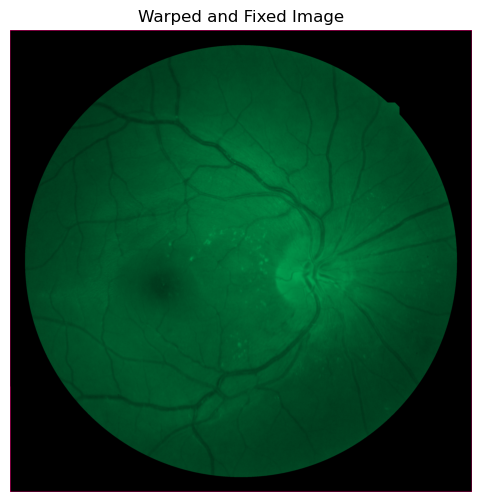

In [134]:
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)
if TEST_FOR['SITK'] or TEST_FOR['elastix']:

    jhmi_sitk_results = sitk_wrapper_for_registration(sample_dict=sample_dictA01,
                                                     config_dict=config_dict,
                                                     sitk_registration_fn=JHMI_SITK,)
    
    transformation_jhmi_sitk  = jhmi_sitk_results['sitk_transformation']
    
    A01_JHMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_jhmi_sitk,
                                                name='A01_JHMI_sitk_drive_trial',
                                                folder_path=imagedir_save_path,
                                                visualize=True)
   

In [139]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    print(jhmi_sitk_results.keys())
    logs.warning('to use sequent methods u ahve to store informaiotn on registration_data too in the resutls')
    #registration_JHMI_sitk.GetMetricValue(), registration_JHMI_sitk.GetOptimizerIteration(), registration_JHMI_sitk.GetOptimizerStopConditionDescription()  

[WARNING] __main__ - to use sequent methods u ahve to store informaiotn on registration_data too in the resutls


dict_keys(['naed_diagonal', 'naed_coords', 'sitk_transformation', 'affine_matrix', 'time_taken'])


### MSE sitk

In [147]:
# Mean Squared Error:
def MSE_SITK( reference_image: sitk.Image,
              test_image: sitk.Image,
              config_dict : dict,
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mean Squared Error (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    mse_sitk_dict = config_dict['registrations']['simpleITK_original']['MSE']
    samplingPercentage = mse_sitk_dict['sampling_ratio']
    lr = mse_sitk_dict['lr']
    n_iterations = mse_sitk_dict['n_iterations']
    convergence_min_value = mse_sitk_dict['convergenceMinimumValue']
    convergence_window_size = mse_sitk_dict['convergenceWindowSize']
    
    with block_time() as mse_time:
        # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()

        registration.SetMetricAsMeanSquares()  
        registration.SetOptimizerAsGradientDescent(
            learningRate = lr,
            numberOfIterations = n_iterations,
            convergenceMinimumValue = convergence_min_value,
            convergenceWindowSize = convergence_window_size,

        )
        registration.SetInitialTransform(sitk.AffineTransform(reference_image.GetDimension()))  # Initial transform
        registration.SetOptimizerScalesFromPhysicalShift()
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetMetricSamplingPercentage(samplingPercentage)  # 50% sampling
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(reference_image, test_image)  # Execute the registration   
    time_taken = mse_time[0]
    return out_tx, registration, time_taken


[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements


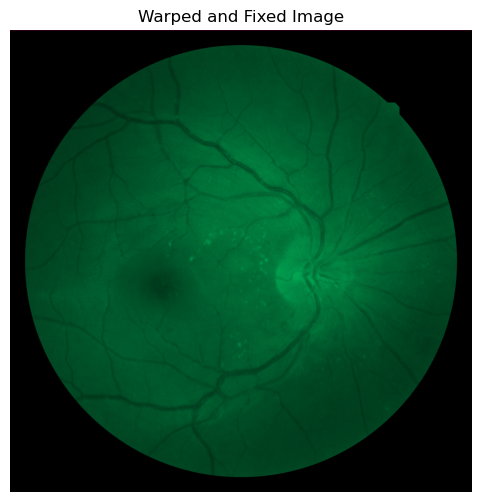

In [148]:
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)
if TEST_FOR['SITK'] or TEST_FOR['elastix']:

    mse_sitk_results = sitk_wrapper_for_registration(sample_dict=sample_dictA01,
                                                     config_dict=config_dict,
                                                     sitk_registration_fn=MSE_SITK,)
    
    transformation_mse_sitk  = mse_sitk_results['sitk_transformation']
    
    A01_MSE_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_mse_sitk,
                                                name='A01_MSE_sitk_drive_trial',
                                                folder_path=imagedir_save_path,
                                                visualize=True)
   

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    if 'registration_data' in mse_sitk_results.keys():
        registration_MSE_sitk = mse_sitk_results['registration_data']
        registration_MSE_sitk.GetMetricValue(), registration_MSE_sitk.GetOptimizerIteration(), registration_MSE_sitk.GetOptimizerStopConditionDescription()  
    else:
        logs.warning('registration_data must be inserted in the wrapper to stored in the results to visualie the methods')

### NCC registration for Sitk

In [ ]:
def NCC_SITK(reference_image: sitk.Image,
             test_image:  sitk.Image,
             config_dict: dict,
           )-> tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Registration of two images using Normalized Cross Correlation (NCC) of SimpleITK as metric.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    ncc_sitk_dict = config_dict['registrations']['simpleITK_original']['NCC']
    samplingPercentage = ncc_sitk_dict['sampling_ratio']
    lr = ncc_sitk_dict['lr']
    n_iterations = ncc_sitk_dict['n_iterations']
    convergence_min_value = ncc_sitk_dict['convergenceMinimumValue']
    convergence_window_size = ncc_sitk_dict['convergenceWindowSize']
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()
    registration.SetMetricAsCorrelation()  # NCC metric
    registration.SetMetricSamplingPercentage(samplingPercentage, seed=sitk.sitkWallClock) # NOTE see if optional or a must
    registration.SetMetricSamplingStrategy(registration.RANDOM) #NOTE not defined in the article
    registration.SetOptimizerAsGradientDescent(learningRate=lr, convergenceMinimumValue=convergence_min_value, convergenceWindowSize=convergence_window_size, numberOfIterations=n_iterations) 
    registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
    registration.SetInitialTransform(sitk.AffineTransform(reference_image.GetDimension()))  # Initial transform
    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

    #    registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle
    with block_time() as ncc_time:
        # to get the transformation of the warped image:
        outTx = registration.Execute(reference_image, test_image)  # Execute the registration
    time_taken = ncc_time[0]
    return outTx, registration, time_taken

[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements


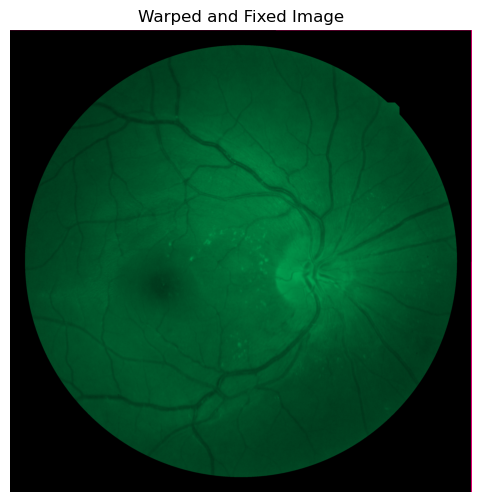

In [156]:
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)
if TEST_FOR['SITK'] or TEST_FOR['elastix']:

    ncc_sitk_results = sitk_wrapper_for_registration(sample_dict=sample_dictA01,
                                                     config_dict=config_dict,
                                                     sitk_registration_fn=NCC_SITK,)
    
    transformation_ncc_sitk  = ncc_sitk_results['sitk_transformation']
    
    A01_NCC_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_ncc_sitk,
                                                name='A01_NCC_sitk_drive_trial',
                                                folder_path=imagedir_save_path,
                                                visualize=True)
   

In [152]:
149.5342238000012*134/3600  # for 0.5 percentage
logs.info(f'for 0.5 percentage expected time around {149.5342238000012*134/3600}h\ninstead for a full sampling(1.0) it would take around {277.47317509999993*134/3600}h')

[INFO] __main__ - for 0.5 percentage expected time around 5.565996108111156h
instead for a full sampling(1.0) it would take around 10.328168184277775h


In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    if 'registration_data' in mse_sitk_results.keys():
        registration_NCC_sitk = NCC_sitk_results['registration_data']
        logs.info(registration_ncc_sitk)
    else:
        logs.warning('registration_data must be inserted in the wrapper to stored in the results to visualie the methods')

### NCC SITK from chatgptm
just some ex, nothing useful inside

In [ ]:
def ncc_sitk_chatgpy(reference_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           test_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           transform : sitk.Transform

           )-> tuple:
    '''
    Normalized Cross Correlation (NCC) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''

        
    ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
    with block_time() as ncc_time:
        ncc_map = ncc_filter.Execute(reference_image, test_image)

        stats = sitk.StatisticsImageFilter()
        stats.Execute(ncc_map)
    time_taken = ncc_time[0]
    return stats.GetMaximum(), ncc_filter,  time_taken  # Return the maximum NCC value

In [ ]:
from skimage.filters import gaussian
from skimage.color import rgb2gray
import numpy as np

def mattes_mutual_information(image1, image2, bins=32):
    """
    Calculate Mattes Mutual Information (MMI) between two images.

    Parameters:
    -----------
    image1 : np.ndarray
        The first image (grayscale or RGB).
    image2 : np.ndarray
        The second image (grayscale or RGB).
    bins : int
        Number of bins for the histogram.

    Returns:
    --------
    float
        The Mattes Mutual Information value.
    """
    # Convert images to grayscale if they are RGB
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Apply Gaussian smoothing
    image1 = gaussian(image1, sigma=1)
    image2 = gaussian(image2, sigma=1)

    # Compute joint histogram
    hist_2d, _, _ = np.histogram2d(image1.ravel(), image2.ravel(), bins=bins)

    # Normalize the histogram
    pxy = hist_2d / float(np.sum(hist_2d))

    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)

    # Compute mutual information
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    mmi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    return mmi

# Example usage
if not IN_COLAB:
    mmi_value = mattes_mutual_information(ref_to_open, test_to_open)
    logs.info(f"Mattes Mutual Information: {mmi_value}")

In [ ]:
# JHMI JOINT HINSTOGRAM MUTUAL INFORMATION usa la parzen window
def joint_histogram_mutual_information(image1, image2):
    # Compute the joint histogram
    hist, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hist / float(np.sum(hist))
    
    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0

    # Compute the joint entropy
    joint_entropy = -np.sum(pxy[nzs] * np.log(pxy[nzs]))
    
    # NOTE suggerito da copilot
    # Compute the marginal entropies 
    hx = -np.sum(px[px > 0] * np.log(px[px > 0]))
    hy = -np.sum(py[py > 0] * np.log(py[py > 0]))
    
    # Compute mutual information
    mi = hx + hy - joint_entropy
    #return mi

    # NOTE dal notebook:
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs])) # this is the original one
    


In [ ]:
# NCC NORMALIZED CROSS CORRELATION: fai un canale alla volta, 
# per le immagini RGB usa la somma ed eventualmente una nuova normalizzazione
#  per avere una versione da -1 +1
def normalized_cross_correlation(
        image1: torch.Tensor | np.ndarray,
        image2: torch.Tensor | np.ndarray
        ) -> float: 
        
    """
    Calculate the normalized cross-correlation (NCC) between two images.

    Parameters:
    -----------
    image1 : np.ndarray | torch.Tensor
        The first image (grayscale or RGB).
    image2 : np.ndarray | torch.Tensor
        The second image (grayscale or RGB).

    Returns:
    --------
    float
        The normalized cross-correlation value.
    """
    if type(image1) != type(image2):
        raise TypeError("the two images must have the same type")
    elif isinstance(image1, torch.Tensor):
        pass
        
    elif isinstance(image1, np.ndarray):
        pass

    # Convert images to grayscale if they are RGB or simply or simply use the sum of the nmi over the color channels ?
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Compute the mean of each image
    mean1 = np.mean(image1)
    mean2 = np.mean(image2)

    # Compute the numerator and denominator for NCC
    numerator = np.sum((image1 - mean1) * (image2 - mean2))
    denominator = np.sqrt(np.sum((image1 - mean1) ** 2) * np.sum((image2 - mean2) ** 2))

    # Avoid division by zero
    if denominator == 0:
        return 0

    ncc = numerator / denominator

    return ncc

True

## Metodo Airlab Mutual Information

In [104]:
import torch
import sys 
import SimpleITK as sitk
from typing import Optional
from airlab.utils.image import Image as AirlabImage
from airlab.registration import PairwiseRegistration
from airlab.transformation.pairwise import AffineTransformation
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from typing import Literal, Tuple
import logging

imagedir_save_path = RESULT_PATH / 'ImgRes'

def airlab_read_image(image: Union[Path, torch.Tensor], config_dict:dict)-> AirlabImage:
    '''
    Read an image producing the airlabImage type

    Args:
        image (Union[Path, torch.Tensor]): input image from dataset in Path or tensor type format
        config_dict (dict): configuration dict from yaml file

    Returns:
        AirlabImage: _description_
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if isinstance(image, Path):
        image_airlab= AirlabImage.read(image, dtype=torch.float32, device=device)
    else: # if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray): # tensor type (1, 1, H, W) or (1, C, H, W)
        ref_image=tensor_img_rgb2bn(image, normalization_type=config_dict['constant']['text-like']['img_normalization'])
        sitk_input = ref_image.cpu() if torch.is_tensor(ref_image) and ref_image.is_cuda else ref_image
        image_airlab = AirlabImage(
            tensor_img_to_sitk(sitk_input),
            torch.float32,
            device)
    return image_airlab


def airlab_mask_from_image(img_airlab:AirlabImage, 
                           low: float=-torch.inf, 
                           high:float=torch.inf,
                           )->AirlabImage:
    '''
    Using the fns for recreate a mask from an input image in the airlab image format

    Args:
        img_airlab (AirlabImage): input image from which the mask is formed
        low (float, optional): Lower bound of mask acceptance interval. Default to -torch.inf
        high (float, optional): Upper bound of mask acceptance interval. Default to torch.inf

    Returns:
        AirlabImage: mask of img_airlab , following the img_airlab input format 
    '''
    logs=logging.getLogger(__name__)

    mask = get_mask_from_image_intensity(
        img=get_tensor(input=img_airlab), 
        low_bound=low, 
        high_bound=high, 
        inclusive_bound=False, 
        reversed_interval=False)



    # crea una nuova AirlabImage preservando info geometriche
    return AirlabImage(tensor_img_to_sitk(torch.Tensor(mask)),device=img_airlab.device, dtype=torch.float32)

def airlab_mask_configuration(reference_image_airlab: AirlabImage,
                test_image_airlab: AirlabImage,
                config_dict: dict,
                
                )->Tuple[AirlabImage, AirlabImage]:
    '''
    Function to create a mask for airlab


    Args:
        reference_image_airlab (AirlabImage): The reference image.
        test_image_airlab (AirlabImage): The test image.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.

    Returns:
        tuple[AirlabImage, AirlabImage]: The masked reference and test images.
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    airlab_config_dict = config_dict['registrations']['airlab']
    min_allowed_val =airlab_config_dict['background_min']
    max_allowed_val = airlab_config_dict['background_max']
    
    reference_mask_airlab = airlab_mask_from_image(reference_image_airlab, low=min_allowed_val, high=max_allowed_val)
    test_mask_airlab = airlab_mask_from_image(test_image_airlab, low=min_allowed_val, high=max_allowed_val)


    reference_image_airlab=reference_mask_airlab.image.to(device)
    test_image_airlab=test_mask_airlab.image.to(device)

    return reference_image_airlab, test_image_airlab




# to be imported tesnor_img_to_sitk, tensor_img_rgb2bn  
def airlab_wrapprer_for_registration(sample_dict:SampleDict,
                                     config_dict:dict,
                                     airlab_registration_fn: Callable[[AirlabImage, AirlabImage, dict], dict],
                                     )-> dict:
    '''
    Wrapper forfor airlab registration loop -type it uniform registration loops to take the same inputs and give out the results 
    as a dict to be easily put in Data Collector

    Args:
        sample_dict (SampleDict): Dictionary containing main information about samples
        config_dict (_type_): configuration dictionary containing all the parameters for the registration
        airlab_registration_fn (_type_): registration function following specs of airlab

    Returns:
        dict: registration results of airlab_registration_fn
    '''
    airlab_config_dict = config_dict['registrations']['airlab']
    #===========READ IMAGES============
    if 'reference_sample_path' in sample_dict:
        airlab_reference_image = airlab_read_image(sample_dict['reference_sample_path'])
    elif 'reference_sample' in sample_dict:
        airlab_reference_image = airlab_read_image(sample_dict['reference_sample'])

    if 'test_sample_path' in sample_dict:
        airlab_test_image = airlab_read_image(sample_dict['test_sample_path'])
    elif 'test_sample' in sample_dict:
        airlab_test_image = airlab_read_image(sample_dict['test_sample'])
    
    if airlab_config_dict['masked']:

        airlab_reference_mask, airlab_test_mask = airlab_mask_configuration(reference_image_airlab=airlab_reference_image,
                                                                test_image_airlab=airlab_test_image,
                                                                config_dict=config_dict)
        
        affine_matrix, registration_data = airlab_registration_fn(reference_image=airlab_reference_image,
                                                                                reference_mask = airlab_reference_mask,
                                                                                test_mask=airlab_test_mask,
                                                                                moved_image=airlab_test_image,
                                                                                config_dict=config_dict,
                                                                              )
    else:
        affine_matrix, registration_data = airlab_registration_fn(reference_image=airlab_reference_image,
                                                                                moved_image=airlab_test_image,
                                                                                config_dict=config_dict,
                                                                                )
    image_name_couple = sample_dict['sample_name']
    naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                affine_matrix=affine_matrix,
                                image_normalization='diagonal')
    naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                affine_matrix=affine_matrix,
                                image_normalization='coords_norm')
    
    registration_data['naed_diagonal'] = naed_diagonal
    registration_data['naed_coords'] = naed_norm_coord
    registration_data['affine_matrix'] = affine_matrix.detach().cpu().numpy()



    
    return registration_data


def airlab_show_image_differencies(reference_image: AirlabImage,
                                   test_image: AirlabImage,
                                   airlab_transformation: Union[torch.nn.Module, Any],
                                   airlab_dict : dict,
                                   save_images: Union[Path, bool] = False,
                                   
                                   )->Optional[Path]:
    '''
    Shoe & Save images confrontation to get a visual impact on results

    Args:
        reference_image (AirlabImage): ground truth of registration
        test_image (AirlabImage): the deformed image, to be registred or to be warped
        airlab_transformation (Union[nn.Module, Any]): basically the warping transformation obatined by the registration
        save_images (Union[bool, Path]): Define if save it or not in a specified path otherwise it will be placed in ImRes folder inside repos. Defaults to False.


    Returns:
        Optional[Path]: the path of the saved image if save_images is True, otherwise None
    '''
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    for k, _ in config_dict.items():
        if k == 'constant':
            airlab_dict = config_dict['registrations']['airlab']
            break
    metric_sigma = airlab_dict['metric_sigma']
    metric_num_bins = airlab_dict['histo_bins']
    num_iterations= airlab_dict['n_iterations']
    learning_rate= airlab_dict['lr']


    


    prior_reg = np.abs(reference_image.numpy() - test_image.numpy())
    if hasattr(airlab_transformation, 'get_displacement'):
        displacement_field = airlab_transformation.get_displacement()
        after_reg = np.abs(reference_image.numpy() - warp_image(test_image, displacement_field).numpy())
    #========== RESULTS================ show_save_image
    
    save_time=datetime.now().strftime("%Y%m%d_%H%M%S")
    imagedir_save_path = RESULT_PATH/ 'ImgRes' / f'AMI_sigma{metric_sigma}_niter{num_iterations}_bins{metric_num_bins}_lr{learning_rate}__{save_time}.png'
    
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title('Original Difference')
    ax[0].imshow(prior_reg, cmap='gray')
    ax[0].axis('off')
    ax[1].set_title('Warped Difference')
    ax[1].imshow(after_reg, cmap='gray')
    ax[1].axis('off')
    if save_images:  # if flag is defined
        saving_path = imagedir_save_path 
        if isinstance(save_images, Path): 
            if save_images.exists():
                saving_path = save_images
            elif concatenate_paths(PROJECT_PATH, save_images).exists():
                saving_path = concatenate_paths(PROJECT_PATH, save_images)

        else:            
            logs.info(f'since {save_images} doesn\'t correspond to any existing path the saving path will be the default for images')

        if IN_COLAB:
            fig.savefig(saving_path,
                        dpi=150,
                        bbox_inches='tight',
                        pad_inches=0.1)
        else:
            fig.savefig(saving_path)
    plt.show()
    plt.close(fig)
        
    
    return saving_path
    

def airlab_mi_registration  (reference_image: AirlabImage,
                            test_image: AirlabImage,
                            config_dict:dict,
                            reference_mask: Optional[AirlabImage] = None,
                            test_mask: Optional[AirlabImage] = None,                            
                            show_plots : bool = False,
                            save_image : bool = False,
                            device: Optional[torch.device] = None,
                            
                            EarlyStopping : bool = False
                            ) -> dict: # (displacement_field, registration_state_dict)
    '''
    Perform image registration using AirLab with Mutual Information as the loss function.

    Parameters
    ----------

    reference_image: AirlabIamge
        The reference image. In a ready format from airlab.Image
    moved_image : AilrabImage
        The tested image. In a ready format from airlab.Image
    config_dict: dict
        The dict from which the parameters has to be taken
    reference_mask: AirlabImage, optional
        The mask of the reference image, to define which point to consider during the loss calcula
    test_mask: AirlabImage, optional
        The mask of the tested image, to define which point to consider during the loss calcula
    show_plots : bool
        Whether to display plots during registration.
    save_image : bool
        Whether to save plots during registration.
    
    device : torch.device, optional
        The device to run the registration on. If None, it will use 'cuda' if available, otherwise 'cpu'.
    EarlyStopping: bool
        A flag to define how to stop the registration loop

    Returns
    -------

        tuple: Homography matrix and a dictionary containing the registration state and parameters.
            H, dict.keys() =['registration_type', 'time_taken', 'registrations_data', 'normalization_type',
                               'metric_num_bins', 'metric_sigma', 'learning_rate', 'num_iterations',
                               'loss_history']
    '''
    #============DEVICE SELECTION============
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logs=logging.getLogger(__name__)
    

    airlab_config_dict = config_dict['registrations']['airlab']
    metric_num_bins = airlab_config_dict['histo_bins']
    metric_sigma = airlab_config_dict['metric_sigma']
    spatial_sampling = airlab_config_dict['sampling_ratio']
    learning_rate = airlab_config_dict['lr']
    num_iterations = airlab_config_dict['n_iterations']

    images_dim = int(reference_image.ndim)


    #=============REGISTRATION SETUP==============
    if not airlab_config_dict['masked']:
        airlab_metric = MI(
            fixed_image=reference_image, 
            moving_image=test_image, 
            bins=metric_num_bins, 
            sigma=metric_sigma,
            spatial_samples=spatial_sampling,
        )
    else:
            
            airlab_metric = MI(
            fixed_image=reference_image, 
            fixed_mask=reference_mask,
            moving_image=test_image, 
            moving_mask=test_mask,
            #background= fixed_image_airlab.numpy()[0, 0], # prova per prendere i valori di background direttamente dall'immagine, per MI da airlab, se background non è spiecificato viene assunto dal min dell'immagine
            bins=metric_num_bins, 
            sigma=metric_sigma,
            spatial_samples=spatial_sampling,
        )

    airlab_transformation = AffineTransformation(moving_image=test_image, opt_cm=False)
    airlab_transformation.init_translation(fixed_image=reference_image)

    airlab_optimizer = torch.optim.Adam(
        airlab_transformation.parameters(), 
        lr=learning_rate, 
        amsgrad=True
        )
    
    with block_time() as registration_time:
        airlab_registration = PairwiseRegistration()
        airlab_registration.set_optimizer(airlab_optimizer)
        airlab_registration.set_number_of_iterations(num_iterations)
        airlab_registration.set_transformation(airlab_transformation)
        airlab_registration.set_image_loss([airlab_metric])
        if not EarlyStopping:
            airlab_registration.start(EarlyStopping=False, )
        else:
            patience = airlab_config_dict['early-stopping']['patience']               # quante iterazioni senza miglioramento prima di fermarsi
            min_delta = airlab_config_dict['early-stopping']['min_delta']            # minimo miglioramento considerato valido (per MI spesso 1e-7)
            best_loss = float('inf')
            patience_counter = 0
            best_state = None            # salveremo qui lo stato migliore

            loss_history = []            # per tracciare tutto

            logs.warning("Staring registration with EarlyStopping-mode")

            for iteration in range(num_iterations):
                
                # Esegui un passo di ottimizzazione (calcola loss + backward + update)
                loss_value = airlab_optimizer.step(airlab_registration._closure)
                
                # Converti in float scalare per confronti sicuri
                current_loss = float(loss_value.item()) if torch.is_tensor(loss_value) else loss_value
                
                loss_history.append(current_loss)
                
                # Controllo miglioramento
                if current_loss < best_loss - min_delta:
                    best_loss = current_loss
                    patience_counter = 0
                    # Salva lo stato attuale dei parametri (è sicuro, non fa deepcopy profondo)
                    best_state = airlab_transformation.state_dict().copy()  # .copy() shallow è ok per dict di tensor leaf
                    logs.warning(f"Iter {iteration+1:4d} | Loss: {current_loss:.6f}  (best)")
                else:
                    patience_counter += 1
                    logs.warning(f"Iter {iteration+1:4d} | Loss: {current_loss:.6f}  (worse)")
                    
                    if patience_counter >= patience:
                        logs.warning(f"Early stopping activated after {iteration+1} iteration (patience={patience})")
                        # Ripristina lo stato migliore
                        if best_state is not None:
                            airlab_transformation.load_state_dict(best_state)
                        break

                                  

    airlab_time_taken = registration_time[0]
 
    #========== RESULTS================ show_save_image
    if show_plots:
        airlab_show_image_differencies(
            test_image=test_image,
            reference_image=reference_image,
            airlab_transformation=airlab_transformation,
            save_images = save_image,
            airlab_dict=airlab_config_dict,
        )
        
        
    #8. return the displacement field and registration state dictionary
    transformation_matrix = airlab_transformation._compute_transformation_matrix() # da sostituire con airlab_transformation.get_transformation_matrix() 
    H=torch.eye(images_dim+1, dtype=torch.float32, device=device)
    H[:images_dim, :]=transformation_matrix
    airlab_state_dict = airlab_registration._transformation.state_dict()
    airlab_state_dict.pop('_grid', None)
                               
    registration_state_dict = {'time_taken' : airlab_time_taken,
                               'airlab_transformation': airlab_transformation,
                               'registrations_data' : airlab_state_dict,
                               'H_matrix': H.detach().cpu().numpy(),
                               'loss_history': airlab_registration.lossHistory,
                               'device': device,}
                               
    return registration_state_dict

    


In [32]:
import itk
hasattr(itk, 'Image')

True

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_history(loss_history, window=50):
    """
    Plot:
    - raw loss
    - moving average
    - best-so-far loss
    """

    loss = np.array(loss_history)

    # =========================
    # Moving average
    # =========================
    if len(loss) >= window:
        kernel = np.ones(window) / window
        loss_smooth = np.convolve(loss, kernel, mode='valid')
        smooth_x = np.arange(window - 1, len(loss))
    else:
        loss_smooth = None

    # =========================
    # Best-so-far (cumulative min)
    # =========================
    best_so_far = np.minimum.accumulate(loss)

    # =========================
    # Plot
    # =========================
    plt.figure(figsize=(10, 5))

    # raw loss
    plt.plot(loss, alpha=0.4, label='Raw loss')

    # moving average
    if loss_smooth is not None:
        plt.plot(smooth_x, loss_smooth, linewidth=2, label=f'Moving avg (window={window})')

    # best-so-far
    plt.plot(best_so_far, linestyle='--', linewidth=2, label='Best so far')

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Loss History Analysis")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
cropped_ref, cropped_test = crop_images(moving_image=img_test, fixed_image=img_ref)

In [ ]:
airlab_ref = AirlabImage(tensor_img_to_sitk(img_ref), dtype=torch.float32, device='cpu')
airlab_ref.device

device(type='cpu')

Un problema sospetto della trasformazione con airlab è la possibilità che il fondo uniforme e a basso contenuto informativo sia il principale responsabile di una possibile trasformazione poco accorta e incoerente con l'allineamento, sebbene la loss sia generata tramite la mi, è possibile che questa sia più vittima del rumore/fondo che dell'informazione contenuta nelle piccole linee

Staring registration with EarlyStopping-mode
mi: 5.7220458984375e-06 
Iter    1 | Loss: 0.000006  (best)
mi: 5.7220458984375e-06 
Iter    2 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    3 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    4 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    5 | Loss: 0.000006  (worse)
mi: 6.67572021484375e-06 
Iter    6 | Loss: 0.000007  (worse)
mi: 6.67572021484375e-06 
Iter    7 | Loss: 0.000007  (worse)
mi: 5.7220458984375e-06 
Iter    8 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    9 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   10 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   11 | Loss: 0.000006  (worse)
mi: 6.67572021484375e-06 
Iter   12 | Loss: 0.000007  (worse)
mi: 3.814697265625e-06 
Iter   13 | Loss: 0.000004  (best)
mi: 5.7220458984375e-06 
Iter   14 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   15 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   16 | Los

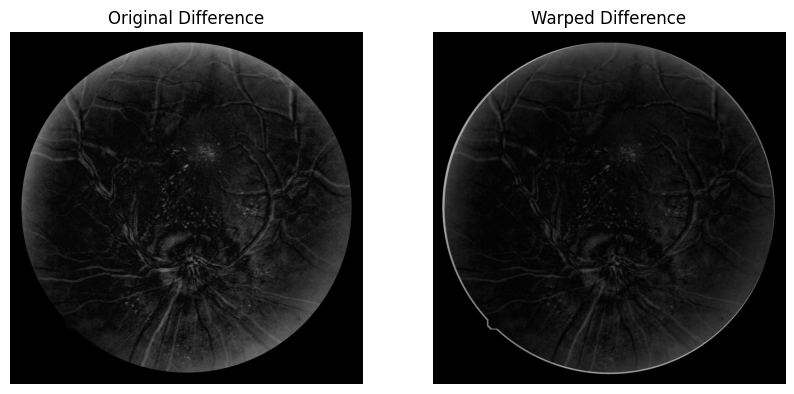

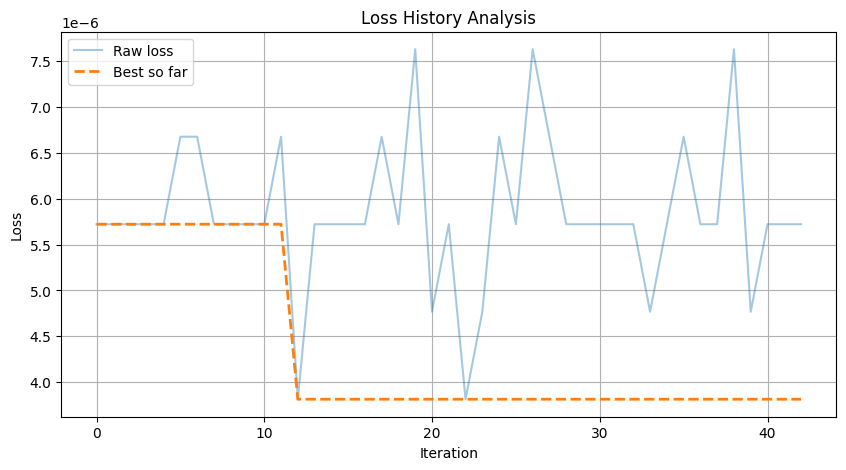

In [ ]:
transformation_matrix, registration_dict= airlab_mi_registration(fixed_image=img_ref,
                       moved_image=img_test,
                       image_dtype = torch.float32,
                       masked_images=True,
                       normalization_type = 'same', # 'same' or 'humansensitivity'
                       metric_num_bins = 64,
                       spatial_sampling=1.0,
                       metric_sigma=1.0,
                       learning_rate = 1e-4,
                       num_iterations = 5000,
                       EarlyStopping=True,
                       show_plots = True,
                       smart_storage=True,)
plot_loss_history(registration_dict['loss_history'], window=50)

In [ ]:

registration_dict.keys(), registration_dict['registrations_data'].keys()

(dict_keys(['registration_type', 'time_taken', 'registrations_data', 'normalization_type', 'loss_history', 'device']),
 odict_keys(['_phi_z', '_t_x', '_t_y', '_scale_x', '_scale_y', '_shear_y_x', '_shear_x_y']))

In [ ]:
import airlab as al 
import torch as th
from airlab.loss.pairwise import MI
from airlab.transformation.pairwise import SimilarityTransformation, AffineTransformation

start = time.time()
def airlab_es_registration(
    img_ref: Path | th.Tensor,
    img_test: Path | th.Tensor,
    num_iterations: int = 5000,
    device: Optional[th.device] = None,
    lr : float = 1e-4,
)->Dict:

        
    logs=logging.getLogger(__name__)
        
                        
    # set the used data type
    dtype = th.float32
    # set the device for the computaion to CPU
    device = th.device("cuda" if th.cuda.is_available() else "cpu")

    # In order to use a GPU uncomment the following line. The number is the device index of the used GPU
    # Here, the GPU with the index 0 is used.
    # device = th.device("cuda:0")

    # load the image data and normalize to [0, 1]
    fixed_image = al.read_image_as_tensor("./data/affine_test_image_2d_fixed.png", dtype=dtype, device=device)
    moving_image = al.read_image_as_tensor("./data/affine_test_image_2d_moving.png", dtype=dtype, device=device)

    fixed_image, moving_image = al.utils.normalize_images(fixed_image, moving_image)

    # convert intensities so that the object intensities are 1 and the background 0. This is important in order to
    # calculate the center of mass of the object
    fixed_image.image = 1 - fixed_image.image
    moving_image.image = 1 - moving_image.image

    # create pairwise registration object
    registration = al.PairwiseRegistration()

    # choose the affine transformation model
    transformation = al.transformation.pairwise.SimilarityTransformation(moving_image, opt_cm=True)
    # initialize the translation with the center of mass of the fixed image
    transformation.init_translation(fixed_image)

    registration.set_transformation(transformation)

    # choose the Mean Squared Error as image loss
    image_loss = al.loss.pairwise.MSE(fixed_image, moving_image)

    registration.set_image_loss([image_loss])

    # choose the Adam optimizer to minimize the objective
    optimizer = th.optim.Adam(transformation.parameters(), lr=0.01, amsgrad=True)

    registration.set_optimizer(optimizer)
    registration.set_number_of_iterations(1000)

    # start the registration
    registration.start()

    # set the intensities back to the original for the visualisation
    fixed_image.image = 1 - fixed_image.image
    moving_image.image = 1 - moving_image.image

    # warp the moving image with the final transformation result
    displacement = transformation.get_displacement()
    warped_image = al.transformation.utils.warp_image(moving_image, displacement)

    end = time.time()

    logs.debug("=================================================================")

    logs.info("Registration done in:", end - start, "s")
    logs.info("Result parameters:")
    transformation.print()

    # plot the results
    plt.subplot(131)
    plt.imshow(fixed_image.numpy(), cmap='gray')
    plt.title('Fixed Image')

    plt.subplot(132)
    plt.imshow(moving_image.numpy(), cmap='gray')
    plt.title('Moving Image')

    plt.subplot(133)
    plt.imshow(warped_image.numpy(), cmap='gray')
    plt.title('Warped Moving Image')

    plt.show()



naed - k in registration data has value: 0.1


In [ ]:
from PIL import Image as PImage
if TEST_FOR['airlab']:
    try:
        im_ami_drive = Path(f'{RESULT_PATH}/ImgRes/AMI_sigma3.0_nite100_bins64_lr0.0001__20260302_141349.png')
        assert PImage.open(im_ami_drive) # to visualize remove assert
    except Exception as e:
        logs.error(f"Error loading image from drive: {e}")
        

In [ ]:
if TEST_FOR['airlab']:
    import torch
    import sys
    from skimage.color import rgb2gray
    import SimpleITK as sitk
    from airlab.utils.image import Image as AirlabImage
    import airlab as al
    from airlab.registration import PairwiseRegistration

    from airlab.loss.pairwise import MI
    from airlab.transformation.utils import warp_image

    #=========== SKELETON  of AIRLAB REGISTRATION==============

    A01_test = test_images_path / 'Longitudinal_Studies' / 'A01_2.jpg'
    A01_reference = reference_images_path / 'Longitudinal_Studies' / 'A01_1.jpg'
    img_ref, img_test, test_image_name, reference_image_name = first_batch
    image_dtype= torch.float32
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    img_ref_al = AirlabImage(tensor_img_to_sitk(img_ref),image_dtype)
    img_test_al = AirlabImage(tensor_img_to_sitk(img_test), image_dtype)

    al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=img_test_al, opt_cm=False)
    al_transformation.init_translation(fixed_image=img_ref_al)

    # set the similarity metric:
    ami_metric = MI(fixed_image=img_ref_al, moving_image=img_test_al, sigma=0.02, bins=32)
    MSE_metric = al.loss.pairwise.MSE(fixed_image=img_ref_al, moving_image=img_test_al)
    # set optimizer
    al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-4, amsgrad=True)


    # set the registration type: 
    start_registration = False
    if start_registration:
        registration = PairwiseRegistration()
        registration.set_transformation(al_transformation)
        registration.set_optimizer(al_optimizer)
        registration.set_image_loss([ami_metric])
        registration.set_number_of_iterations(10)
        registration.start(EarlyStopping=False)




    

In [ ]:

if TEST_FOR['airlab']:
    interval = [ 0. , 0.37]
    max_val = max(interval)
    min_val = min(interval)
    background_image = torch.from_numpy((img_ref_al.numpy() > min_val ) & ( img_ref_al.numpy() < max_val)).float()
    logs.info(f'tipo: {type(background_image)}, dati all\'interno : {background_image.dtype}, device: {img_ref_al.device}')
    plt.imshow(background_image.numpy())


In [ ]:
if TEST_FOR['airlab']:
    plt.imshow(img_ref_al.numpy(), cmap='grey')
    plt.axis('off')

In [ ]:
if TEST_FOR['airlab']:
    al_transformation._compute_transformation_matrix()

In [ ]:
if  TEST_FOR['airlab']:
    # Comparison before and after registration
    warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
    difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
    difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

    difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
    difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
    print(f"Mean Absolute Difference before registration: {difference_mean_original}")
    print(f"Mean Absolute Difference after registration: {difference_mean_warped}")
    plt.imshow(np.abs(warped_image_al.numpy() - img_ref_al.numpy()))
    plt.axis('off')

In [ ]:
if TEST_FOR['airlab']:
    from airlab.transformation.utils import warp_image
    # invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
    # in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
    warp_image_displacement= al_transformation.get_displacement()
    warped_image= warp_image(img_test_al, warp_image_displacement)
    warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
    # vedere la differenza tra le immagini
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title('Test moved Image')  
    ax[0].imshow(img_ref_al.numpy())
    ax[0].axis('off')
    ax[1].set_title('Warped Image after Registration')
    ax[1].imshow(warped_image.numpy())
    ax[1].axis('off')

In [ ]:
from airlab.utils.image import Image as AirlabImage
import airlab as al
from airlab import PairwiseRegistration
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image

def clean_and_normalize(img:torch.Tensor
                        )-> torch.Tensor:
    '''
    clean the image from negative values and normalize it between 0 and 1
    '''
    img=torch.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    imin, imax = img.min(), img.max()
    if imax - imin < sys.float_info.epsilon:
        return torch.zeros_like(img)
    else:
        img = (img - imin) / (imax - imin)  
    return img

if TEST_FOR['airlab']:
    image_type = torch.float32

    img_ref_normalized = clean_and_normalize(img_ref)
    img_test_normalized = clean_and_normalize(img_test)

    ref_sitk = tensor_img_to_sitk(img_ref_normalized) # prova a usare i metodi di SITK
    test_sitk = tensor_img_to_sitk(img_test_normalized)

    #importazione delle immagini in formato Image per airlab
    ref_al_image = AirlabImage(ref_sitk, image_type=image_type)
    test_al_image = AirlabImage(ref_sitk, image_type=image_type) # prova con la stessa immagine

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # set the transformation type:
    al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=test_al_image, opt_cm=False)
    al_transformation.init_translation(fixed_image=ref_al_image)

    # set the similarity metric:
    ami_metric = MI(fixed_image=ref_al_image, moving_image=test_al_image, bins=64, sigma=0.09)
    MSE_metric = al.loss.pairwise.MSE(fixed_image=ref_al_image, moving_image=test_al_image)
    # set optimizer
    al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-2, amsgrad=True)


    # set the registration type: 
    registration = PairwiseRegistration()
    registration.set_transformation(al_transformation)
    registration.set_optimizer(al_optimizer)
    registration.set_image_loss([ami_metric])
    registration.set_number_of_iterations(20)
    registration.start(EarlyStopping=False)


In [ ]:
torch.cuda.is_available()

True

In [ ]:
   
 # Comparison before and after registration with mean absolute difference
if TEST_FOR['airlab']:
    warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
    difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
    difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

    difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
    difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
    print(f"Mean Absolute Difference before registration: {difference_mean_original}")
    print(f"Mean Absolute Difference after registration: {difference_mean_warped}")

In [ ]:
if TEST_FOR['airlab']:
    from airlab.transformation.utils import warp_image
    # invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
    # in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
    warp_image_displacement= al_transformation.get_displacement()
    warped_image= warp_image(test_al_image, warp_image_displacement)
    warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
    # vedere la differenza tra le immagini
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title('Test moved Image')  
    ax[0].imshow(img_test.squeeze().permute(1,2,0).detach().numpy())
    ax[0].axis('off')
    ax[1].set_title('Warped Image after Registration')
    ax[1].imshow(warped_image.numpy())
    ax[1].axis('off')

    # calcolo della loss e esplicita i risultati della registrazione

In [ ]:
if TEST_FOR['airlab']:
    esth= torch.randint(0, 10, (3, 4, 5), dtype=torch.float32)
    print(esth.shape)
    print(esth.mean(dim=0, keepdim=True).shape)

## NORMALIZED MUTUAL INFORMATION ELASTIX

#### Usage of itk elastix from examples

In [ ]:
import itk
import numpy as np
import matplotlib.pyplot as plt

def image_generator(x1, x2, y1, y2):
    '''
    Generate a simple synthetic image with a square in the center.
    '''
    image = np.zeros([100, 100], dtype=np.float32)
    image[y1:y2 , x1:x2] = 1.0
    image=itk.image_view_from_array(image)
    return image

def show_images(image_list):
    '''
    Show a list of images using matplotlib.
    '''
    labelled_images= ['fixed', 'moving', 'registered']
    num_images = len(image_list)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    for i, image in enumerate(image_list):
        array_image = itk.array_view_from_image(image)

        axes[i].imshow(array_image, cmap='gray')
        axes[i].set_title(labelled_images[i])
        axes[i].axis('off')
    plt.show()

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    image_list= [image_generator(i, i+20, i+20, i+40) for i in range(10, 40, 10)]
    show_images(image_list)
    image0 =image_list[0]
    image1 =image_list[1]
    image2 =image_list[2]

In [ ]:
# creating a euler 2d transformation:

if not IN_COLAB:
    traslation = [15.0, -10.0]  # x and y translation
    transformation= itk.Euler2DTransform.New()
    transformation.SetOffset(traslation) 
    transformation.SetAngleInDegrees(15)  
    transformation.SetCenter([50.0, 50.0])  # center of rotation

    parameter_map ={
        'Direction' : ('1','0','0','1'),
        'Index' : ('0', '0'),
        'Origin' : ('0.0', '0.0'),
        'Size' : ('100', '100'),
        'Spacing' : ('1.0', '1.0'),
        'FinalBSplineInterpolationOrder' : ('0'),
    }
    transform_parameter_object= itk.ParameterObject.New()
    transform_parameter_object.AddParameterMap(parameter_map)
    transformix_filter = itk.TransformixFilter.New(image0)
    transformix_filter.SetMovingImage(image1)
    transformix_filter.SetTransformParameterObject(transform_parameter_object)
    transformix_filter.SetTransform(transformation)
    transformix_filter.Update()
    moved_image = transformix_filter.GetOutput()
    show_images([image0, moved_image])

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    rigid_parameter_object = itk.ParameterObject.New()
    rigid_parameter_map = rigid_parameter_object.GetDefaultParameterMap('rigid')
    rigid_parameter_map['FinalBSplineInterpolationOrder'] = ('0')
    rigid_parameter_object.AddParameterMap(rigid_parameter_map)

    print(rigid_parameter_object)

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
        unconstrained_result_image, result_transform_parameters = itk.elastix_registration_method(
        image0, moved_image,
        parameter_object=rigid_parameter_object,
        log_to_console=False)
        show_images([image0, moved_image, unconstrained_result_image])

In [ ]:
if not IN_COLAB:
    type(img_ref), img_test.shape, reference_images_path, fire_images_path,reference_files[1], test_files[1]

In [53]:
sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    import itk
    # definisci una funzione per fare questo a partire da reference_files e test_files e 
    # impostare alcuni dati, solo numerici; imposta un timer per controllare quanto tempo 
    #ci mette la registrazione
    fixed_image = itk.imread(sample_dictA01['reference_image_path'], itk.F)
    moved_image = itk.imread(sample_dictA01['test_image_path'], itk.F)

    transformation_parameters = itk.ParameterObject.New() # set the pparameter object
    affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
    affine_params_map['metric'] = ['NormalizedMutualInformation']
    affine_params_map['NumberOfHistogramBins'] = ['32']
    affine_params_map['NumberOfResolutions'] = ['3']
    affine_params_map['MaximumNumberOfIterations'] = ['5000']
    transformation_parameters.SetParameterMap(affine_params_map)
    final_image, registration_parameters=  itk.elastix_registration_method(
        fixed_image=fixed_image,
        moving_image=moved_image,
        parameter_object=transformation_parameters,
        log_to_console=True)
    #transform_parameter_object.SetParameterMap(affine_params_map)

    # Save results: 
    image_name = sample_dictA01['reference_image_path'].stem.split('_')[0]
    #itk.imwrite(final_image, str(elastix_saving_folder / f'{image_name}.nii.gz'))

    # chiama funzione





[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements


In [102]:
import logging
from typing import Callable
from pathlib import Path
import itk
#1. get iimage from path or tensor from dataset:
def elastix_wrapper_for_registration(sample_dict: SampleDict,
                                     config_dict: dict,
                                     elastix_registration_fn: Callable[[SampleDict, dict], dict],
                                     )-> dict:
    '''
    Wrapper function for elastix registration. It takes a sample dictionary and a configuration dictionary, and
    returns a dictionary containing the registration results and parameters.
    Parameters
    ----------
    sample_dict : SampleDict
        The sample dictionary containing the image paths.
    config_dict : dict
        The configuration dictionary for the registration.
    
    Returns
    -------
    dict
        A dictionary containing the registration results and parameters.
    '''
    logs=logging.getLogger(__name__)
    test_image = itk.imread(sample_dict['test_sample_path'], itk.F)
    reference_image = itk.imread(sample_dict['reference_sample_path'], itk.F)

    itk_registration, time_taken, registred_image = elastix_registration_fn(reference_image=reference_image,
                                                           test_image=test_image,
                                                           config_dict=config_dict)
    homography_matrix = get_affine_matrix_from_sitk_transform(sitk_transform=itk_registration)

    naed_diagonal = naed_evaluation(image_couple_name=sample_dict['sample_name'],
                                    affine_matrix=homography_matrix,
                                    image_normalization='diagonal')
    naed_norm_coord = naed_evaluation(image_couple_name=sample_dict['sample_name'],
                                    affine_matrix=homography_matrix,
                                    image_normalization='coords_norm')
    
    registration_results={}
    registration_results['registered_image']= registred_image
    registration_results['homography_matrix'] = homography_matrix
    registration_results['time_taken'] = time_taken
    registration_results['naed_diagonal'] = naed_diagonal
    registration_results['naed_norm_coord'] = naed_norm_coord

    return registration_results
def elastix_registration(reference_image: itk.Image,
                        test_image: itk.Image,
                        config_dict: dict,
                       
                        )-> tuple:
    '''
    the registration of two images using elastix via itk 
    Parameters
    ----------
    reference_image_path : Path
        The path to the reference image.
    test_image_path : Path
        The path to the test image.
    histogram_bins : int
        Number of histogram bins for the mutual information metric.
    num_resolutions : int
        Number of pyramid's steps for the registration.
    max_iterations : int
        Maximum number of iterations for the registration.
    
    Returns
    -------
    tuple
        The registered image and the registration parameters.
    '''
    logs=logging.getLogger(__name__)
    elastix_config_dict= config_dict['registrations']['elastix_original']
    sampling_ratio = elastix_config_dict['sampling_ratio'] # not specified in the article, but used to be coherent with other methods
    histogram_bins= elastix_config_dict['histo_bins']
    num_resolutions= elastix_config_dict['n_resolution']
    max_iterations= elastix_config_dict['n_iterations']
    with block_time() as registration_time:
        transformation_parameters = itk.ParameterObject.New() # set the pparameter object
        affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
        affine_params_map['metric'] = ['NormalizedMutualInformation']
        affine_params_map['MetricSamplingPercentage'] = [f'{sampling_ratio}']
        affine_params_map['WritingResultImage'] = ['false'] # to avoid saving the registered image in the current folder
        affine_params_map['DefauldtPixelValue'] = ['0'] # to avoid having black borders in the registered image
        affine_params_map['NumberOfHistogramBins'] = [f'{histogram_bins}']
        affine_params_map['NumberOfResolutions'] = [f'{num_resolutions}']
        affine_params_map['MaximumNumberOfIterations'] = [f'{max_iterations}']
        transformation_parameters.SetParameterMap(affine_params_map)
    
        registred_image, registration_parameters=  itk.elastix_registration_method(
            fixed_image=reference_image,
            moving_image=test_image,
            parameter_object=transformation_parameters,
            log_to_console=True)
    time_taken = registration_time[0]


    return registration_parameters, time_taken, registred_image





In [103]:
def extract_image_name(image_path: Path
                             )-> str:
    '''
    Extract the image name from the image path without extension.
    '''
    return image_path.stem

#plt.imshow(np.array(itk.array_view_from_image(fixed_image)))
def rescaling_image(img:itk.Image):
    '''
    Rescale the image to the range [0, 1] 
    '''
    rescaler = itk.RescaleIntensityImageFilter.New(img)
    rescaler.SetOutputMinimum(0.0)
    rescaler.SetOutputMaximum(1.0)
    rescaler.Update()
    rescaled_img = rescaler.GetOutput()
    return rescaled_img
#plt.imshow(np.array(itk.array_view_from_image(rescaling_image(fixed_image))))
def elastix_show_difference_image(reference_image: itk.Image,
                                test_image: itk.Image,
                                registered_image: itk.Image,
                                save_image:bool = False,
                                config_dict: dict = {},
                               )-> None:
    '''
    Show the difference images between reference and test, and reference and registered images.
    '''# prima normalizza poi differenza
    reference_normalized = rescaling_image(reference_image)
    test_normalized = rescaling_image(test_image)
    registered_normalized = rescaling_image(registered_image)
    original_difference = np.array(itk.array_view_from_image(reference_normalized) - np.array(itk.array_view_from_image(test_normalized)))
    registered_difference = np.array(itk.array_view_from_image(reference_normalized) - np.array(itk.array_view_from_image(registered_normalized)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.figsize=[100,100]
    axes[0].imshow(original_difference, cmap='gray')
    axes[0].set_title('Prior Registration', fontsize=10, loc='left')
    axes[0].axis('off')
    axes[0].set_title(f'RMSE: {np.sqrt((original_difference**2).mean()):.4f}', fontsize=10, loc='right')
    axes[1].imshow(registered_difference, cmap='gray')
    axes[1].set_title('After Registration', fontsize=10, loc='left')
    axes[1].axis('off')
    axes[1].set_title(f'RMSE: {np.sqrt((registered_difference**2).mean()):.4f}', fontsize=10, loc='right')
    fig.get_label()
    imagedir_save_path = PROJECT_PATH/ Path(*config_dict['constant']['path-like']['IMG_RESULTS'])
    assert imagedir_save_path.exists(), f"Image results directory {imagedir_save_path} does not exist. Please control the project directory for saving images."
    if save_image:
        plt.savefig(imagedir_save_path / 'Difference_Elastix.png')
    plt.show()

    return None




In [104]:
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
elastix_config_dict= config_dict['registrations']['elastix_original']
elastix_config_dict

{'n_iterations': 5, 'histo_bins': 64, 'n_resolution': 4, 'sampling_ratio': 0.5}

In [105]:
Path(*config_dict['constant']['path-like']['IMG_RESULTS'])

WindowsPath('Main_Folder/Results/ImgRes')

[INFO] __main__ - since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements


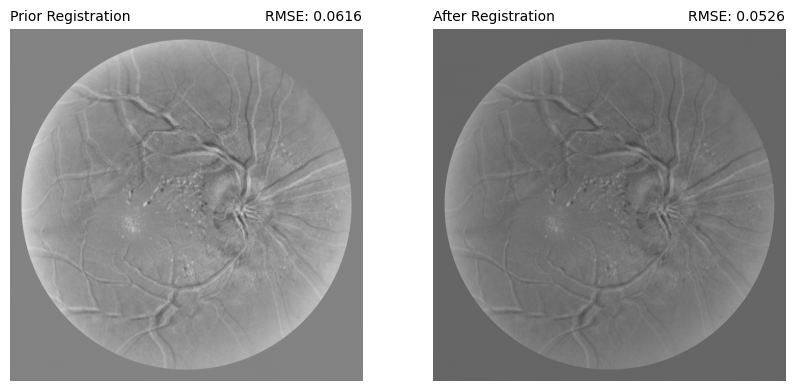

In [106]:


if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml', priority='personal') # FIXME the current output of config_dict is always a str
    sample_dictA01 = general_preprocessing(sample_dict=dataset.__getitem__(0),
                                       config_dict=config_dict,)
    registration_results = elastix_wrapper_for_registration(sample_dict=sample_dictA01,
                                                            config_dict=config_dict,
                                                            elastix_registration_fn=elastix_registration)
    elastix_show_difference_image(reference_image=itk.imread(sample_dictA01['reference_sample_path'], itk.F),
                                test_image=itk.imread(sample_dictA01['test_sample_path'], itk.F),
                                registered_image=registration_results['registered_image'],
                                config_dict=config_dict,)
                                
    

In [ ]:
registration_parameters.GetParameterMap(0).keys()

In [ ]:
if not IN_COLAB:
    new_dict_of_registration_parameters ={}
    for k,v in registration_parameters.GetParameterMap(0).items():
        new_dict_of_registration_parameters[k]=v
    new_dict_of_registration_parameters

In [ ]:
if not  IN_COLAB:
    registration_parameters.GetParameterMap(0)['TransformParameters']

In [ ]:
if not IN_COLAB:
    n = registration_parameters.GetNumberOfParameterMaps()
    print("Number of parameter maps:", n)

    for i in range(n):
        pmap = registration_parameters.GetParameterMap(i)
        print(f"\n--- Parameter map {i} ---")
        for k, v in pmap.items():
            print(k, ":", v)


## DRMINE OUTLINE

In [61]:
from typing import Literal, Callable
#FIXME wrapper per le funzioni
def get_registration_matrix(ref_image : Path | torch.Tensor,
                            test_image : Path | torch.Tensor,
                            method: Literal['elastix', 'airlab'],
                            registration_method : Callable,
                            **kwargs
                            )-> np.ndarray:
    '''
    Get the registration matrix between two images using the specified method.
    Parameters
    ----------
    ref_image : Path | torch.Tensor
        The reference image, can be a path to the image or a tensor.
    test_image : Path | torch.Tensor
        The test image, can be a path to the image or a tensor.
    method : str
        The registration method to use, can be 'elastix' or 'airlab'.
    kwargs : dict
        Additional parameters for the registration method.
    
    Returns
    -------
    np.ndarray
        The registration matrix between the two images.
    '''
    
    if method == 'elastix':
        homography_matrix, _, _ = elastix_registration(
            reference_image_path=ref_image,
            test_image_path=test_image,
            **kwargs
        )
        return homography_matrix
    elif method == 'airlab':
        transformation_matrix, _ = airlab_mi_registration(
            fixed_image=ref_image,
            moved_image=test_image,
            **kwargs
        )
        return transformation_matrix.cpu().numpy()
    else:
        raise ValueError("Unsupported registration method. Choose 'elastix' or 'airlab'.")
# input - > dataloader / dataset
# get cropped pyramid
# get param list for registration
# construct of the nns
# construct the affine function for warping AffineTransform
# construct the multiresolution loss for training
# train the net to get the H, and collect results
# evaluate the training
# adapt H and get evaluation

# Evaluation methods

### NAED for image control point

In [60]:
from typing import Literal
def naed_evaluation(image_couple_name: str,
                    affine_matrix: np.ndarray | torch.Tensor, 
                    image_normalization :  Literal['diagonal' , 'coords_norm'] = 'coords_norm',
                    control_points_path: Path = CONTROL_POINTS_FOLDER,
                    image_dimensions: tuple | Path = (2912, 2912) ,
                    )-> float:
    '''
    Evaluate the registration using Normalized Average Euclidean Distance (NAED) metric.
    Parameters
    ----------
    image_couple_name : str
        The name of the image couple to get the control points file from the list. It has to be in the format 'A01', 'P19', 'S20', etc.
    control_points_file : Path
        The path to the control points coordinates.
    affine_matrix : np.ndarray | torch.Tensor
        The affine transformation matrix get by image registration algoritm it has to be in the complete form : | A t |
                                                                                                                | 0 a |
    image_dimensions : tuple | Path
        The dimensions of the images or the path to the image to get the dimensions to normalize.
    '''
    h,w = image_dimensions
    logs=logging.getLogger(__name__)
    #1. get the control points for the image couple
    test_points_list, reference_points_list = get_coords(
        image_name=image_couple_name,
        ground_truth_path=control_points_path
    )

    test_points = np.array(test_points_list, dtype=np.float32)  # shape (N, D)  D = 2 
    reference_points = np.array(reference_points_list, dtype=np.float32)  # shape (N, D)

    assert test_points.shape == reference_points.shape , "Test and reference points must have the same shape"

    #2. control of affine matrix? for 2/3D or affine type? NOTE for the moment it has just to be in a quadratic form NxN
    if isinstance(affine_matrix, torch.Tensor):
        affine_matrix = affine_matrix.detach().cpu().numpy()
    affine_matrix = np.asarray(affine_matrix, dtype=np.float32)
    n, m = affine_matrix.shape
    if n != m:
        raise ValueError(f'The affine matrix must be square, got {n}x{m}')
    
    if n == 4:
        total_distance = np.nan # NOTE the 3D case has yet to be treated
        logs.info('the 3D case has yet to be treated')
        return total_distance
    
    elif n == 3:
        #3. for each list of coords: apply the matrix -> get the Euclidean distance
        total_distance = 0.0
        assert test_points.shape[-1] == 2, "Test points must be 2D coordinates"
        ones_column = np.ones((test_points.shape[0], 1), dtype=np.float32)  # shape (N, 1)
        homogeneous_test_points = np.hstack((test_points, ones_column))  # shape (N, 3
        homogeneous_warped_points = homogeneous_test_points @ affine_matrix.T  # shape (N, 3), already interpolated, using round/nearest neighbor
        
        incongruencies = [w for w in homogeneous_warped_points[:, 2] if w == 0]
        if len(incongruencies) > 0:
            total_distance = np.nan #raise ValueError("There are some incongruencies in this transformation, some points have w=0") #FIXME return NaN o gestisci in altro modo
            return total_distance
        
        else: 
            warped_points = np.rint([[x_w/w, y_w/w] for (x_w, y_w, w) in homogeneous_warped_points]).astype(np.int32)  # shape (N, 2)
            total_distance += np.linalg.norm(warped_points - reference_points, axis=1).mean()

    #4. normalize the NAED value
    if image_normalization == 'diagonal':
        #4.1 get the NAED value using image diagonal to normalize
        ratio = np.sqrt(h**2 + w**2)
    elif image_normalization == 'coords_norm':
        #4.2 get the NAED value using the norm of the image dimensions to normalize
        ratio = h
        
    #5. return NAED value in float
    naed_value = total_distance / ratio
    
    return naed_value
    


In [40]:
matrix_es =transformation_matrix.detach().cpu().numpy()
naed_calculated_coords = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='coords_norm',
                                    image_dimensions=(2912, 2912))

naed_calculated_diagonal = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='diagonal',
                                    image_dimensions=(2912, 2912))  
print(f'NAED calculated with coords norm: {naed_calculated_coords};\nNAED calculated with diagonal norm: {naed_calculated_diagonal}')

NameError: name 'transformation_matrix' is not defined

# Collect results of various methods:
-time of registration

-name of image pair

-registration matrix

-evaluation of NAED




In [62]:
from typing import Optional

def registration_named_file(data_collector: Optional[dict],
                            other_useful_data : Optional[dict],
                            extra : str = 'Reg_ES'
                            )->str:
    '''
    The easy function to collect info about registration in progress or just concluded to generate a good name for saving file

    Args:
        data_collector (Optional[Registration_Data_collector]): the collector of data where most of information has kept
        other_data (dict): other relevant information to introduce in naming file

    Returns:
        str: the name for file registration
    '''
    if data_collector:
        registration_name = data_collector.registration_name
        dimension_of_dataset = 'full' if len(data_collector.collection) == 134 else 'sample'
    else: 
        data_collector= {}
        registration_name = 'Reg_Es'
        dimension_of_dataset = 'full' if len(data_collector) == 134 else 'sample'

    file_name_for_registration= f'{registration_name.upper()}_{dimension_of_dataset}'
    for k, v in other_useful_data.items():

        file_name_for_registration += f"_{v.replace(' ', '_')}"
        
                                      
                                        
    return file_name_for_registration


import inspect

def get_param_info(func, param_name):
    sig = inspect.signature(func)
    
    if param_name not in sig.parameters:
        return None
    
    p = sig.parameters[param_name]
    
    return {
        "annotation": p.annotation,
        "kind": p.kind,
        "default": p.default
    }

print(get_param_info(registration_named_file, "extra"))


{'annotation': <class 'str'>, 'kind': <_ParameterKind.POSITIONAL_OR_KEYWORD: 1>, 'default': 'Reg_ES'}


### solution for the retrieve of data from csv files

In [44]:
import pandas as pd
import numpy as np
def retrieve_data_from_csv(path: Path) -> pd.DataFrame:
    '''
    Retrieve registration data from a csv file and convert the affine matrix from string to numpy array.
    '''
    df = pd.read_csv(path, index_col='image_pair_name')
    df['affine_matrix'] = df['affine_matrix'].apply(lambda x: np.fromstring(x.replace('[', '').replace(']', ''), sep=' ').reshape(3, 3))
    return df



### Define WRAPPERS for all registrations methods:

INPUTS:dataset == (reference image, test image) , parameters  x registration and preprocessing get the params from yaml/ configuration files

OUTPUTS: Data collector - type

----------------
IMPORTANT
---------------
 LEAVE OUT OF THE WRAPPERS EVERYTHING THAT IS COMMON TO ANY REGISTRATION METHODS: dataset definitions, 




#### preprocessing

In [25]:
from typing import Callable, Tuple, Union, Optional
import logging
#------------
#LIST OF PREPROCESSING
#-----------------
def general_preprocessing(sample_dict: Union[SampleDict, Sequence],
                       config_dict: dict,
                       transformations : Optional[Tuple[Callable[[SampleDict, dict], SampleDict], ...]] = None,
                       )-> SampleDict:
    '''
    The point is to adapt the most of preprocessing function to be inserted in an ordinated list to use them in an ordered and methodical way during the pipeline
    For simplicity all of them must have the same input data type as for the same output data type

    ----
    IMPORTANT
    ----------
    if the sample_dict is the item from dataset.__getitem__(index) then the elements must be sorted out as:
            sample_dict = ('reference_sample', 'test_sample', 'reference_sample_path', 'test_sample_path').
    
    ----------- 
    Parameters
    ----------- 

        sample_dict (SampleDict): Starting point, constructed by the dataset 
        config_dict (dict): possibly taking by a yaml file to use the method dict_type.get('key', default) to avoid errors
        transformations (Tuple[Callable, ...]): An ordinated tuple of preprocessing functions to be applied in order, they have to have the same input and output type to be used in this way.

    Returns
    ---------

        dict: the dict has to be almost on the same type of SampleDict to better flexibility during pipeline
    '''
    preprocessed_sample = sample_dict
    logs=logging.getLogger(__name__)
    if isinstance(sample_dict, Sequence) and not isinstance(sample_dict, dict):
        
        test_image, reference_image, test_path, reference_path = sample_dict
        logs.info(f'preprocessing sample shape: {test_image.shape}, {reference_image.shape}')
        preprocessed_sample = {
            'reference_sample': reference_image,
            'test_sample': test_image,
            'reference_sample_path': Path(reference_path),
            'test_sample_path': Path(test_path),
            'sample_name': Path(reference_path).stem.split('_')[0],
        }
    if transformations:
        for transformation in transformations:
            preprocessed_sample = transformation(preprocessed_sample, config_dict)
    else: 
        logs.info('since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements')
    logs.info(f'reference/test image sample shape: {preprocessed_sample["reference_sample"].shape}')
    return preprocessed_sample

def sitk_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using SimpleITK. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.
    For this experiment: 
    MMI-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    JHMI-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    MSE-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    NCC-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.

    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''

    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample



def airlab_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using Airlab. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.
    AMI: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[torch.Tensor, dict]
    in the middle from input to 
    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.

    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''
    #===========READ IMAGES========
    

    return sample_dict



def drmine_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using DeepReg. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.

    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.
    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''
    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample

def elastix_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using Elastix. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.

    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.
    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''
    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample


#### wrappers

In [65]:
#---------------
#LIST OF WRAPPERS
#-----------------
import logging
from typing import Callable, Any
'''import tensor_img_to_sitk, np,  sitk.ReadImage, naed_evaluation, get_affine_matrix_from_sitk_transform....'''
def sitk_wrapper_for_registration(sample_dict: SampleDict, 
                              config_dict: dict,
                              sitk_registration_fn: Callable[[sitk.Image, sitk.Image, dict], tuple[Any, sitk.ImageRegistrationMethod, float]],
                              
                              )-> dict:
    '''
    A wrapper function to run the registration pipeline using SimpleITK. It takes a sample dictionary and a configuration dictionary as input and returns a dictionary containing the registration results.

    Parameters
    -------------
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for registration.
        sitk_registration_fn (Callable): A function that performs the registration using SimpleITK:
            INPUTs - sitk.Image, sitk.Image, dict
            OUTPUTs - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]

    Return
    ------------
        dict (dict): A dictionary containing the registration results, including the affine matrix, NAED value, and time taken for registration, mean for used in the data collector
    '''
    logs= logging.getLogger(__name__)
    reference_image = sample_dict['reference_sample']
    test_image = sample_dict['test_sample']

    if isinstance(reference_image, Path):
        reference_sitk = sitk.ReadImage(reference_image, sitk.sitkFloat32)
    elif isinstance(reference_image, torch.Tensor) or isinstance(reference_image, np.ndarray):
        reference_sitk = tensor_img_to_sitk(reference_image)

    if isinstance(test_image, Path):
        test_sitk = sitk.ReadImage(test_image)
    elif isinstance(test_image, torch.Tensor) or isinstance(test_image, np.ndarray):
        test_sitk = tensor_img_to_sitk(test_image)

    if reference_sitk.GetSize() != test_sitk.GetSize():
            raise ValueError("The two images must have the same shape")
    
    
    
    sitk_transformation, registration_data, time_taken = sitk_registration_fn(reference_image = reference_sitk,
                                                                            test_image = test_sitk,
                                                                            config_dict = config_dict)
    
    #NOTE remember to use registration_data to get an affine matrix from get_affine_matric_from_sitk_transform
    homography_matrix=get_affine_matrix_from_sitk_transform(sitk_transform=sitk_transformation)

    naed_diagonal = naed_evaluation(image_couple_name=sample_dict['sample_name'],
                                    affine_matrix=homography_matrix,
                                    image_normalization='diagonal')
    naed_norm_coord = naed_evaluation(image_couple_name=sample_dict['sample_name'],
                                    affine_matrix=homography_matrix,
                                    image_normalization='coords_norm')
    

    registration_results={}
 
    #registration_results['registration_object']= registration_data NOTE not useful now
    registration_results['naed_diagonal'] = naed_diagonal
    registration_results['naed_coords'] = naed_norm_coord
    registration_results['sitk_transformation'] =  sitk_transformation
    registration_results['affine_matrix'] = homography_matrix
    registration_results['time_taken'] = time_taken
    
    return registration_results

In [48]:
image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
dataloader_es =DataLoader(image_dataset, batch_size=1, shuffle=False)
dataset_iterator = iter(dataloader_es)
sample = next(dataset_iterator)
#image_dataset.test_images[0].stem.split('_')[0]
for i , sample in enumerate(dataloader_es):
    print(sample[0].shape, type(sample[1]))
    if i == 1:
        break

torch.Size([1, 3, 2912, 2912]) <class 'torch.Tensor'>
torch.Size([1, 3, 2912, 2912]) <class 'torch.Tensor'>


In [49]:
from typing import Callable, TypedDict, Optional, Tuple, Sequence
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from itertools import islice
from airlab.utils.image import Image as AirlabImage
image_type = Union[torch.Tensor, itk.Image, sitk.Image, AirlabImage]
#---------------------
#REGISTRATION PIPELINE
#---------------------
# ALREADY DEFINED: 
# DATASET ---> DataLoader to be inserted in the pipeline

PreprocessingFn = Callable[[SampleDict | Sequence, dict], SampleDict]
RegistrationFn = Callable[[SampleDict, dict], dict]


def run_registration_pipeline(dataset : Dataset,                              
                              registration_fn: RegistrationFn,
                              preprocessing_fn: Optional[PreprocessingFn] = general_preprocessing,
                              save_results: bool = True,
                              project_root : Optional[Path]=None,
                              )-> Tuple[Registration_Data_Collector, Optional[Path]]:
    '''
    It RUN a registration Pipeline to actually get the registration results to be put in the DataCollector created
    the PIPELINE: get the dataset as first input:
    DATASET ----> PREPROCESSING ---> REGISTRATION to get results

    Args:
        dataset (Dataset): the Dataset of images it get a easy access to images as path like or PIL images
        preprocessing_fn (PreprocessingFn): adjust the images as requested for the Pipeline and the experiment
        registration_fn (RegistrationFn): main focus of the work, analyze, process, calculate informations about the image pair returning a defined formatted results
            to be collected in the designated object
        save_results (bool): whether to save the registration results
        project_root (Path): the root path of the project to save results in the right folder, if used from script use Path(__file__) as start_path

    Returns:
        Registration_Data_collector: The collector of results
    '''
    # 0. PRESET ALL THE PARAMETERS OR CONSTANT FROM YAML OR MANUAL
    logs = logging.getLogger(__name__)
    path_to_result = None
    if project_root is None:
        project_root = get_root_path(start_path=Path.cwd())
    config_dict = yaml_config_setup(project_root / 'config_file.yaml')
    data_collector = Registration_Data_Collector()
    
    batch_size = config_dict['constant']['num-like']['batch_size'] 
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    dataset_iterator = iter(dataloader)
    max_sample = config_dict['constant']['num-like']['max_sample'] 
    
    #1. DEFINE THE PIPELINE
    for sample in tqdm(islice(dataset_iterator, max_sample), total=max_sample, desc="Running Registration Pipeline"):
        
        preprocessed_sample = preprocessing_fn(sample, config_dict)
        registration_results = registration_fn(preprocessed_sample)

        data_collector.add_registration_data(registration_results)
    
    #2. SAVE RESULTS
    if save_results:
        result_type = config_dict['constant']['text-like']['SAVING_FORMAT']
        results_path = project_root / Path(*config_dict['constant']['path-like']['RESULTS'])
        path_to_results = data_collector.save_data(filename='wrapper_trial', fmt=result_type, results_path=results_path) # FIXME use config_dict

    
    

    return (data_collector, path_to_results)

IMPORTANTE, USA LE CELLE SOTTO COME RIFERIMENTO, DOPO LE DOVRAI COMUNQUE CANCELLARE E NON USARE PIU' 

### registration for all CPU-friendly methods


In [ ]:
from tqdm.notebook import tqdm
if not IN_COLAB:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    # Creare il dataloader

    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    for i in tqdm(range(whole_dataset)):
        test_image, reference_image, test_image_path, reference_image_path = next(dataset_iterator)
        path_to_test_image = image_dataset.test_images[i]
        path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name.stem[0], reference_image_name.stem[0]
        image_name_couple = test_image_name.split('_')[0]

        affine_matrix, registration_parameters_dict, time_taken = elastix_registration(reference_image_path=path_to_reference_image, 
                                                                test_image_path=path_to_test_image)
        
        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        
        registration_dict ={k:v for k,v in registration_parameters_dict.GetParameterMap(0).items()}
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix
        registration_dict['time_taken'] = time_taken

        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict, #specific for elastix
                                            registration_name='Elastix_NMI')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    path_to_data=data_collector.save_data(filename='Elastix_NMI_DRMINE_results', fmt='csv', overwrite=False)

In [ ]:
if not IN_COLAB:
    retrieved_mmi = retrieve_data_from_csv(path_to_data)
    assert type(retrieved_mmi['affine_matrix']['A01']) == np.ndarray, "The affine matrix is not a numpy array"

In [ ]:
import pickle
if not IN_COLAB:
    collector_name = f'{data_collector.registration_name}_data_collector.pkl'
    collector_path = Path(RESULT_PATH / 'DataCollectors' / collector_name)
    collector_path.parent.mkdir(parents=True, exist_ok=True)
    if collector_path.exists():
        collector_name = f'{data_collector.registration_name}_data_collector_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl'
        collector_path = Path(RESULT_PATH / 'DataCollectors' / collector_name)

    with open(collector_path, 'wb') as f:
        pickle.dump(data_collector, f)
    #data_collector

### Airlab Registration, to be adjusted based on cloud computing and GPU 

In [ ]:
from tqdm.notebook import tqdm
if TEST_FOR['airlab']:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    # Creare il dataloader

    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    for i in tqdm(range(whole_dataset)):
        test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
        #path_to_test_image = image_dataset.test_images[i]
        #path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name[0], reference_image_name[0]
        image_name_couple = test_image_name.split('_')[0]
        #test_image_cropped, reference_image_cropped = crop_images(moving_image=test_image, fixed_image=reference_image, show_images=False)
        affine_matrix, registration_dict = airlab_mi_registration(fixed_image=reference_image, 
                                                                moved_image=test_image,
                                                                masked_images=True,
                                                                learning_rate=1e-4,
                                                                metric_num_bins=64,
                                                                metric_sigma=1.0,
                                                                spatial_sampling=0.2,
                                                                normalization_type='same',
                                                                EarlyStopping=True,
                                                                num_iterations=5000,
                                                                smart_storage=True,)
        
        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix.detach().cpu().numpy()

        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict,
                                            registration_name='AirLab_MI')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    path_to_data=data_collector.save_data(filename='AirLab_MI_full_64bins_min_delta1e-7_results', fmt='csv', overwrite=False)
    pickle_obj = data_collector.save_data(filename='AirLab_MI_full_64bins_min_delta1e-7_results', fmt='pkl', overwrite=False)

### Assesting the Result information:
as dimension for each feature

In [ ]:
registration_dict['affine_matrix'],registration_dict['registrations_data']

In [154]:
import pickle
import sys
from pathlib import Path
from typing import Union, OrderedDict
def data_size_of_this(
        obj : Union[Path, Registration_Data_Collector],
        restricted_info : int = 5,
        mean_info : bool = False,
        )->None:
    '''
    the function get the object and return the dimension of the ensamble and parts of it

    Args:
        obj (Union[Path, Registration_Data_Collector]): the path where the object is saved or the Data collector itself
        restricted_info (int): it get a little samples of informations stored in the collector
        mean_info: it get the mean of information stored across the collector YET TO BE IMPLEMENTED

    
    Return:
        None
    '''
    if isinstance(obj, Path):
        if not obj.exists():
            raise FileNotFoundError('error during loading, the file doesn\'t exists')
        else:
            with open(obj, "rb") as f:
                try:
                    collector = pickle.load(f)
                except RuntimeError:
                    print('some error occured, try to get using torch.load')
                    try:
                        collector=torch.load(f,
                                pickle_module = pickle,
                                weights_only = False,
                                map_location=torch.device('cpu'))
                    except RuntimeError:
                        print('impossible to load the file control the type of file to be loaded, it has to be compatible with Registration_Data_Collector')
    
    else:
        collector = obj
    
    print('Num of  Sample: ', len(collector.collection))
    max_data_to_see = min(restricted_info, len(collector.collection))
    for image_pair in list(collector.collection.keys())[:max_data_to_see]:
        data = collector.collection[image_pair]
        print(f"Features of {image_pair}: {list(data.keys())}")
            
        for k, v in data.items():
            try:
                size_kb = sys.getsizeof(v) / 1024 
                if size_kb :
                    print(f"{k:24} → ~{size_kb:.2f} KB   (tipo: {type(v).__name__})")
            except:
                print(f"{k:24} → [errore nel sizeof]")

    return None



### DRMINE REGISTRATION

In [ ]:
fire_dataset_path= FIRE_DATASET_PATH
transform_tensor = transforms.Compose([transforms.ToTensor()])
image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
data_collector = Registration_Data_Collector()
# Creare il dataloader
cropped= False
image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
dataset_iterator = iter(image_dataloader)
whole_dataset = len(image_dataset)
little_sample = 2
learning_rate_set= {'v1': 1.e-5, 'vL': 1.e-3, 'mi': 1.e-2}
test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
test_image.shape

In [ ]:
from tqdm.notebook import tqdm
if TEST_FOR['DRMINE']:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    nChannel = image_dataset.get_nChannel()
    # Creare il dataloader
    cropped= False
    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    learning_rate_set= {'v1': 1.e-5, 'vL': 1.e-3, 'mi': 1.e-2}
    for i in tqdm(range(little_sample)):
        test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
        #path_to_test_image = image_dataset.test_images[i]
        #path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name[0], reference_image_name[0]
        image_name_couple = test_image_name.split('_')[0]
        if cropped:
            test_image, reference_image = crop_images(moving_image=test_image, fixed_image=reference_image) #FIXME modifica la funzione introducendo come parametro la percentuale di immagine da restituire/ il punto di coordinate (x0, y0) dell'immagine, tale da avere in seguito il tx,ty
        reference_pyramid, test_pyramid, nChannel = coupled_gaussian_pyramid(fixed_image=reference_image, moving_image=test_image)
        homography_matrix = HomographyNet()
        mine_calculation = MINE(nChannel=nChannel)

        # qui inizia il wrapper 
        registration_dict = drmine_registration_loop(
            homography_net=homography_matrix,
            mi_net= mine_calculation,
            pyramid_ref=reference_pyramid,
            pyramid_test=test_pyramid,
            nChannel=nChannel,
            iterations=5000,
            lr= learning_rate_set,
        )
        affine_matrix = unnormalize_matrix(H=registration_dict['affine_matrix'](0), image_shape=ORIGINAL_SHAPE)
        if cropped:
            tx=ty=-int(LOWEDGE_BOX*ORIGINAL_SHAPE[0]) # NOTE crea la funzione get_original_matrix
            affine_matrix = decrop_matrix(H=affine_matrix, offset_x0=tx, offset_y0=ty)

        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix.detach().cpu().numpy()
        
        # qui finisce il wrapper 
        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict,
                                            registration_name='DRMINE')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    registration_name= registration_named_file(data_collector=data_collector,other_useful_data={'dimension': '_not_cropped'})
    path_to_data=data_collector.save_data(filename=registration_name, fmt='csv', overwrite=False)
    pickle_obj = data_collector.save_data(filename=registration_name, fmt='pkl', overwrite=False)

  0%|          | 0/2 [00:00<?, ?it/s]

DRMINE registration:   0%|          | 0/5000 [00:00<?, ?it/s]

DRMINE registration:   0%|          | 0/5000 [00:00<?, ?it/s]

TypeError: registration_named_file() missing 1 required positional argument: 'other_useful_data'

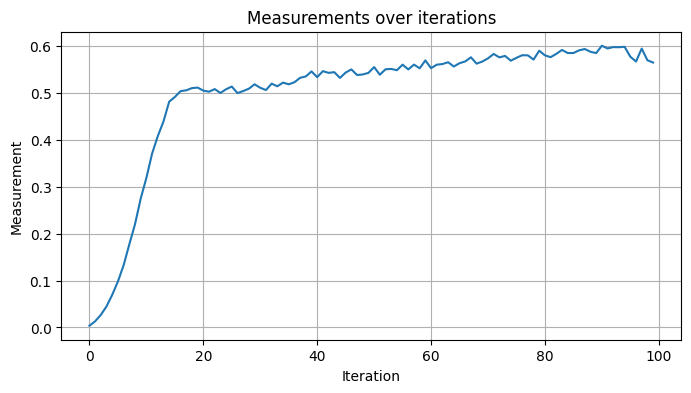

In [ ]:
loss_a01= data_collector.collection['A01']['loss_history']

import matplotlib.pyplot as plt

def plot_measurements(measures, title='Measurements over iterations'):
    """
    Simple plot for measurements evolving over time/iterations.

    Args:
        measures (list | tuple): sequence of measured values
        title (str): plot title
    """

    iterations = range(len(measures))

    plt.figure(figsize=(8, 4))
    plt.plot(iterations, measures)

    plt.xlabel('Iteration')
    plt.ylabel('Measurement')
    plt.title(title)

    plt.grid(True)

    plt.show()

plot_measurements(loss_a01[:100])

## Scacchiera per informazione minima

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parametri principali
# -----------------------
N = 1000           # dimensione array (NxN)
T = 200            # periodo spaziale (px) delle celle
A = 0.5            # ampiezza base (come nel tuo modello)
y_offset = 0.5     # offset per mappare in [0,1] via formula finale
gamma = 10.0       # "squareness": >5 inizia a sembrare una quadra, aumenta per bordi più netti

# -----------------------
# Smorzamento: K_smorz(x) = 100 * exp(-k*x)
# vincolo: K(900) ≈ 0.5  => k = ln(200)/900  (invariato)
# -----------------------
k_min = np.log(100.0) / 600.0

x = np.arange(N)
k_exp= np.log(100.0*x)/800.0*N

K_exp = np.clip(50.0 * np.exp(-k_min*x), k_min, 100)  # NON modificato
K_lin = 1.0 - 0.5*(x)/N
# Traduzione in CONTRASTO per restare in [-1,1] senza toccare K:
# m(x) = clip(A * K(x), 0, 1)
mx = np.clip(A * K_exp, 0.0, 1.0)
my = mx.copy()  # simmetria

# -----------------------
# Onde "quasi quadre" lungo X e Y (periodo T)
# -----------------------
phase_x = 2.0 * np.pi * x / T
sqx = np.tanh(gamma * np.sin(phase_x))   # [-1, 1]
sqy = sqx.copy()                         # simmetria

# Applica lo smorzamento come CONTRASTO (non cambia K)
Sx = mx * sqx            # in [-mx, mx]
Sy = my * sqy            # in [-my, my]

# -----------------------
# Combinazione a scacchiera (prodotto, non media!)
# V in [0,1]; se mx,my -> 0, V -> 0.5 (grigio)
# -----------------------
V = 0.5 * (1.0 - np.outer(Sy, Sx))  # Sy[:,None] * Sx[None,:]

# -----------------------
# Visualizzazione
# -----------------------
plt.figure(figsize=(6,6))
plt.imshow(V, cmap='gray', vmin=0.0, vmax=1.0)
plt.title('Scacchiera: sinusoide → quasi-quadra (γ), smorzamento invariato K(x)')
plt.axis('off')
plt.show()



# INSPECTING DRMINE'S NN 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

In [ ]:
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        # affine transform basis matrices

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def forward(self, s):
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel primo livello
            C += torch.sum(self.B*self.v1,0)
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10):
            A = torch.mm(A/i,C)
            H = H + A
        return H
Homography_net = HomographyNet()

In [ ]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        super(MINE, self).__init__()
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient
        

    def forward(self, x, ind):
        x = x.view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))]
            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [ ]:
import cv2
def images_registration(pyramid_fixed: tuple[np.ndarray],
                        pyramid_moving: tuple[np.ndarray],
                        L: int =6,
                        sampling: float = 0.1,
                        nChannel : int = 3,
                        ) -> tuple[list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor],list[torch.Tensor], list[int], list[int]]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  pyramid_fixed : tuple[numpy.ndarray]
    the pyramid of multiresolution from the fixed image
  pyramid_moving : tuple[numpy.ndarray]
    the pyramid of multiresolution from the moving image
  L : int
    the coarsest resolution level
  sampling : float
    the percentage of sampling to be used in homography optimization
  seed : int
    since the sampling is random the seed is useful for reproducibility

  Returns
  -------
  I_lst: list[torch.Tensor]
    the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  J_lst: list[torch.Tensor]
    the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  x_ : list[torch.Tensor]
   the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  y_ : list[torch.Tensor]
    the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  xy_ : list[torch.Tensor]
    the coordinates for the homography mapping
  ind_ : list[torch.Tensor]
    the random index for the homography optimization
  h_ : list[int]
    the heights of images in pyramid, necessary due downsampling
  w_ :  list[int]
    the widths of images in pyramid, necessary due downsampling
  '''
  if sampling > 1.0:
    raise ValueError("sampling must be between 0 and 1")


  I_lst,J_lst,h_lst,w_lst,xy_lst,ind_lst=[],[],[],[],[],[]
  pyramid_I = pyramid_fixed
  pyramid_J = pyramid_moving

  for s in range(L):
    I_ = torch.tensor(cv2.normalize(pyramid_I[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    J_ = torch.tensor(cv2.normalize(pyramid_J[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        I_lst.append(I_.permute(2,0,1)) # permute (H,W, C) -> (C, H, W)
        J_lst.append(J_.permute(2,0,1))
        h_, w_ = I_lst[s].shape[1], I_lst[s].shape[2]
        ind_ = torch.randperm(int(h_*w_*sampling)) # rand perm
        ind_lst.append(ind_)
    else:
        I_lst.append(I_)
        J_lst.append(J_)
        h_, w_ = I_lst[s].shape[0], I_lst[s].shape[1]
        ind_ = torch.randperm(int(h_*w_*sampling))
        ind_lst.append(ind_)
    h_lst.append(h_)
    w_lst.append(w_)

    y_, x_ = torch.meshgrid([torch.arange(0,h_).float().to(device), torch.arange(0,w_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(h_-1) - 1.0, 2.0*x_/(w_-1) - 1.0 # normalization -1.0 ->  1.0
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return (I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst)
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)


#### reproduce the net work for a single image resolution

In [ ]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5]
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [ ]:
xy5[:10,:10,:].numel() #NOTE get the number of elements in the tensor

In [ ]:

n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module): # unravel the functioning of the net
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            logs.info(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [ ]:
xy5 = xy5.to(device)

In [ ]:
if TEST_FOR['DRMINE']:
    homography_net = HomographyNet()

    Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
    x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
    ind =ind5
    mine_net = MINE_INSIDE(nChannel=3)
    mi = mine_net(x, ind)
    x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
    x_new.shape

In [ ]:
import torchinfo
if TEST_FOR['DRMINE']:
    minet = MINE(nChannel=3)
    s=3
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)
    Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
    x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
    ind =ind_lst[s]
    S_summary = torchinfo.summary(minet, input_data=(x, ind))
    S_summary


In [ ]:

# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].detach().cpu().numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


In [ ]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [ ]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    print(f'the {i}-th element has {len(ind_lst[i])} elements')

# DA FARE : RIFORMULA LE LOSS CONSIDERANDOLE COME DELLE NETWORK IN MODO CHE I PESI DELLE RETI VENGANO AGGIORNATI A OGNI ROUND

#### Da FARE : trovare il best lr per i parametri di mine_net e homography_net, 

In [ ]:
# considera la possibilità di usare il livello n-1 più preciso dove n è quello più nitido disponibile come base per la piramide
# in base al criterio di nyquist non possiamo considerare il livello n per la registrazione, per poi usarlo per calcolare l'errore,
# avrebbe più senso usare fino al precedente livello sfocato per i parametri della registrazione e infine usare quello più nitido possibile per calcolare l'errore

#### FATTO : creare un oggetto risultati in cui sono inclusi per ogni step un oggetto Collect_Results
1. la lista delle matrici omografiche PER OGNI LIVELLO
2. la lista delle loss PER OGNI LIVELLO ( in base al valore della loss per la valutazione? o la mi_loss)
3. il learning rate per ottenere tale oggetto ( da creare e salvare prima dello step dell'optimizer e dello scheduler)
4. l'alternativa al punto 2.

In [ ]:
import pandas as pd
def filter_keys(d,
                excluded_keys: list[str]
                ) -> dict:
    '''
    filter the dictionary to exclude the keys in excluded_keys
    Parameters
    ----------
    d : dict
        the dictionary to filter
    excluded_keys : list[str]
        the keys to exclude from the dictionary
    Returns
    -------
    dict
        the filtered dictionary, the original w/o the excluded keys
    '''
    if isinstance(d, dict):
        return {k: filter_keys(v,excluded_keys) for k, v in d.items() if k not in excluded_keys}
    return d

class  Collect_Results(): # ? or do a dataframe?
    def __init__(self, image_pair: str):
        self.name = image_pair
        self.images_results = {}
        self.images_results[f'{self.name}'] = {}

    def add_data(self, 
                iteration: int,
                loss: list[float] = [], 
                mi_loss: list[float] = [],
                homography_matrix: torch.Tensor | list[torch.Tensor] = None,
                lr: float = np.nan,
                ): 
        '''
        add data to the dictionary:
        Parameters
        ----------
        iteration : int
            the iteration of the training

        loss : list[float], optional
            the loss of the training, by default []

        mi_loss : list[float], optional
            the mutual information loss of the training, by default []

        homography_matrix : torch.Tensor | list[torch.Tensor], optional
            the homography matrix of the training, by default []

        lr : float, optional
            the learning rate of the training, by default np.NaN

        '''
        self.images_results[f'{self.name}'][f'iteration - {iteration}'] = {}
        if not loss:
            loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['loss'] = loss
        if not mi_loss:
            mi_loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['MI'] = mi_loss
        if homography_matrix == []:
            pass
        else:
            self.images_results[f'{self.name}'][f'iteration - {iteration}']['homography_matrix'] = homography_matrix
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['lr'] = lr

    def get_data(self, 
                type : str,
                datatype: str = ''
                )-> list | pd.DataFrame:
        '''
        get the data from dictionary in a certain format
        Parameters
        ----------
        type : str
            the type of data to get from the dictionary: 
                'list' to get a specified datatype in list format, #NOTE it works also for the homomatrices
                'df' to get the dollected results in a dataframe format
        
        datatype : str
            the datatype to get from the dictionary:
                'loss' to get the loss of the training
                'mi' to get the mutual information loss of the training
                'homography_matrix' to get the homography matrix of the training
                'lr' to get the learning rate of the training
        '''
        if not self.images_results[f'{self.name}'].keys(): # in case the dictionary is empty
            raise ValueError(f'No data available for {self.name}')
        avaiable_data = [x for x in self.images_results[f'{self.name}'][f'iteration - 0'].keys()]
        if type == 'list': # to retrieve a specific datatype
            if not datatype in avaiable_data: # if the requested datatype is not in the dictionary keys
                raise ValueError(f'Invalid datatype {datatype} for {self.name},\nselect from {avaiable_data}')
            else:
                data = [] 
                for iteration in self.images_results[f'{self.name}'].keys():
                    data.append(self.images_results[f'{self.name}'][iteration][datatype])
                return data
        elif type == 'df': # to retrieve all the data in a dataframe format
            df_wo_homomatrices = filter_keys(self.images_results[f'{self.name}'], excluded_keys=['homography_matrix'])
            return pd.DataFrame(data=df_wo_homomatrices).T
        
    
    #     restiruisci un df o una lista dei dati per ottenere una più facile visualizzazione
    

    

In [ ]:
import numpy as np

# Definire la dimensione dei tensori
tensor_shape = (2, 2)

# Creare una lista di tensori
tensor_list = []

for i in range(5):  # Creare 5 tensori
    tensor = np.random.rand(*tensor_shape)  # Tensore con valori casuali
    tensor_list.append(tensor)

tensor_list

In [ ]:
import pandas as pd
a01_res = Collect_Results('A01')
a_void = Collect_Results('A_void')
for i in range(5):
    a01_res.add_data(iteration=i, lr=0.001*(i+1), loss=[0.1*(i+1)], homography_matrix=torch.Tensor(tensor_list[i]))


In [ ]:

dataframe_a01 = a01_res.get_data(type='df')
dataframe_a01

In [ ]:
homo_list = a01_res.get_data(type='list', datatype='homography_matrix')
homo_list

In [ ]:
diz, diz_info, diz_iteration = {}, {}, {}
for i in range(3):
    diz_info[f'iteration{i}'] = {}
    diz_info[f'iteration{i}']['loss']= 1.34 + i
    diz_info[f'iteration{i}']['mi_loss'] = 0.23 + i
    diz_info[f'iteration{i}']['homography_matrix'] = torch.eye(i+1)
    diz_info[f'iteration{i}']['lr'] = 0.001 * (i + 1) 


diz['A01'] = diz_info
image_pair = 'A01'
iteration_of_interest = 1
data_to_retrieve ='lr'
diz[image_pair][f'iteration{iteration_of_interest}'][data_to_retrieve]

successivamente:
1. provare a calcolare la mi con altri metodi di approssimazione numerica o probabilistici
2. calcolare l'approssimazione con il runge-kutta e considerare le immagini come flussi dinamici


#### DA FARE: plottare i risultati o riprendere il modo per analizzare la rete ottenuta durante l'allenamento

In [ ]:
def plot_graph(values: list[float],
              title: str = 'Loss',
              xlabel: str = 'Iteration',
              ylabel: str = 'Loss',
              save_path: Path = None ,
              show: bool = True,
              ) -> None:
    '''
    plot the loss values over the epochs
    Parameters
    ----------
    loss_values : list[float]
        the list of loss values to be plotted
    title : str
        the title of the plot
    xlabel : str
        the label of x axis
    ylabel : str
        the label of y axis
    save_path : Path
        the path to save the plot
    show : bool
        whether to show the plot or not

    Returns
    -------
    None
    '''
    values = [x*x for x in values]
    plt.plot(values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if save_path:
        save_path = save_path / f'{title}.png'
        plt.savefig(save_path)
    if show:
        plt.show()
    
    return None

In [ ]:
random_loss_values = [round(x, 2) for x in np.random.rand(100)]
plot_graph(random_loss_values, title=' Lossquad', xlabel='Iteration', ylabel='Loss', show=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation(tensor_list, animation_name='animation.gif'):
    # Ensure tensor_list is not empty
    if not tensor_list:
        raise ValueError("The tensor list is empty.")
    
    # Get the dimensions of the tensors
    _, N, M = tensor_list[0].shape
    
    # Create a figure and axis for the animation
    fig, ax = plt.subplots()
    
    # Initialize the image with the first tensor
    im = ax.imshow(tensor_list[0].transpose(1, 2, 0), animated=True)
    
    # Update function for the animation
    def update(frame):
        im.set_array(frame.transpose(1, 2, 0))
        return im,
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=tensor_list, blit=True)
    
    # Save the animation as a GIF file
    save_path = this_file_path.parent / 'Results' / animation_name
    ani.save(save_path, writer='pillow')
    
    plt.close(fig)
    print(f"Animation saved as {animation_name}")

# Example usage:
# Create a list of random tensors with dimensions [3, 100, 100]
tensor_list = [np.random.rand(3, 100, 100) for _ in range(10)]

# Create and save the animation
create_animation(tensor_list)


In [ ]:
a = torch.Tensor(np.arange(0, 10 , 1))
b = torch.Tensor(np.arange(10, 20 , 1))
c = torch.stack([a, b], 1)
d = torch.cat([a, b], 0)
c.shape, c, d.shape, d

In [ ]:
a, b , c = 0 , 2 , 1
a != b != c

In [ ]:
# Create a train model funciton for a specified image couple
def train_model (model : MINE,
                homography_net : HomographyNet,
                optimizer : optim.Optimizer,
                fixed_pyramid : tuple[np.ndarray],
                moving_pyramid : tuple[np.ndarray],
                loss :nn.Module,
                n_epochs : int = 1,
                n_iterations : int = 50,
                device : str = None , # or 'cuda' or 'cpu'
                 ) -> None :
    '''
    the way to train a model through the parameter optimization of the homography net

    Parameters:
    -----------
        model (MINE): the net to calculate the mutual information parameter for optimize the model

        homography_net (HomographyNet): the net to calculate the homography matrix for the image couple
        
        optimizer (optim.Optimizer): the algorithm step to optimize the parameters of the homography net
        
        fixed_pyramid (tuple[np.ndarray]): the pyramid of the fixed image
        
        moving_pyramid (tuple[np.ndarray]): the pyramid of the moving image
        
        loss (nn.Module): the loss function to calculate the loss between the two images
        
        n_epochs (int): the number of epochs to train the model
        
        n_iterations (int): the number of iterations to train the model
        
        device (str): the device to use for the training

    '''
    pass

In [ ]:
# per il training usa due diverse loss, la prima fa tutto all'interno del modello... l'altra fa in modo di avere un modello che trasforma l'immagine e successivamente calcola la loss tramite la mine net

#### PROVA LR_SCHEDULER con ionosphere data.csv


In [ ]:
import pandas as pd



In [ ]:
dati = Path.cwd() / 'ionosphere.data'
dati.exists()

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda function for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: SGD lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

In [ ]:
lr_list

In [ ]:

iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig(RESULT_PATH/ 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [ ]:
optimizer.param_groups[0].keys()


In [ ]:
optimizer.param_groups[0]['lambda_lr'] # vedi func lr_lambda

In [ ]:
plt.plot(epochs_iteration, lr_list, label='lr_0 = 1', c='red')
plt.plot(epochs_iteration, lambda_lr, label='lr=0.1', c='blue')
plt.legend()

In [ ]:
lambda_lr 

### impostando l'ottimizzatore del modello come Adam:

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda funcrion for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        before_lr = optimizer.param_groups[0]["lr"]    
        optimizer.step()
        after_lr = optimizer.param_groups[0]["lr"]
        
        print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr)
        )
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    #scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

In [ ]:
type(model)

In [ ]:
iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig( RESULT_PATH/ 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [ ]:
optimizer.param_groups[0].keys()

 vedi FOREACH implementation nell'ottimizzazione

In [ ]:
for i in batch_start:
    #print(i)
    if i%240 == 0:
        print('done')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Definizione del modello
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Creazione del modello
model = SimpleNN()

# Definizione dell'ottimizzatore Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dati di esempio
input = torch.randn(100, 10)
target = torch.randn(100, 1)

# Funzione di perdita
loss_fn = nn.MSELoss()
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)

# Ciclo di addestramento
for epoch in range(10):
    # Azzeramento dei gradienti
    optimizer.zero_grad()
    
    # Calcolo della perdita
    output = model(input)
    loss = loss_fn(output, target)
    
    # Backpropagation
    loss.backward()
    
    # Aggiornamento dei parametri
    optimizer.step()
    
    # Stampa del learning rate effettivo per ogni parametro
    print(f"Epoch {epoch+1}")
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"  Param Group {i+1}:")
        for param in param_group['params']:
            state = optimizer.state[param]
            if 'step' in state and state['step'] > 0:
                bias_correction1 = 1 - optimizer.defaults['betas'][0] ** state['step']
                bias_correction2 = 1 - optimizer.defaults['betas'][1] ** state['step']
                adapted_lr = optimizer.defaults['lr'] * (bias_correction2 ** 0.5) / bias_correction1
                print(f"    Adapted LR: {adapted_lr}")
    print(f'epoca:{epoch+1}, loss: {loss.item()}, general lr : {optimizer.param_groups[0]['lr']}' )
    
    scheduler.step()